In [55]:
# 1. Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb
import shap


## **Importing and Merging Data**

In [56]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
#loading application train data for owner personal info
application= pd.read_csv('/content/drive/MyDrive/application_train.csv')

In [58]:
 #Load Bureau (Main Historical Data)
bureau= pd.read_csv('/content/drive/MyDrive/bureau.csv')

In [59]:
 #Load Bureau balance ( repayment history Data )
balance= pd.read_csv('/content/drive/MyDrive/bureau_balance.csv')

In [60]:
# 1. Aggregate bureau.csv
# -------------------------------
# Group by applicant ID (SK_ID_CURR)
bureau_agg = bureau.groupby("SK_ID_CURR").agg({
    "AMT_CREDIT_SUM": ["mean", "sum"],          # average and total credit amount
    "AMT_CREDIT_SUM_DEBT": ["mean", "sum"],     # average and total debt
    "AMT_CREDIT_SUM_OVERDUE": ["mean", "max"],  # overdue statistics
    "DAYS_CREDIT": ["mean", "min"],             # average and earliest loan age
    "CREDIT_ACTIVE": lambda x: (x == "Active").sum(),  # count active loans
    "CREDIT_TYPE": "nunique"                    # number of different credit types
})

# Flatten column names
bureau_agg.columns = ["_".join(col).strip() for col in bureau_agg.columns]

bureau_agg.head(10)

,AMT_CREDIT_SUM_mean,AMT_CREDIT_SUM_sum,AMT_CREDIT_SUM_DEBT_mean,AMT_CREDIT_SUM_DEBT_sum,AMT_CREDIT_SUM_OVERDUE_mean,AMT_CREDIT_SUM_OVERDUE_max,DAYS_CREDIT_mean,DAYS_CREDIT_min,CREDIT_ACTIVE_<lambda>,CREDIT_TYPE_nunique
SK_ID_CURR,,,,,,,,,,
100001,207623.571429,1453365.000,85240.928571,596686.5,0.0,0.0,-735.000000,-1572,3,1
100002,108131.945625,865055.565,49156.200000,245781.0,0.0,0.0,-874.000000,-1437,2,2
100003,254350.125000,1017400.500,0.000000,0.0,0.0,0.0,-1400.750000,-2586,1,2
100004,94518.900000,189037.800,0.000000,0.0,0.0,0.0,-867.000000,-1326,0,1
100005,219042.000000,657126.000,189469.500000,568408.5,0.0,0.0,-190.666667,-373,2,2
100007,146250.000000,146250.000,0.000000,0.0,0.0,0.0,-1149.000000,-1149,0,1
100008,156148.500000,468445.500,80019.000000,240057.0,0.0,0.0,-757.333333,-1097,1,1
100009,266711.750000,4800811.500,76953.535714,1077349.5,0.0,0.0,-1271.500000,-2882,4,2
100010,495000.000000,990000.000,174003.750000,348007.5,0.0,0.0,-1939.500000,-2741,1,2


In [61]:
# 2. Aggregate balance (bureau_balance.csv)
# -------------------------------

# Map STATUS to numeric categories for easier aggregation
status_map = {"0":0, "1":1, "2":2, "3":3, "4":4, "5":5, "C":-1, "X":-2}
balance["STATUS_NUM"] = balance["STATUS"].map(status_map)

# Aggregate repayment history per loan
bb_agg = balance.groupby("SK_ID_BUREAU").agg({
    "MONTHS_BALANCE": ["count", "min"],         # number of months reported, earliest month
    "STATUS_NUM": ["mean", "max"]               # average status, worst status
})
bb_agg.columns = ["_".join(col).strip() for col in bb_agg.columns]

# Merge back to bureau level
bureau_bb = bureau.merge(bb_agg, on="SK_ID_BUREAU", how="left")


bb_agg.head(10)


,MONTHS_BALANCE_count,MONTHS_BALANCE_min,STATUS_NUM_mean,STATUS_NUM_max
SK_ID_BUREAU,,,,
5001709,97,-96,-1.113402,-1
5001710,83,-82,-1.301205,0
5001711,4,-3,-0.500000,0
5001712,19,-18,-0.473684,0
5001713,22,-21,-2.000000,-2
5001714,15,-14,-2.000000,-2
5001715,60,-59,-2.000000,-2
5001716,86,-85,-0.918605,0
5001717,22,-21,-0.227273,0


In [62]:
bureau_bb.head(10)

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,...,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY,MONTHS_BALANCE_count,MONTHS_BALANCE_min,STATUS_NUM_mean,STATUS_NUM_max
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,...,0.00,NaN,0.0,Consumer credit,-131,NaN,NaN,NaN,NaN,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,...,171342.00,NaN,0.0,Credit card,-20,NaN,NaN,NaN,NaN,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,...,NaN,NaN,0.0,Consumer credit,-16,NaN,NaN,NaN,NaN,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,...,NaN,NaN,0.0,Credit card,-16,NaN,NaN,NaN,NaN,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,...,NaN,NaN,0.0,Consumer credit,-21,NaN,NaN,NaN,NaN,NaN
5,215354,5714467,Active,currency 1,-273,0,27460.0,NaN,0.0,0,...,71017.38,108982.62,0.0,Credit card,-31,NaN,NaN,NaN,NaN,NaN
6,215354,5714468,Active,currency 1,-43,0,79.0,NaN,0.0,0,...,42103.80,0.00,0.0,Consumer credit,-22,NaN,NaN,NaN,NaN,NaN
7,162297,5714469,Closed,currency 1,-1896,0,-1684.0,-1710.0,14985.0,0,...,0.00,0.00,0.0,Consumer credit,-1710,NaN,NaN,NaN,NaN,NaN
8,162297,5714470,Closed,currency 1,-1146,0,-811.0,-840.0,0.0,0,...,0.00,0.00,0.0,Consumer credit,-840,NaN,NaN,NaN,NaN,NaN
9,162297,5714471,Active,currency 1,-1146,0,-484.0,NaN,0.0,0,...,0.00,0.00,0.0,Credit card,-690,NaN,NaN,NaN,NaN,NaN


In [63]:

# 4. Aggregate bureau_bb to applicant level
bureau_balance_agg = bureau_bb.groupby("SK_ID_CURR").agg({
    "STATUS_NUM_mean": "mean",
    "STATUS_NUM_max": "max",
    "MONTHS_BALANCE_count": "mean"
})

bureau_balance_agg.head(10)

,STATUS_NUM_mean,STATUS_NUM_max,MONTHS_BALANCE_count
SK_ID_CURR,,,
100001,-0.862901,1.0,24.571429
100002,-0.243608,1.0,13.750000
100003,NaN,NaN,NaN
100004,NaN,NaN,NaN
100005,-0.401709,0.0,7.000000
100007,NaN,NaN,NaN
100008,NaN,NaN,NaN
100009,NaN,NaN,NaN
100010,-0.722222,0.0,36.000000


In [64]:
# 5. Merge applicant with applicant-level aggregates only
applicant_full = application.merge(bureau_agg, on="SK_ID_CURR", how="left")


In [65]:
applicant_full = applicant_full.merge(bureau_balance_agg, on="SK_ID_CURR", how="left")

In [66]:
applicant_full.head(10)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_CREDIT_SUM_DEBT_sum,AMT_CREDIT_SUM_OVERDUE_mean,AMT_CREDIT_SUM_OVERDUE_max,DAYS_CREDIT_mean,DAYS_CREDIT_min,CREDIT_ACTIVE_<lambda>,CREDIT_TYPE_nunique,STATUS_NUM_mean,STATUS_NUM_max,MONTHS_BALANCE_count
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,245781.0,0.0,0.0,-874.000000,-1437.0,2.0,2.0,-0.243608,1.0,13.75
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,-1400.750000,-2586.0,1.0,2.0,NaN,NaN,NaN
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,-867.000000,-1326.0,0.0,1.0,NaN,NaN,NaN
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,-1149.000000,-1149.0,0.0,1.0,NaN,NaN,NaN
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,240057.0,0.0,0.0,-757.333333,-1097.0,1.0,1.0,NaN,NaN,NaN
6,100009,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,...,1077349.5,0.0,0.0,-1271.500000,-2882.0,4.0,2.0,NaN,NaN,NaN
7,100010,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,348007.5,0.0,0.0,-1939.500000,-2741.0,1.0,2.0,-0.722222,0.0,36.00
8,100011,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,...,0.0,0.0,0.0,-1773.000000,-2508.0,0.0,2.0,NaN,NaN,NaN
9,100012,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [67]:
for i, col in enumerate(applicant_full.columns):
    print(i, col)

0 SK_ID_CURR
1 TARGET
2 NAME_CONTRACT_TYPE
3 CODE_GENDER
4 FLAG_OWN_CAR
5 FLAG_OWN_REALTY
6 CNT_CHILDREN
7 AMT_INCOME_TOTAL
8 AMT_CREDIT
9 AMT_ANNUITY
10 AMT_GOODS_PRICE
11 NAME_TYPE_SUITE
12 NAME_INCOME_TYPE
13 NAME_EDUCATION_TYPE
14 NAME_FAMILY_STATUS
15 NAME_HOUSING_TYPE
16 REGION_POPULATION_RELATIVE
17 DAYS_BIRTH
18 DAYS_EMPLOYED
19 DAYS_REGISTRATION
20 DAYS_ID_PUBLISH
21 OWN_CAR_AGE
22 FLAG_MOBIL
23 FLAG_EMP_PHONE
24 FLAG_WORK_PHONE
25 FLAG_CONT_MOBILE
26 FLAG_PHONE
27 FLAG_EMAIL
28 OCCUPATION_TYPE
29 CNT_FAM_MEMBERS
30 REGION_RATING_CLIENT
31 REGION_RATING_CLIENT_W_CITY
32 WEEKDAY_APPR_PROCESS_START
33 HOUR_APPR_PROCESS_START
34 REG_REGION_NOT_LIVE_REGION
35 REG_REGION_NOT_WORK_REGION
36 LIVE_REGION_NOT_WORK_REGION
37 REG_CITY_NOT_LIVE_CITY
38 REG_CITY_NOT_WORK_CITY
39 LIVE_CITY_NOT_WORK_CITY
40 ORGANIZATION_TYPE
41 EXT_SOURCE_1
42 EXT_SOURCE_2
43 EXT_SOURCE_3
44 APARTMENTS_AVG
45 BASEMENTAREA_AVG
46 YEARS_BEGINEXPLUATATION_AVG
47 YEARS_BUILD_AVG
48 COMMONAREA_AVG
49 ELEVATORS_AV

In [68]:
# Columns in raw application_train
app_cols = set(application.columns)

# Columns in applicant_full that came from application
full_cols = set(applicant_full.columns)

# Find missing ones
missing = app_cols - full_cols
print("Missing columns:", missing)

Missing columns: set()


# **Data Inspection**

In [69]:
# to know data size
print('Number of rows and columns in the data set:', applicant_full.shape)

Number of rows and columns in the data set: (307511, 135)


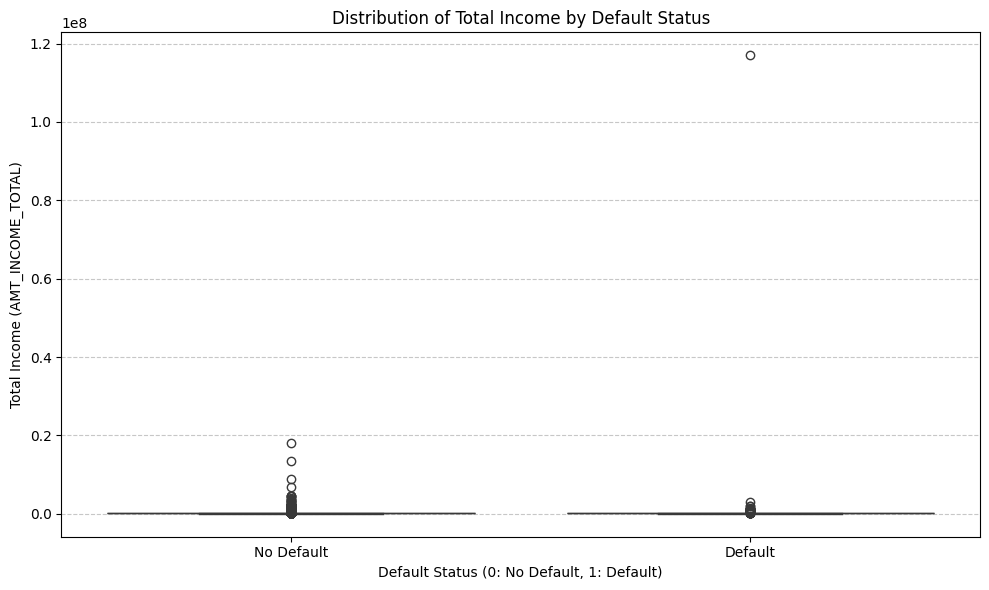

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=applicant_full, hue='TARGET', palette='viridis', legend=False)
plt.title('Distribution of Total Income by Default Status')
plt.xlabel('Default Status (0: No Default, 1: Default)')
plt.ylabel('Total Income (AMT_INCOME_TOTAL)')
plt.xticks([0, 1], ['No Default', 'Default'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

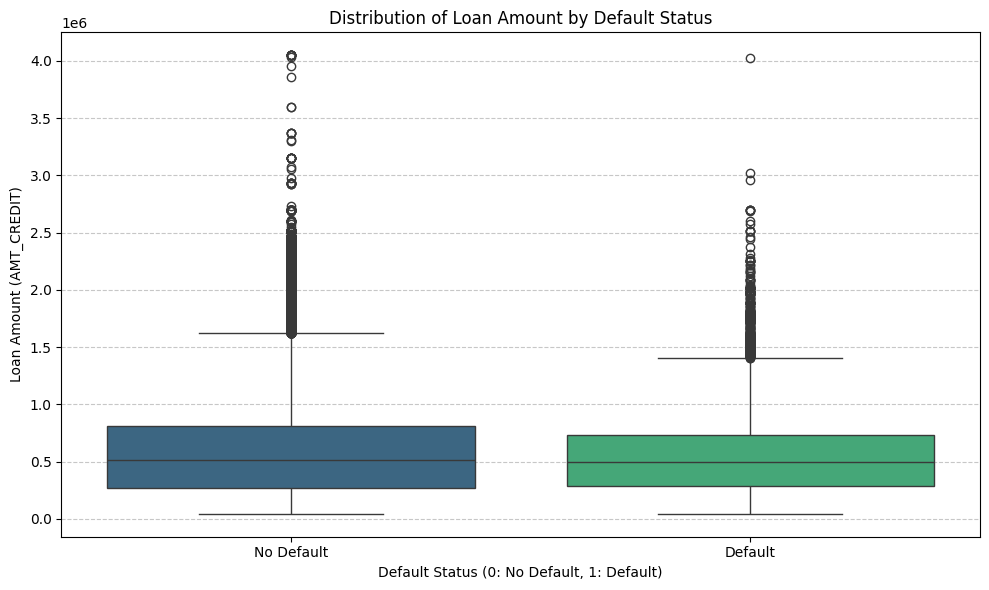

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='TARGET', y='AMT_CREDIT', data=applicant_full, hue='TARGET', palette='viridis', legend=False)
plt.title('Distribution of Loan Amount by Default Status')
plt.xlabel('Default Status (0: No Default, 1: Default)')
plt.ylabel('Loan Amount (AMT_CREDIT)')
plt.xticks([0, 1], ['No Default', 'Default'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

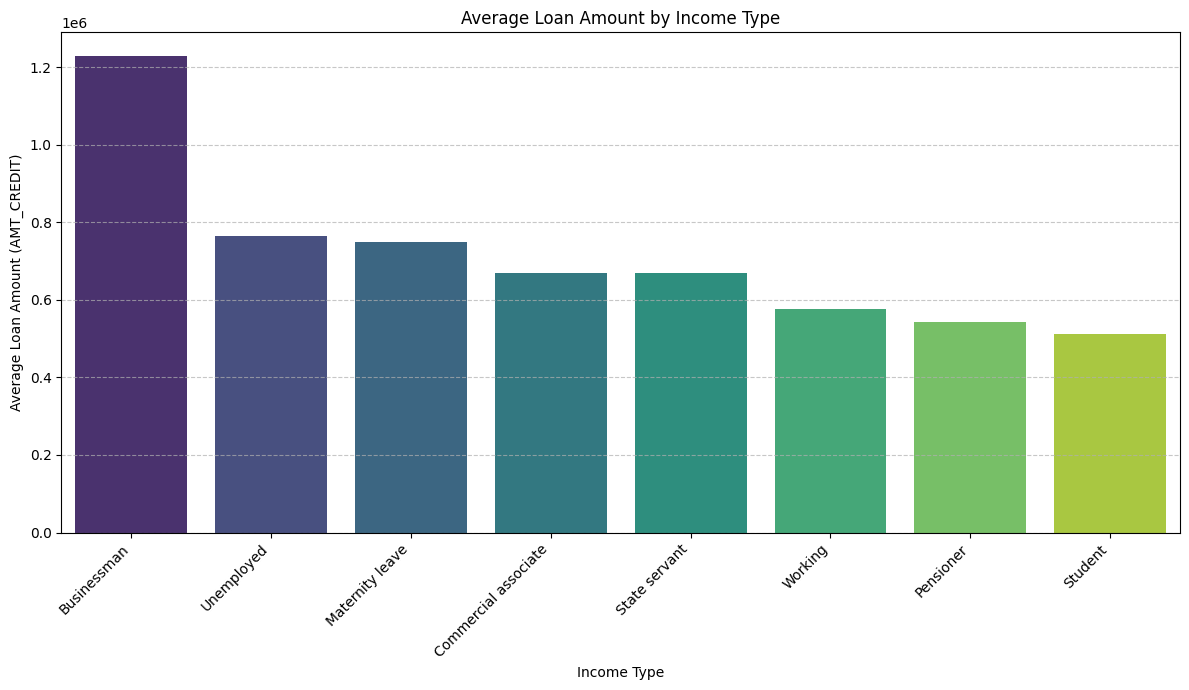

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average loan amount by income type
avg_loan_by_income = applicant_full.groupby('NAME_INCOME_TYPE')['AMT_CREDIT'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='NAME_INCOME_TYPE', y='AMT_CREDIT', data=avg_loan_by_income, hue='NAME_INCOME_TYPE', palette='viridis', legend=False)
plt.title('Average Loan Amount by Income Type')
plt.xlabel('Income Type')
plt.ylabel('Average Loan Amount (AMT_CREDIT)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

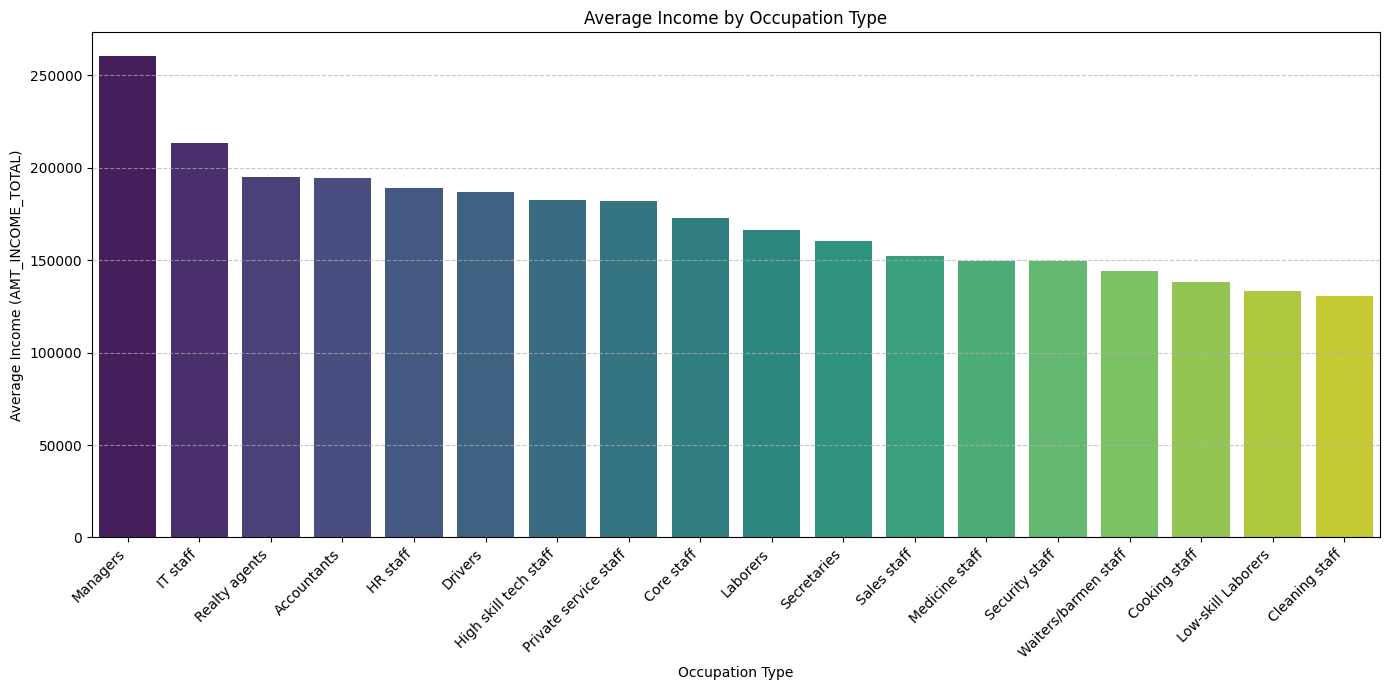

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average income by occupation type
avg_income_by_occupation = applicant_full.groupby('OCCUPATION_TYPE')['AMT_INCOME_TOTAL'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(x='OCCUPATION_TYPE', y='AMT_INCOME_TOTAL', data=avg_income_by_occupation, hue='OCCUPATION_TYPE', palette='viridis', legend=False)
plt.title('Average Income by Occupation Type')
plt.xlabel('Occupation Type')
plt.ylabel('Average Income (AMT_INCOME_TOTAL)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [74]:
# to know the the columns with null values and the data type for each column

# Build table of null counts + dtypes
nulls_and_dtypes = applicant_full.isnull().sum().to_frame("null_count")
nulls_and_dtypes["dtype"] = applicant_full.dtypes

# Force pandas to display all rows and columns
import pandas as pd
pd.set_option("display.max_rows", None)   # show all rows
pd.set_option("display.max_columns", None) # show all columns
pd.set_option("display.width", None)      # don't wrap lines
pd.set_option("display.max_colwidth", None)

print(nulls_and_dtypes.sort_values("null_count", ascending=False))

                              null_count    dtype
STATUS_NUM_max                    215280  float64
STATUS_NUM_mean                   215280  float64
MONTHS_BALANCE_count              215280  float64
COMMONAREA_MODE                   214865  float64
COMMONAREA_MEDI                   214865  float64
COMMONAREA_AVG                    214865  float64
NONLIVINGAPARTMENTS_MODE          213514  float64
NONLIVINGAPARTMENTS_MEDI          213514  float64
NONLIVINGAPARTMENTS_AVG           213514  float64
FONDKAPREMONT_MODE                210295   object
LIVINGAPARTMENTS_AVG              210199  float64
LIVINGAPARTMENTS_MODE             210199  float64
LIVINGAPARTMENTS_MEDI             210199  float64
FLOORSMIN_MODE                    208642  float64
FLOORSMIN_MEDI                    208642  float64
FLOORSMIN_AVG                     208642  float64
YEARS_BUILD_AVG                   204488  float64
YEARS_BUILD_MEDI                  204488  float64
YEARS_BUILD_MODE                  204488  float64


/tmp/ipykernel_1251/3222450596.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_percentages.index, y=missing_percentages.values, palette='viridis')


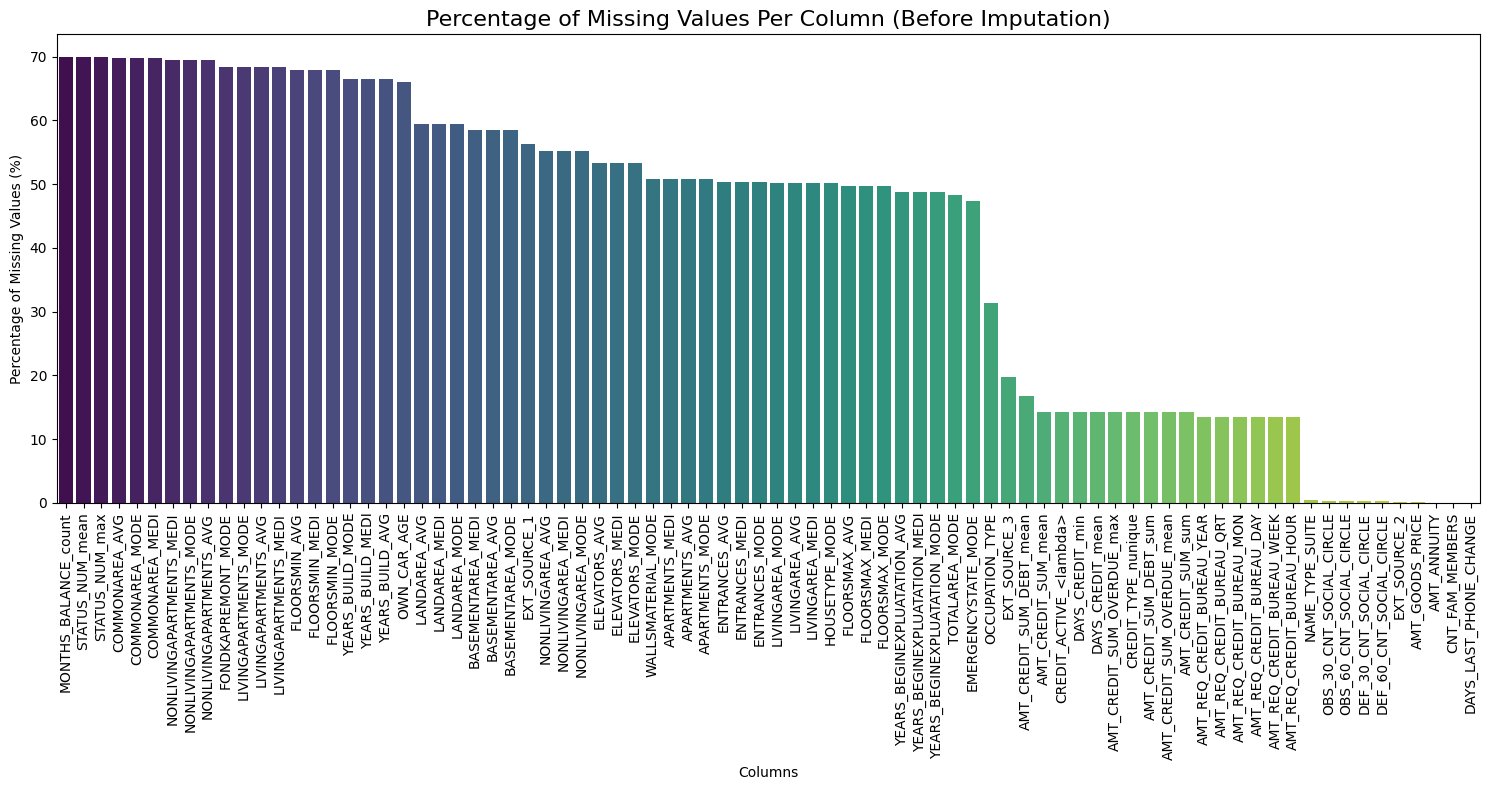

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the percentage of missing values for each column
missing_percentages = applicant_full.isnull().sum() / len(applicant_full) * 100

# Filter out columns with no missing values and sort in descending order
missing_percentages = missing_percentages[missing_percentages > 0].sort_values(ascending=False)

if not missing_percentages.empty:
    plt.figure(figsize=(15, 8))
    sns.barplot(x=missing_percentages.index, y=missing_percentages.values, palette='viridis')
    plt.title('Percentage of Missing Values Per Column (Before Imputation)', fontsize=16)
    plt.xlabel('Columns')
    plt.ylabel('Percentage of Missing Values (%)')
    plt.xticks(rotation=90, ha='center') # Rotate labels for better readability
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the DataFrame.")

In [76]:
# to know mean  for imputation if needed
applicant_full.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AMT_CREDIT_SUM_mean,AMT_CREDIT_SUM_sum,AMT_CREDIT_SUM_DEBT_mean,AMT_CREDIT_SUM_DEBT_sum,AMT_CREDIT_SUM_OVERDUE_mean,AMT_CREDIT_SUM_OVERDUE_max,DAYS_CREDIT_mean,DAYS_CREDIT_min,CREDIT_ACTIVE_<lambda>,CREDIT_TYPE_nunique,STATUS_NUM_mean,STATUS_NUM_max,MONTHS_BALANCE_count
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,104582.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,134133.000000,3.068510e+05,246546.000000,151450.00000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,159080.000000,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.00000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,2.634900e+05,2.634910e+05,2.561310e+05,2.634910e+05,2.634910e+05,2.634910e+05,263491.000000,263491.000000,263491.000000,263491.000000,92231.000000,92231.000000,92231.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,12.061091,0.999

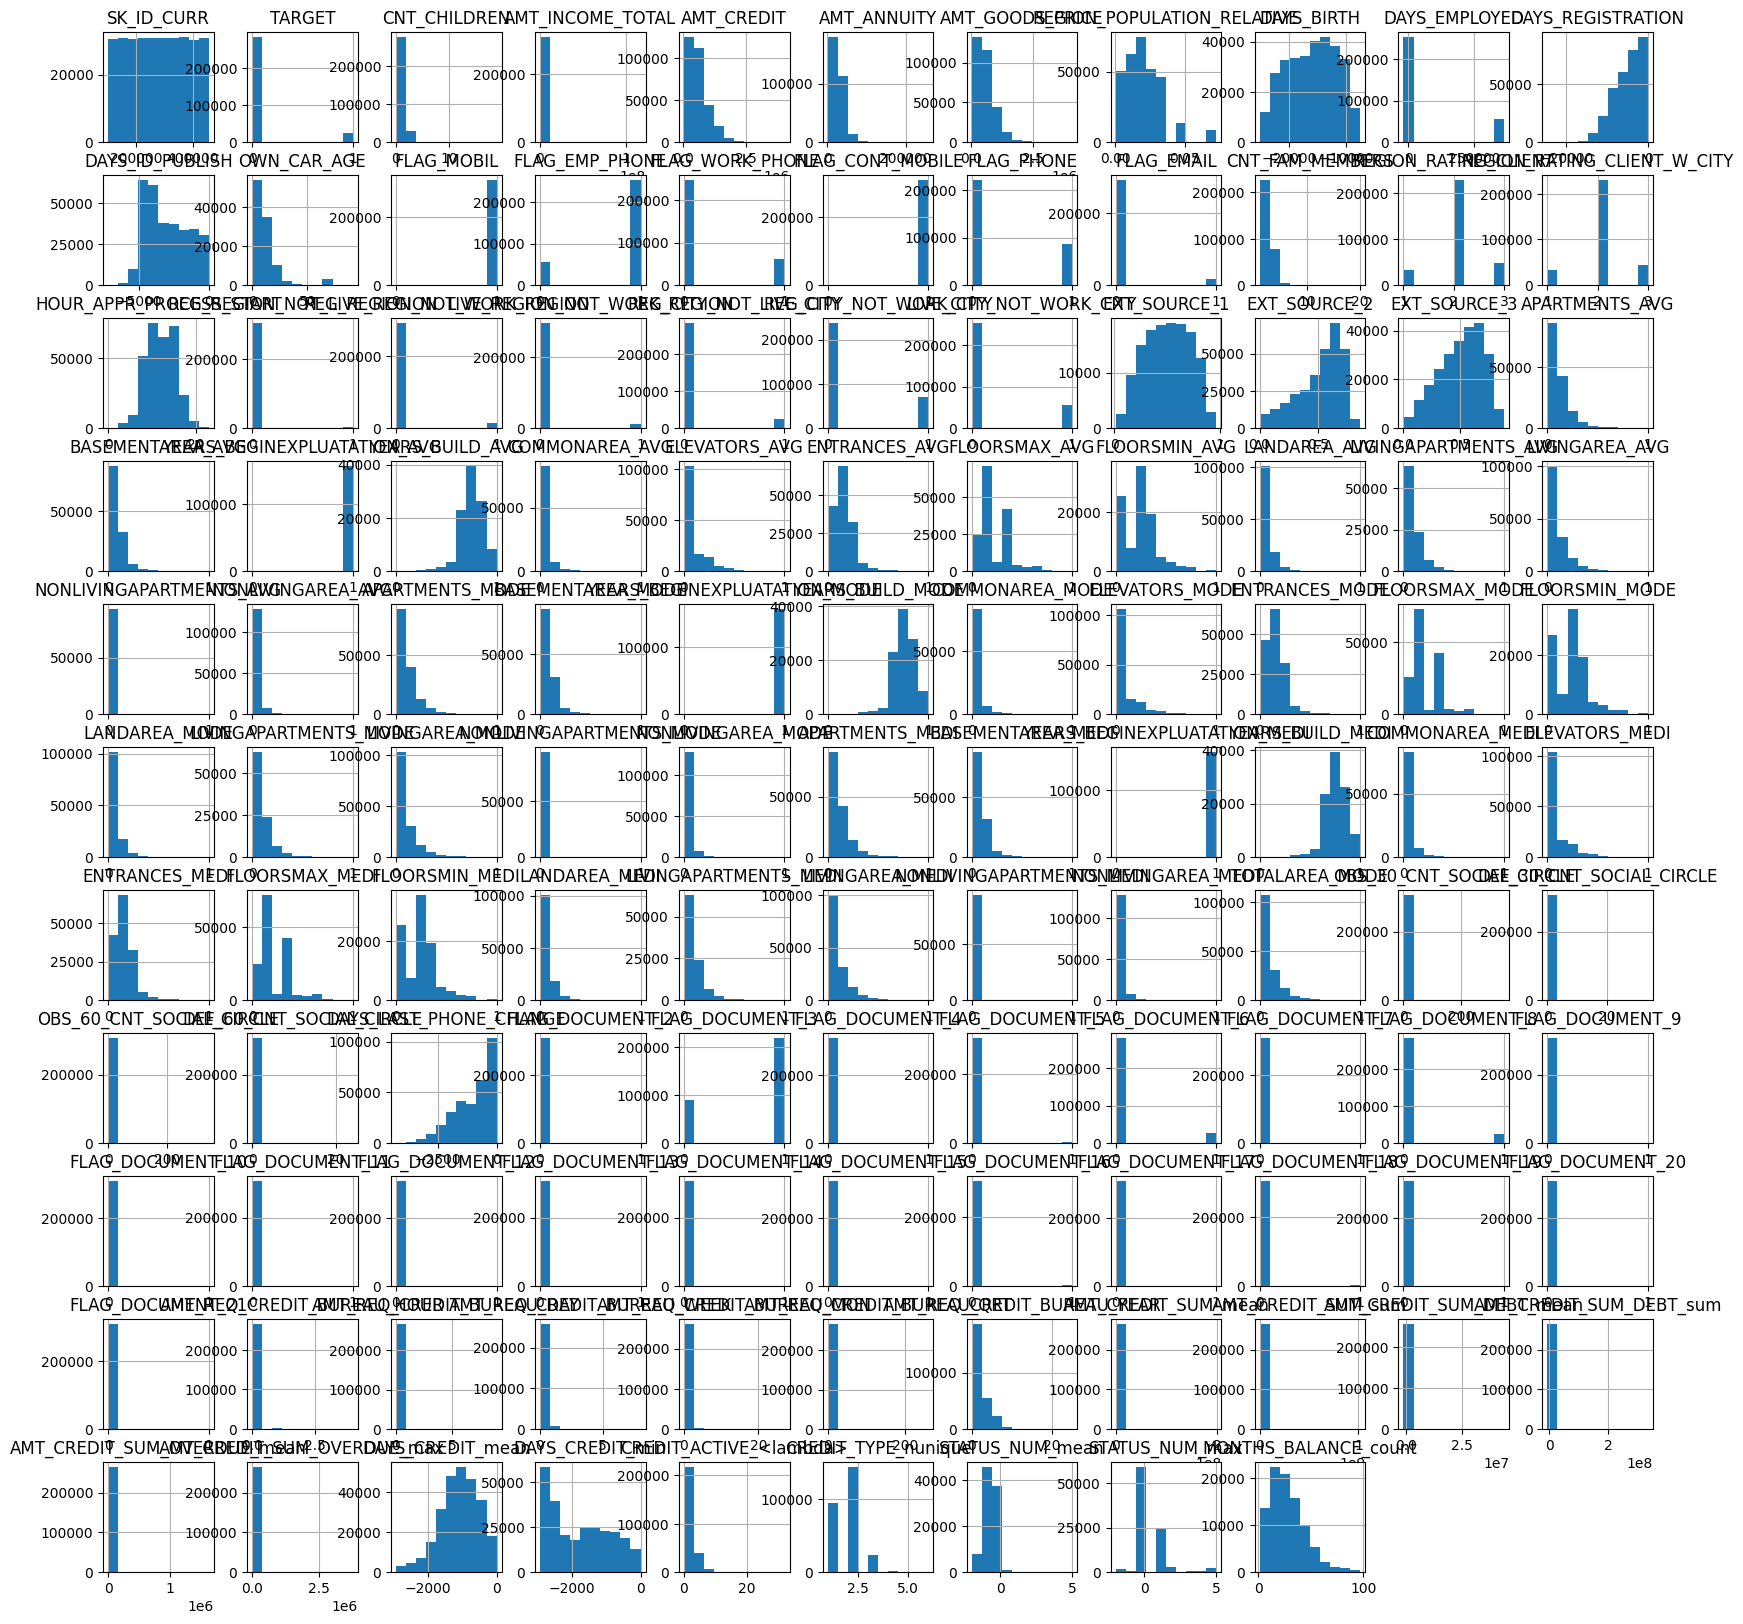

In [77]:
applicant_full.hist(figsize=(20, 20))
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


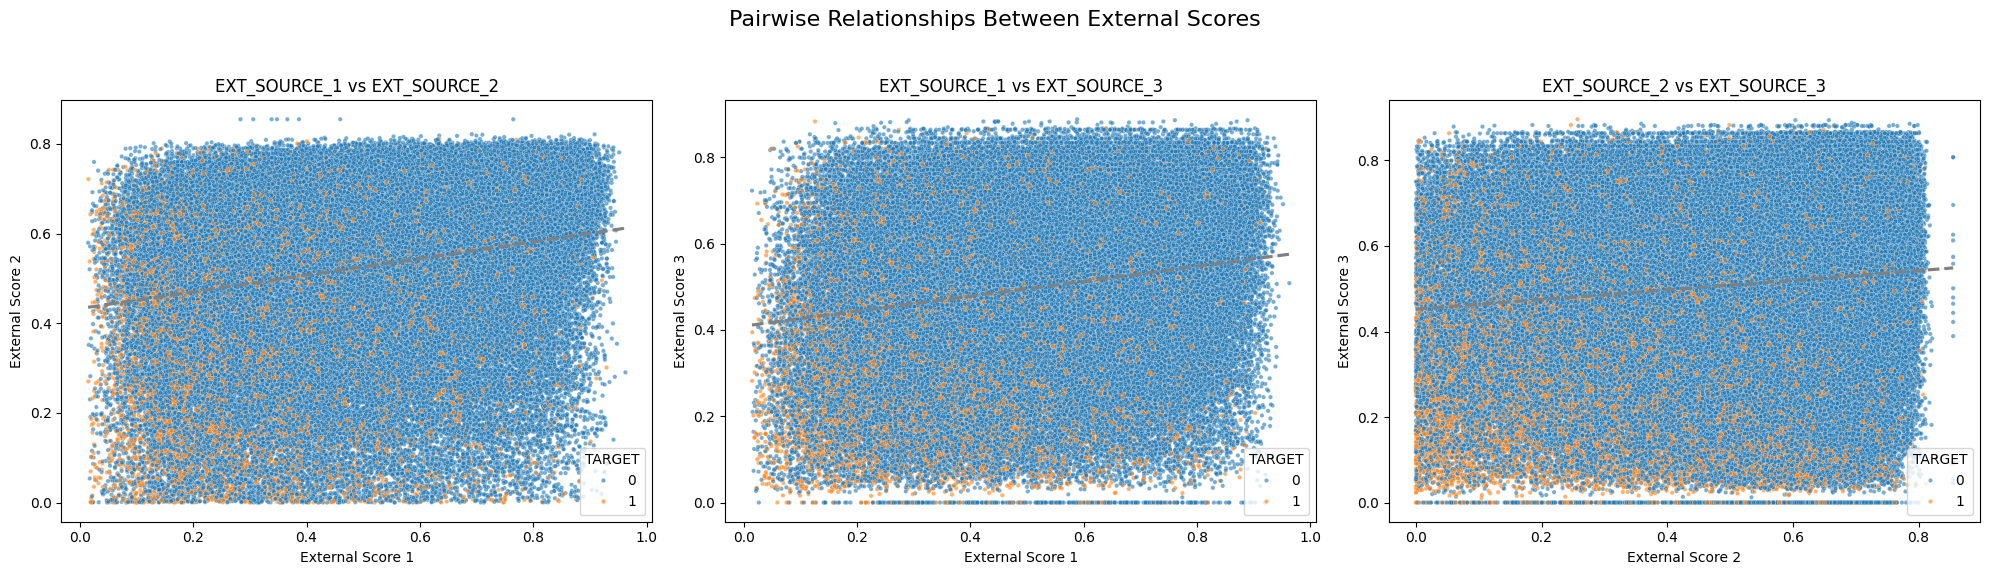

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and axes for subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Pairwise Relationships Between External Scores', fontsize=16)

# Plot 1: EXT_SOURCE_1 vs EXT_SOURCE_2
sns.scatterplot(x='EXT_SOURCE_1', y='EXT_SOURCE_2', hue='TARGET', data=applicant_full, ax=axes[0], alpha=0.6, s=10)
sns.regplot(x='EXT_SOURCE_1', y='EXT_SOURCE_2', data=applicant_full, ax=axes[0], scatter=False, color='gray', line_kws={'linestyle':'--'})
axes[0].set_title('EXT_SOURCE_1 vs EXT_SOURCE_2')
axes[0].set_xlabel('External Score 1')
axes[0].set_ylabel('External Score 2')

# Plot 2: EXT_SOURCE_1 vs EXT_SOURCE_3
sns.scatterplot(x='EXT_SOURCE_1', y='EXT_SOURCE_3', hue='TARGET', data=applicant_full, ax=axes[1], alpha=0.6, s=10)
sns.regplot(x='EXT_SOURCE_1', y='EXT_SOURCE_3', data=applicant_full, ax=axes[1], scatter=False, color='gray', line_kws={'linestyle':'--'})
axes[1].set_title('EXT_SOURCE_1 vs EXT_SOURCE_3')
axes[1].set_xlabel('External Score 1')
axes[1].set_ylabel('External Score 3')

# Plot 3: EXT_SOURCE_2 vs EXT_SOURCE_3
sns.scatterplot(x='EXT_SOURCE_2', y='EXT_SOURCE_3', hue='TARGET', data=applicant_full, ax=axes[2], alpha=0.6, s=10)
sns.regplot(x='EXT_SOURCE_2', y='EXT_SOURCE_3', data=applicant_full, ax=axes[2], scatter=False, color='gray', line_kws={'linestyle':'--'})
axes[2].set_title('EXT_SOURCE_2 vs EXT_SOURCE_3')
axes[2].set_xlabel('External Score 2')
axes[2].set_ylabel('External Score 3')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

### 4. Loan Amount vs. Total Income

This scatter plot examines the relationship between the total loan amount requested (`AMT_CREDIT`) and the applicant's total income (`AMT_INCOME_TOTAL`). A positive correlation would suggest that higher-income individuals tend to apply for larger loans, which is a common pattern in lending. The regression line helps visualize this trend, while coloring by `TARGET` can reveal if there's a difference in this relationship for defaulters versus non-defaulters.

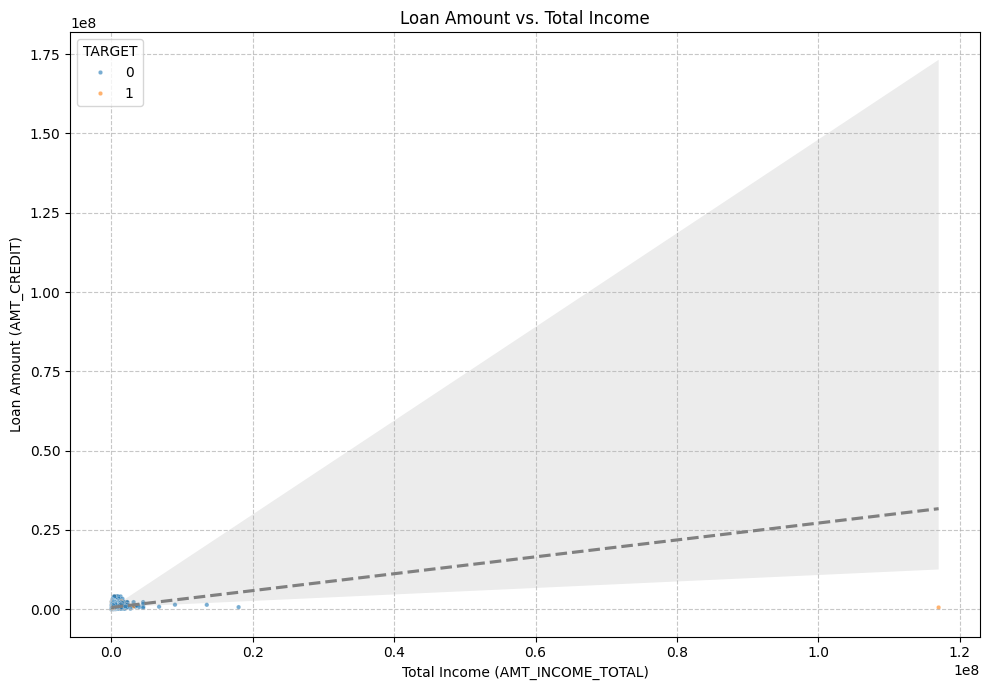

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x='AMT_INCOME_TOTAL', y='AMT_CREDIT', hue='TARGET', data=applicant_full, alpha=0.6, s=10)
sns.regplot(x='AMT_INCOME_TOTAL', y='AMT_CREDIT', data=applicant_full, scatter=False, color='gray', line_kws={'linestyle':'--'})
plt.title('Loan Amount vs. Total Income')
plt.xlabel('Total Income (AMT_INCOME_TOTAL)')
plt.ylabel('Loan Amount (AMT_CREDIT)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 5. Age vs. Loan Amount

This plot explores how the age of an applicant relates to the loan amount they receive. `DAYS_BIRTH` is converted to `AGE_YEARS` for easier interpretation. This can help identify if older or younger applicants tend to apply for different loan sizes, and whether this trend varies between those who default and those who don't.

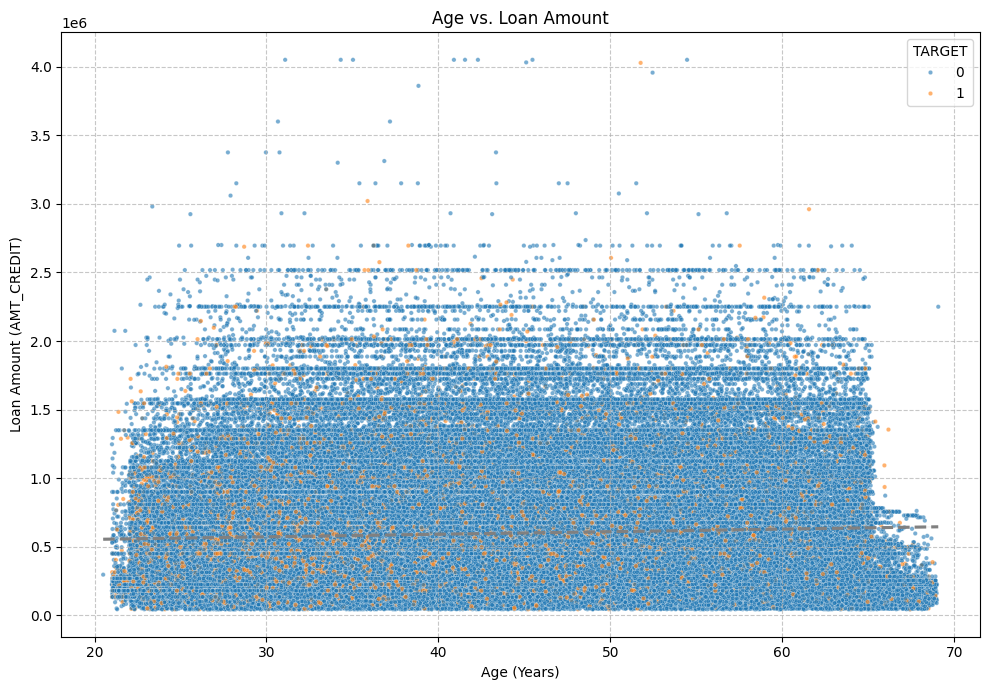

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert DAYS_BIRTH to AGE_YEARS for better interpretability
applicant_full['AGE_YEARS'] = -applicant_full['DAYS_BIRTH'] / 365.25

plt.figure(figsize=(10, 7))
sns.scatterplot(x='AGE_YEARS', y='AMT_CREDIT', hue='TARGET', data=applicant_full, alpha=0.6, s=10)
sns.regplot(x='AGE_YEARS', y='AMT_CREDIT', data=applicant_full, scatter=False, color='gray', line_kws={'linestyle':'--'})
plt.title('Age vs. Loan Amount')
plt.xlabel('Age (Years)')
plt.ylabel('Loan Amount (AMT_CREDIT)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 6. Count Plots for Key Categorical Features

These count plots visualize the distribution of key categorical features, showing the number of applicants in each category. This helps in understanding the composition of the applicant pool across different income types, education levels, and occupation types, and can reveal potential imbalances or dominant groups.

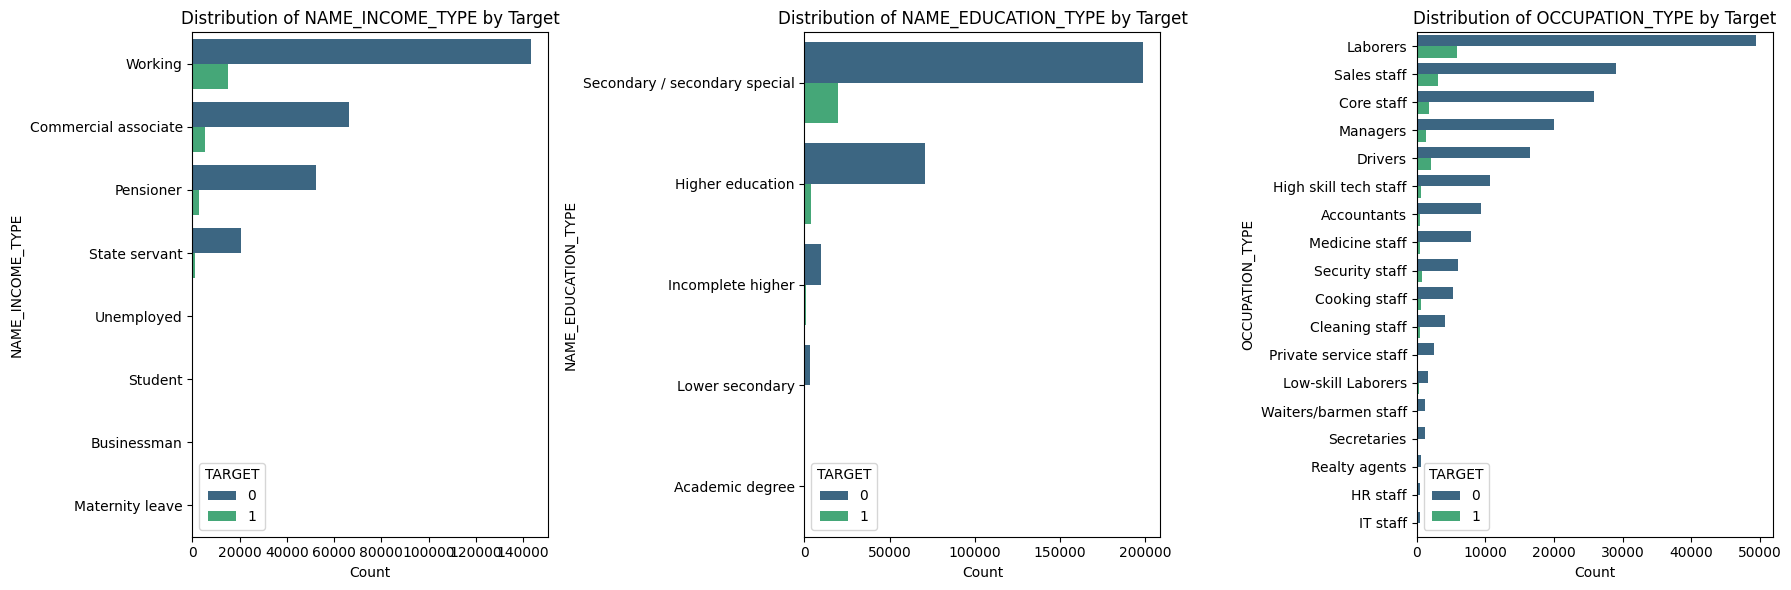

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of key categorical columns to visualize
key_categorical_cols = [
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'OCCUPATION_TYPE'
]

plt.figure(figsize=(18, 6))
for i, col in enumerate(key_categorical_cols, 1):
    plt.subplot(1, 3, i) # Arrange plots in a 1x3 grid
    sns.countplot(y=col, data=applicant_full, hue='TARGET', palette='viridis', order=applicant_full[col].value_counts().index)
    plt.title(f'Distribution of {col} by Target')
    plt.xlabel('Count')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### Default Rate by Occupation Type

This plot shows the proportion of applicants who default (`TARGET=1`) within each `OCCUPATION_TYPE`. This can reveal if certain occupations are associated with a higher or lower risk of default.

/tmp/ipykernel_1251/2608363558.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='OCCUPATION_TYPE', y='TARGET', data=default_rate_by_occupation, palette='rocket')


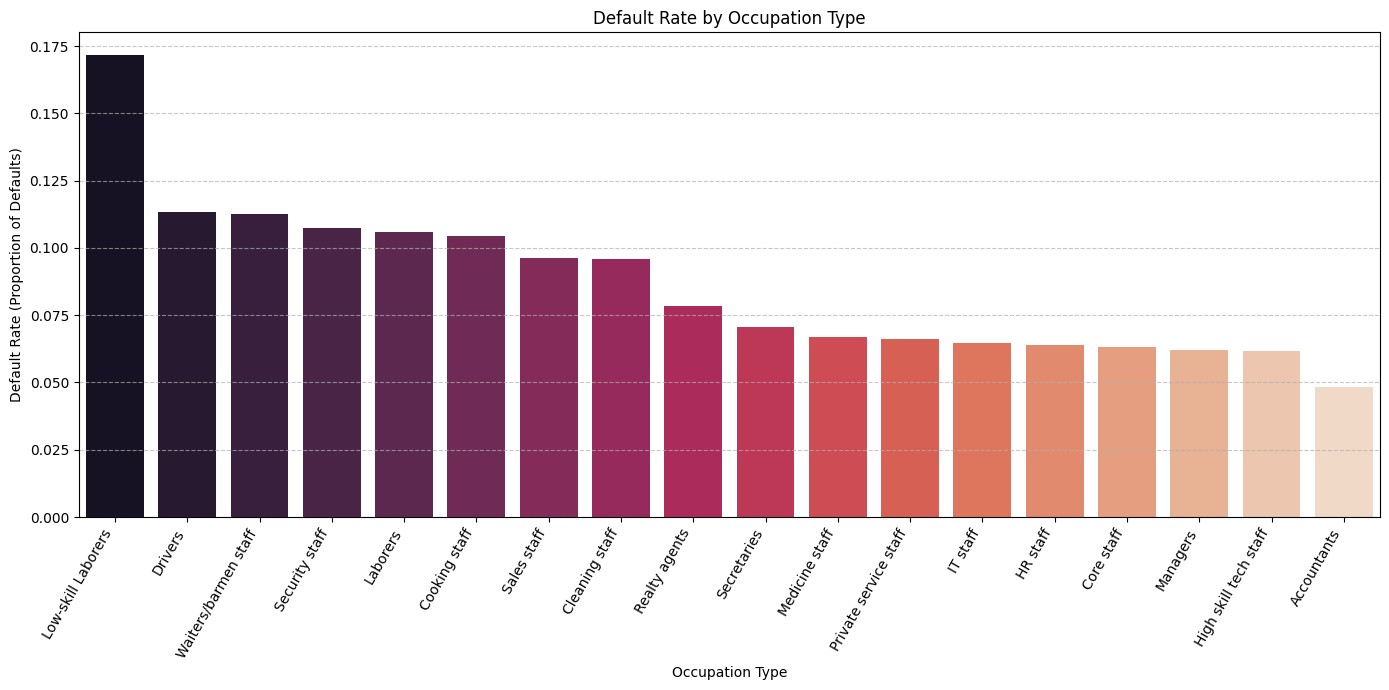

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate default rate for each occupation type
default_rate_by_occupation = applicant_full.groupby('OCCUPATION_TYPE')['TARGET'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(x='OCCUPATION_TYPE', y='TARGET', data=default_rate_by_occupation, palette='rocket')
plt.title('Default Rate by Occupation Type')
plt.xlabel('Occupation Type')
plt.ylabel('Default Rate (Proportion of Defaults)')
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [83]:
# Calculate Q1, Q3, and IQR for AMT_INCOME_TOTAL
Q1 = applicant_full['AMT_INCOME_TOTAL'].quantile(0.25)
Q3 = applicant_full['AMT_INCOME_TOTAL'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count outliers
outliers = applicant_full[(applicant_full['AMT_INCOME_TOTAL'] < lower_bound) | (applicant_full['AMT_INCOME_TOTAL'] > upper_bound)]

print(f"Q1 (25th percentile): {Q1:,.2f}")
print(f"Q3 (75th percentile): {Q3:,.2f}")
print(f"IQR: {IQR:,.2f}")
print(f"Lower bound for outliers: {lower_bound:,.2f}")
print(f"Upper bound for outliers: {upper_bound:,.2f}")

print(f"\nNumber of outliers in AMT_INCOME_TOTAL: {len(outliers)}")
print(f"Percentage of outliers: {len(outliers) / len(applicant_full) * 100:.2f}%")

# Display descriptive statistics for AMT_INCOME_TOTAL to see min/max values
print("\nDescriptive statistics for AMT_INCOME_TOTAL:")
display(applicant_full['AMT_INCOME_TOTAL'].describe())

Q1 (25th percentile): 112,500.00
Q3 (75th percentile): 202,500.00
IQR: 90,000.00
Lower bound for outliers: -22,500.00
Upper bound for outliers: 337,500.00

Number of outliers in AMT_INCOME_TOTAL: 14035
Percentage of outliers: 4.56%

Descriptive statistics for AMT_INCOME_TOTAL:


,AMT_INCOME_TOTAL
count,3.075110e+05
mean,1.687979e+05
std,2.371231e+05
min,2.565000e+04
25%,1.125000e+05
50%,1.471500e+05
75%,2.025000e+05
max,1.170000e+08


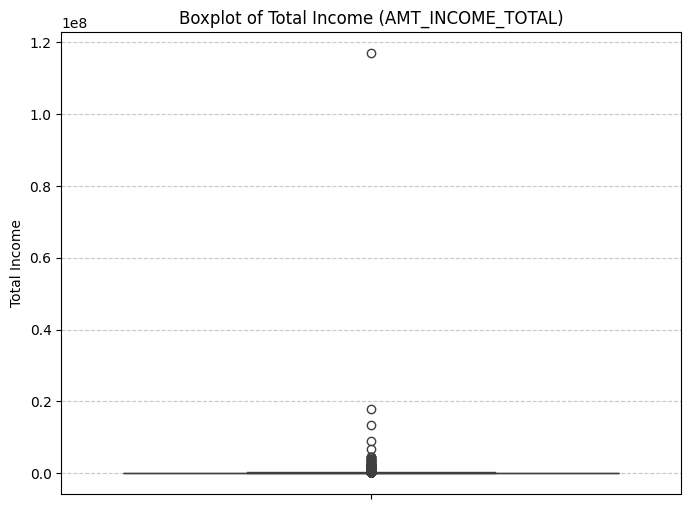

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=applicant_full['AMT_INCOME_TOTAL'])
plt.title('Boxplot of Total Income (AMT_INCOME_TOTAL)')
plt.ylabel('Total Income')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 7. Comparative Distributions of Key Variables by Default Status

These histograms visualize the distributions of important numerical features, separated by `TARGET` status (0 for non-default, 1 for default). This helps in understanding how the values of these variables differ between applicants who repay their loans and those who default. Overlapping distributions indicate that single variables alone may not be strong discriminators. The plots highlight key areas of difference mentioned in your summary, such as defaults being more concentrated among younger applicants and those with lower external scores.

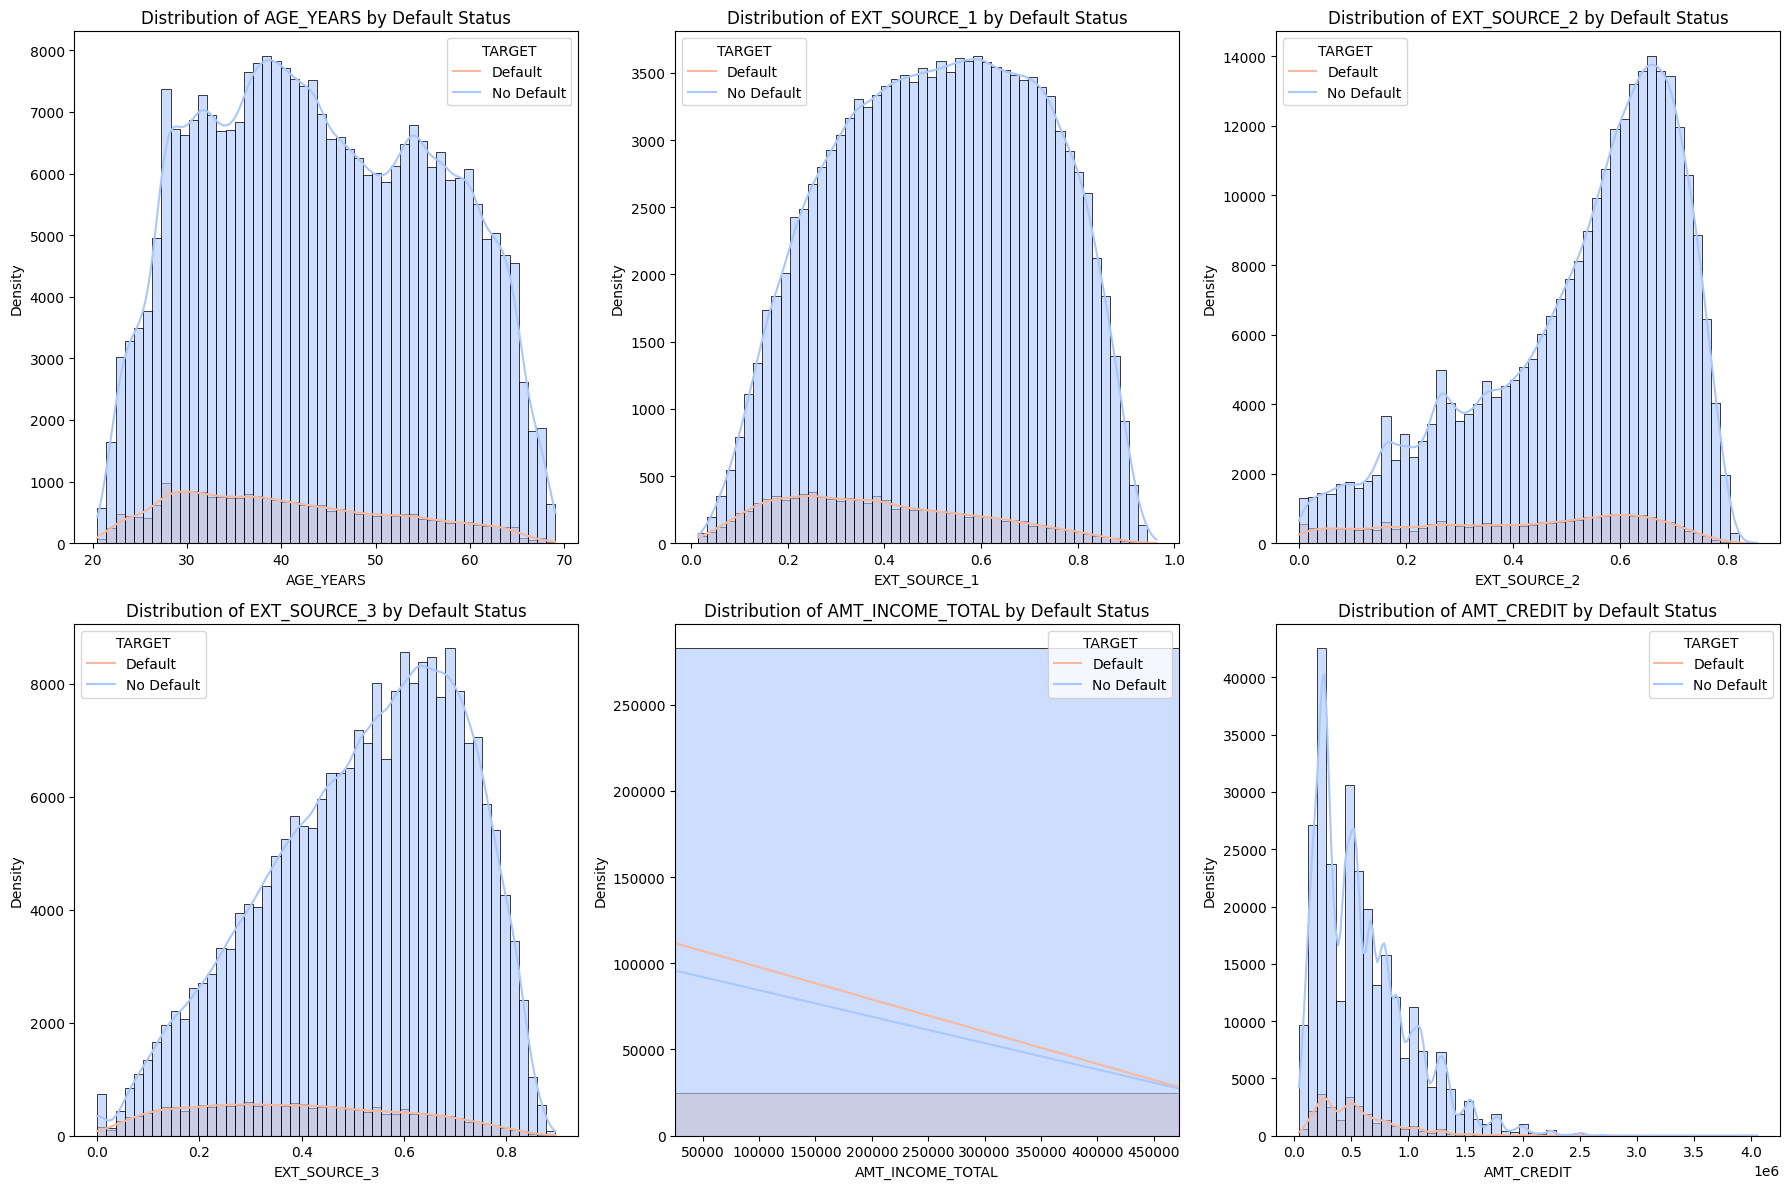

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Re-create AGE_YEARS as it was dropped previously for plotting purposes
applicant_full['AGE_YEARS'] = -applicant_full['DAYS_BIRTH'] / 365.25

# Define key variables for comparison
key_vars = [
    'AGE_YEARS',
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3',
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT'
]

# Create subplots for each variable, arranged as 2 rows and 3 columns
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12)) # Changed nrows=3, ncols=2 to nrows=2, ncols=3, and adjusted figsize
axes = axes.flatten() # Flatten the 2x3 array of axes for easy iteration

for i, col in enumerate(key_vars):
    sns.histplot(
        data=applicant_full,
        x=col,
        hue='TARGET',
        kde=True, # Show Kernel Density Estimate
        ax=axes[i],
        palette='coolwarm',
        alpha=0.6, # Transparency
        bins=50 # Number of bins
    )
    axes[i].set_title(f'Distribution of {col} by Default Status', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Density', fontsize=10)
    axes[i].legend(title='TARGET', labels=['Default', 'No Default'])

    # Special handling for AMT_INCOME_TOTAL to address scale distortion due to outliers
    if col == 'AMT_INCOME_TOTAL':
        # Zoom in on the main distribution by setting x-axis limit
        # Using a quantile to avoid extreme outliers distorting the view
        upper_limit = applicant_full[col].quantile(0.99)
        axes[i].set_xlim(applicant_full[col].min(), upper_limit)

plt.tight_layout()
plt.show()

# **Data Pre-Processing & Cleaning**

In [86]:
# Dropping unnecessary columns with huge number of null values
# Make a copy first (optional, for safety)
applicant_full_copy=applicant_full.copy()
applicant_full.drop(columns=['OWN_CAR_AGE', 'YEARS_BUILD_MODE','YEARS_BUILD_MEDI','YEARS_BUILD_AVG','FLOORSMIN_AVG','FLOORSMIN_MEDI','FLOORSMIN_MODE','LIVINGAPARTMENTS_MEDI','LIVINGAPARTMENTS_MODE','LIVINGAPARTMENTS_AVG','FONDKAPREMONT_MODE','NONLIVINGAPARTMENTS_AVG','NONLIVINGAPARTMENTS_MEDI','NONLIVINGAPARTMENTS_MODE','COMMONAREA_AVG','COMMONAREA_MEDI','COMMONAREA_MODE'], inplace=True)


In [87]:

# Drop collateral/property features
applicant_full.drop(
    columns=[
        'LANDAREA_MODE','LANDAREA_AVG','LANDAREA_MEDI',
        'BASEMENTAREA_MODE','BASEMENTAREA_AVG','BASEMENTAREA_MEDI',
        'NONLIVINGAREA_MODE','NONLIVINGAREA_MEDI','NONLIVINGAREA_AVG',
        'ELEVATORS_MODE','ELEVATORS_MEDI','ELEVATORS_AVG',
        'WALLSMATERIAL_MODE',
        'APARTMENTS_AVG','APARTMENTS_MEDI','APARTMENTS_MODE',
        'ENTRANCES_AVG','ENTRANCES_MODE','ENTRANCES_MEDI',
        'LIVINGAREA_AVG','LIVINGAREA_MEDI','LIVINGAREA_MODE',
        'HOUSETYPE_MODE',
        'FLOORSMAX_AVG','FLOORSMAX_MEDI','FLOORSMAX_MODE',
        'YEARS_BEGINEXPLUATATION_AVG','YEARS_BEGINEXPLUATATION_MEDI','YEARS_BEGINEXPLUATATION_MODE',
        'TOTALAREA_MODE',
        'EMERGENCYSTATE_MODE'
    ],
    inplace=True
)

# Quick check: confirm shape and that columns are gone

print("New shape:", applicant_full.shape)
print("Remaining nulls:\n", applicant_full.isnull().sum().sort_values(ascending=False).head(20))

New shape: (307511, 88)
Remaining nulls:
 MONTHS_BALANCE_count           215280
STATUS_NUM_mean                215280
STATUS_NUM_max                 215280
EXT_SOURCE_1                   173378
OCCUPATION_TYPE                 96391
EXT_SOURCE_3                    60965
AMT_CREDIT_SUM_DEBT_mean        51380
AMT_CREDIT_SUM_mean             44021
DAYS_CREDIT_mean                44020
AMT_CREDIT_SUM_OVERDUE_max      44020
CREDIT_ACTIVE_<lambda>          44020
DAYS_CREDIT_min                 44020
CREDIT_TYPE_nunique             44020
AMT_CREDIT_SUM_sum              44020
AMT_CREDIT_SUM_OVERDUE_mean     44020
AMT_CREDIT_SUM_DEBT_sum         44020
AMT_REQ_CREDIT_BUREAU_MON       41519
AMT_REQ_CREDIT_BUREAU_HOUR      41519
AMT_REQ_CREDIT_BUREAU_YEAR      41519
AMT_REQ_CREDIT_BUREAU_QRT       41519
dtype: int64


EXT_SOURCE_1 skewness: -0.06875505870176415


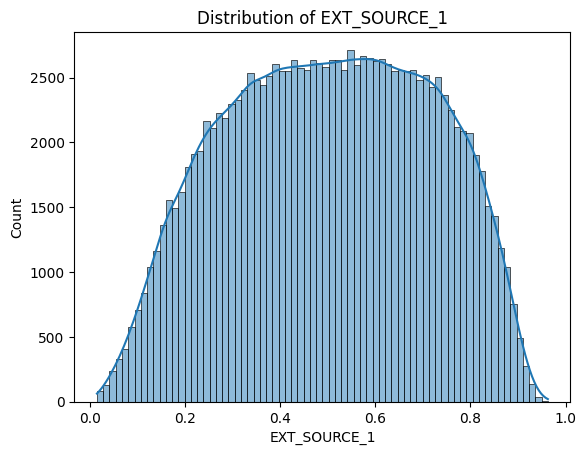

EXT_SOURCE_2 skewness: -0.7935760449636996


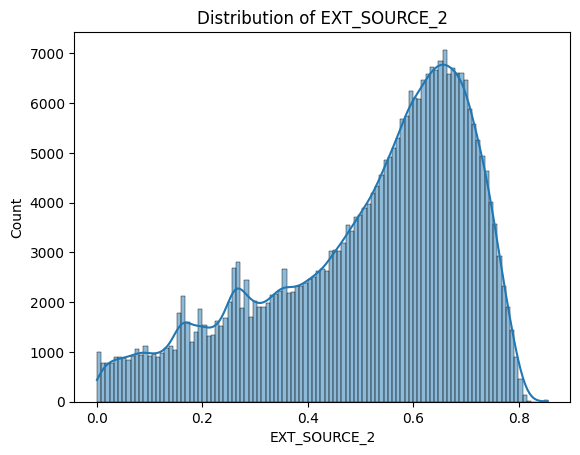

EXT_SOURCE_3 skewness: -0.4093904596160267


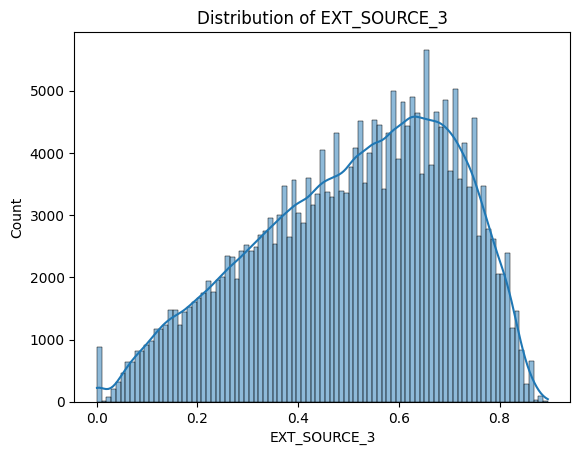

In [88]:
# check the skewness to decide should i compute with medain or mean
import matplotlib.pyplot as plt
import seaborn as sns

for col in ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']:
    print(f"{col} skewness:", applicant_full[col].skew())
    sns.histplot(applicant_full[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()
    #  EXT_SOURCE_3 skewness: -0.409 median imputation would  be fine
    #  EXT_SOURCE_2 skewness: -0.794 Median is safer here, because the mean would be pulled downward by the tail
    #  EXT_SOURCE_1 skewness: -0.069 - Mean imputation is fine here






In [89]:
# imputation of null values of EXT_SOURCES
import pandas as pd

# EXT_SOURCE_1 ~ symmetric → mean imputation
applicant_full['EXT_SOURCE_1_missing'] = applicant_full['EXT_SOURCE_1'].isnull().astype(int)
applicant_full['EXT_SOURCE_1'].fillna(applicant_full['EXT_SOURCE_1'].mean(), inplace=True)

# EXT_SOURCE_2 ~ negative skew → median imputation
applicant_full['EXT_SOURCE_2_missing'] = applicant_full['EXT_SOURCE_2'].isnull().astype(int)
applicant_full['EXT_SOURCE_2'].fillna(applicant_full['EXT_SOURCE_2'].median(), inplace=True)

# EXT_SOURCE_3 ~ slightly skewed → median imputation (safer)
applicant_full['EXT_SOURCE_3_missing'] = applicant_full['EXT_SOURCE_3'].isnull().astype(int)
applicant_full['EXT_SOURCE_3'].fillna(applicant_full['EXT_SOURCE_3'].median(), inplace=True)

# Quick check
print(applicant_full[['EXT_SOURCE_1','EXT_SOURCE_1_missing']].head())
print(applicant_full[['EXT_SOURCE_2','EXT_SOURCE_2_missing']].head())
print(applicant_full[['EXT_SOURCE_3','EXT_SOURCE_3_missing']].head())

   EXT_SOURCE_1  EXT_SOURCE_1_missing
0      0.083037                     0
1      0.311267                     0
2      0.502130                     1
3      0.502130                     1
4      0.502130                     1
   EXT_SOURCE_2  EXT_SOURCE_2_missing
0      0.262949                     0
1      0.622246                     0
2      0.555912                     0
3      0.650442                     0
4      0.322738                     0
   EXT_SOURCE_3  EXT_SOURCE_3_missing
0      0.139376                     0
1      0.535276                     1
2      0.729567                     0
3      0.535276                     1
4      0.535276                     1


/tmp/ipykernel_1251/1801826079.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  applicant_full['EXT_SOURCE_1'].fillna(applicant_full['EXT_SOURCE_1'].mean(), inplace=True)
/tmp/ipykernel_1251/1801826079.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 

In [90]:
# imputing the null values of OCCUPATION_TYPE and preserve the fact that the occupation was not declared
# Add "Unknown" for missing occupation values
applicant_full['OCCUPATION_TYPE'].fillna('Unknown', inplace=True)

# Quick check
print(applicant_full['OCCUPATION_TYPE'].value_counts(dropna=False).head(10))

OCCUPATION_TYPE
Unknown                  96391
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Name: count, dtype: int64


/tmp/ipykernel_1251/2392125680.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  applicant_full['OCCUPATION_TYPE'].fillna('Unknown', inplace=True)


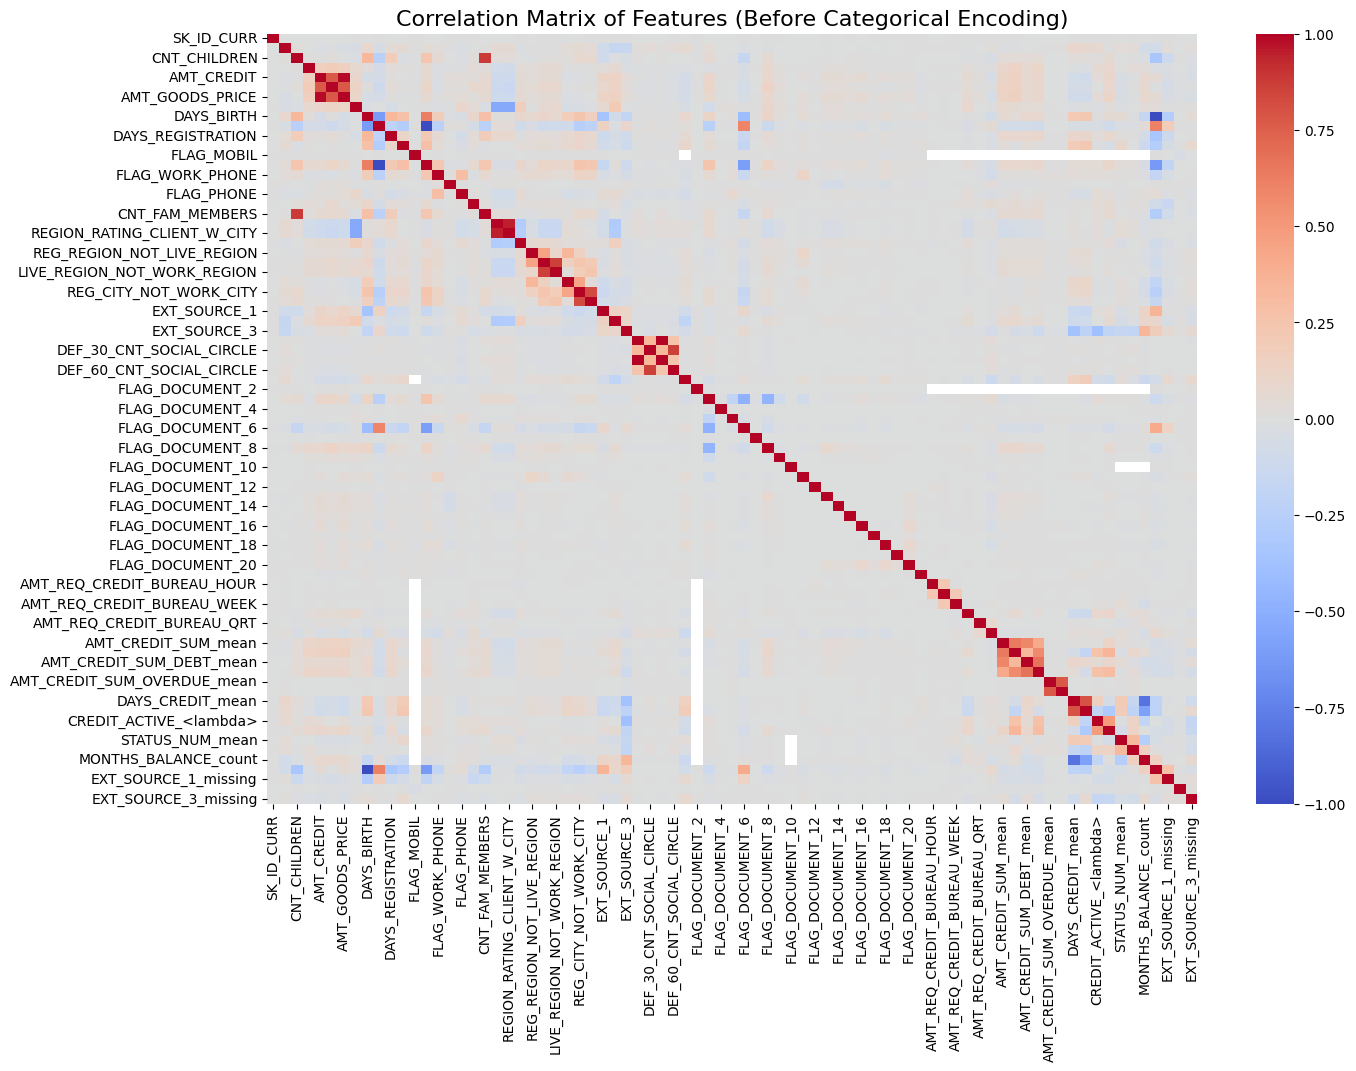

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Select only numerical columns from applicant_full
numeric_applicant_full = applicant_full.select_dtypes(include=np.number)

# Compute correlation matrix for numeric columns
corr_matrix = numeric_applicant_full.corr()

# Plot heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".2f")
plt.title("Correlation Matrix of Features (Before Categorical Encoding)", fontsize=16)
plt.show()

In [92]:
# Show correlations with the TARGET variable
target_corr = corr_matrix['TARGET'].sort_values(ascending=False)
print("Correlations with TARGET (Before Categorical Encoding):")
print(target_corr)

Correlations with TARGET (Before Categorical Encoding):
TARGET                         1.000000
DAYS_CREDIT_mean               0.089729
DAYS_BIRTH                     0.078239
DAYS_CREDIT_min                0.075248
CREDIT_ACTIVE_<lambda>         0.067128
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
STATUS_NUM_mean                0.044195
DAYS_REGISTRATION              0.041975
STATUS_NUM_max                 0.034279
LIVE_CITY_NOT_WORK_CITY        0.032518
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
DEF_60_CNT_SOCIAL_CIRCLE       0.031276
FLAG_WORK_PHONE                0.028524
EXT_SOURCE_3_missing           0.022617
AMT_REQ_CREDIT_BUREAU_YEAR     0.019930
CNT_CHILDREN                   0.019187
EXT_SOURCE_1_missing    

In [93]:
# Identify categorical columns (object or category dtype)
categorical_cols = applicant_full.select_dtypes(include=['object', 'category']).columns

# Loop through each categorical column and print unique values to use in encoding
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(applicant_full[col].unique())
    print(f"Number of unique values: {applicant_full[col].nunique()}")


Column: NAME_CONTRACT_TYPE
['Cash loans' 'Revolving loans']
Number of unique values: 2

Column: CODE_GENDER
['M' 'F' 'XNA']
Number of unique values: 3

Column: FLAG_OWN_CAR
['N' 'Y']
Number of unique values: 2

Column: FLAG_OWN_REALTY
['Y' 'N']
Number of unique values: 2

Column: NAME_TYPE_SUITE
['Unaccompanied' 'Family' 'Spouse, partner' 'Children' 'Other_A' nan
 'Other_B' 'Group of people']
Number of unique values: 7

Column: NAME_INCOME_TYPE
['Working' 'State servant' 'Commercial associate' 'Pensioner' 'Unemployed'
 'Student' 'Businessman' 'Maternity leave']
Number of unique values: 8

Column: NAME_EDUCATION_TYPE
['Secondary / secondary special' 'Higher education' 'Incomplete higher'
 'Lower secondary' 'Academic degree']
Number of unique values: 5

Column: NAME_FAMILY_STATUS
['Single / not married' 'Married' 'Civil marriage' 'Widow' 'Separated'
 'Unknown']
Number of unique values: 6

Column: NAME_HOUSING_TYPE
['House / apartment' 'Rented apartment' 'With parents'
 'Municipal apartm

In [94]:
# -----------------------------
# Data Preprocessing: Impute CODE_GENDER with mode
# -----------------------------
import pandas as pd

# Replace 'XNA' with NaN for consistency
applicant_full['CODE_GENDER'] =applicant_full['CODE_GENDER'].replace("XNA", pd.NA)

# Compute mode (most frequent value)
mode_val = applicant_full['CODE_GENDER'].mode(dropna=True)[0]

# Fill NaN with mode
applicant_full['CODE_GENDER'] = applicant_full['CODE_GENDER'].fillna(mode_val)

# Sanity check: print unique values after imputation
print("Unique values in CODE_GENDER after preprocessing:", applicant_full['CODE_GENDER'].unique())

Unique values in CODE_GENDER after preprocessing: ['M' 'F']


In [95]:
applicant_full.head(10)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AMT_CREDIT_SUM_mean,AMT_CREDIT_SUM_sum,AMT_CREDIT_SUM_DEBT_mean,AMT_CREDIT_SUM_DEBT_sum,AMT_CREDIT_SUM_OVERDUE_mean,AMT_CREDIT_SUM_OVERDUE_max,DAYS_CREDIT_mean,DAYS_CREDIT_min,CREDIT_ACTIVE_<lambda>,CREDIT_TYPE_nunique,STATUS_NUM_mean,STATUS_NUM_max,MONTHS_BALANCE_count,AGE_YEARS,EXT_SOURCE_1_missing,EXT_SOURCE_2_missing,EXT_SOURCE_3_missing
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,108131.945625,865055.565,49156.200000,245781.0,0.0,0.0,-874.000000,-1437.0,2.0,2.0,-0.243608,1.0,13.75,25.902806,0,0,0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,0.535276,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,254350.125000,1017400.500,0.000000,0.0,0.0,0.0,-1400.750000,-2586.0,1.0,2.0,NaN,NaN,NaN,45.900068,0,0,1
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,0.502130,0.555912,0.729567,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,94518.900000,189037.800,0.000000,0.0,0.0,0.0,-867.000000,-1326.0,0.0,1.0,NaN,NaN,NaN,52.145106,1,0,0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,0.502130,0.650442,0.535276,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.032854,1,0,1
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038,-4311.0,-3458,1,1,0,1,0,0,Core staff,1.0,2,2,THURSDAY,11,0,0,0,0,1,1,Religion,0.502130,0.322738,0.535276,0.0,0.0,0.0,0.0,-1106.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,146250.000000,146250.000,0.000000,0.0,0.0,0.0,-1149.000000,-1149.

In [96]:
# Count how many rows have ORGANIZATION_TYPE = 'XNA'
xna_count = applicant_full[applicant_full['ORGANIZATION_TYPE'] == 'XNA'].shape[0]
print("Number of XNA values in ORGANIZATION_TYPE:", xna_count)

# Or more directly:
print(applicant_full['ORGANIZATION_TYPE'].value_counts())

Number of XNA values in ORGANIZATION_TYPE: 55374
ORGANIZATION_TYPE
Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Industry: type 3           3278
Security                   3247
Housing                    2958
Industry: type 11          2704
Military                   2634
Bank                       2507
Agriculture                2454
Police                     2341
Transport: type 2          2204
Postal                     2157
Security Ministries        1974
Trade: type 2              1900
Restaurant                 1811
Services                   1575
Unive

In [97]:
# Replace XNA values in ORGANIZATION_TYPE with the mode
applicant_full['ORGANIZATION_TYPE'] = applicant_full['ORGANIZATION_TYPE'].replace('XNA', 'Business Entity Type 3')

# Quick check
print(applicant_full['ORGANIZATION_TYPE'].value_counts().head())

ORGANIZATION_TYPE
Business Entity Type 3    123366
Self-employed              38412
Other                      16683
Medicine                   11193
Business Entity Type 2     10553
Name: count, dtype: int64


In [98]:
import numpy as np

# Replace placeholder 365243 with NaN
applicant_full['DAYS_EMPLOYED'] = applicant_full['DAYS_EMPLOYED'].replace(365243, np.nan)

In [99]:
 #Binary categories (2 unique values → Label Encoding)
# -----------------------------
# Label Encoding for binary categorical columns with mapping
# -----------------------------
from sklearn.preprocessing import LabelEncoder

# List of binary categorical columns
binary_cols = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']

for col in binary_cols:
    le = LabelEncoder()
    le.fit(applicant_full[col])  # fit on original string values

    # Show mapping before overwriting
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"\nColumn: {col}")
    print("Classes:", le.classes_)
    print("Mapping:", mapping)

    # Now transform and overwrite the column
    applicant_full[col] = le.transform(applicant_full[col])

# Quick check of encoded values
print("\nHead of encoded binary columns:")
print(applicant_full[binary_cols].head())




Column: NAME_CONTRACT_TYPE
Classes: ['Cash loans' 'Revolving loans']
Mapping: {'Cash loans': np.int64(0), 'Revolving loans': np.int64(1)}

Column: CODE_GENDER
Classes: ['F' 'M']
Mapping: {'F': np.int64(0), 'M': np.int64(1)}

Column: FLAG_OWN_CAR
Classes: ['N' 'Y']
Mapping: {'N': np.int64(0), 'Y': np.int64(1)}

Column: FLAG_OWN_REALTY
Classes: ['N' 'Y']
Mapping: {'N': np.int64(0), 'Y': np.int64(1)}

Head of encoded binary columns:
   NAME_CONTRACT_TYPE  CODE_GENDER  FLAG_OWN_CAR  FLAG_OWN_REALTY
0                   0            1             0                1
1                   0            0             0                0
2                   1            1             1                1
3                   0            0             0                1
4                   0            1             0                1


In [100]:
# Define manual mapping for education levels as ordinal encoding as there is rank
education_mapping = {
    'Lower secondary': 0,
    'Secondary / secondary special': 1,
    'Incomplete higher': 2,
    'Higher education': 3,
    'Academic degree': 4
}

# Apply mapping
applicant_full['NAME_EDUCATION_TYPE'] = applicant_full['NAME_EDUCATION_TYPE'].map(education_mapping)

# Quick check
print(applicant_full['NAME_EDUCATION_TYPE'].unique())

[1 3 2 0 4]


In [101]:
# Small categorical columns for one-hot encoding
small_cats = [
    'NAME_TYPE_SUITE',
    'NAME_INCOME_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'WEEKDAY_APPR_PROCESS_START'
]

# One-hot encode with 0/1 flags
applicant_full = pd.get_dummies(
    applicant_full,
    columns=small_cats,
    prefix=small_cats,
    dtype=int  # ensures output is integers (0/1)
)

# Quick check
print(applicant_full.filter(like='NAME_TYPE_SUITE').head())

# Quick check: see new columns created
print(applicant_full.shape)
print([col for col in applicant_full.columns if any(cat in col for cat in small_cats)][:15])  # show first 15 new columns

   NAME_TYPE_SUITE_Children  NAME_TYPE_SUITE_Family  \
0                         0                       0   
1                         0                       1   
2                         0                       0   
3                         0                       0   
4                         0                       0   

   NAME_TYPE_SUITE_Group of people  NAME_TYPE_SUITE_Other_A  \
0                                0                        0   
1                                0                        0   
2                                0                        0   
3                                0                        0   
4                                0                        0   

   NAME_TYPE_SUITE_Other_B  NAME_TYPE_SUITE_Spouse, partner  \
0                        0                                0   
1                        0                                0   
2                        0                                0   
3                        0            

In [102]:
# -----------------------------
# Label Encoding for  multi-category columns with mapping
# -----------------------------
from sklearn.preprocessing import LabelEncoder

# Columns to label encode
label_cols = ['ORGANIZATION_TYPE', 'OCCUPATION_TYPE']

# Apply Label Encoding to each column
for col in label_cols:
    le = LabelEncoder()
    le.fit(applicant_full[col])  # fit on original string values

    # Show mapping before overwriting
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"\nColumn: {col}")
    print("Classes:", le.classes_)
    print("Mapping:", mapping)

    # Now transform and overwrite the column
    applicant_full[col] = le.transform(applicant_full[col])

# Quick check of encoded values
for col in label_cols:
    print(f"\n{col} encoded values (first 10 unique codes): {applicant_full[col].unique()[:10]}")


Column: ORGANIZATION_TYPE
Classes: ['Advertising' 'Agriculture' 'Bank' 'Business Entity Type 1'
 'Business Entity Type 2' 'Business Entity Type 3' 'Cleaning'
 'Construction' 'Culture' 'Electricity' 'Emergency' 'Government' 'Hotel'
 'Housing' 'Industry: type 1' 'Industry: type 10' 'Industry: type 11'
 'Industry: type 12' 'Industry: type 13' 'Industry: type 2'
 'Industry: type 3' 'Industry: type 4' 'Industry: type 5'
 'Industry: type 6' 'Industry: type 7' 'Industry: type 8'
 'Industry: type 9' 'Insurance' 'Kindergarten' 'Legal Services' 'Medicine'
 'Military' 'Mobile' 'Other' 'Police' 'Postal' 'Realtor' 'Religion'
 'Restaurant' 'School' 'Security' 'Security Ministries' 'Self-employed'
 'Services' 'Telecom' 'Trade: type 1' 'Trade: type 2' 'Trade: type 3'
 'Trade: type 4' 'Trade: type 5' 'Trade: type 6' 'Trade: type 7'
 'Transport: type 1' 'Transport: type 2' 'Transport: type 3'
 'Transport: type 4' 'University']
Mapping: {'Advertising': np.int64(0), 'Agriculture': np.int64(1), 'Bank': np

In [103]:
import pandas as pd
import numpy as np

# Impute numeric columns in applicant_full using mean/median based on skewness

def impute_numeric(applicant_full, cols):

    for col in cols:
        if col in applicant_full.columns:
            # Check skewness
            skew = applicant_full[col].skew(skipna=True)
            if abs(skew) > 1:  # highly skewed
                fill_val = applicant_full[col].median()
                method = "median"
            else:
                fill_val = applicant_full[col].mean()
                method = "mean"
            applicant_full[col] = applicant_full[col].fillna(fill_val)
            print(f"{col}: imputed with {method} ({fill_val:.2f})")
    return applicant_full

# Example usage
numeric_cols = [
    'STATUS_NUM_max','STATUS_NUM_mean','MONTHS_BALANCE_count','DAYS_EMPLOYED'
    'AMT_CREDIT_SUM_DEBT_mean','AMT_CREDIT_SUM_mean','AMT_CREDIT_SUM_sum',
    'AMT_CREDIT_SUM_DEBT_sum','DAYS_CREDIT_mean','CREDIT_ACTIVE_<lambda>',
    'AMT_CREDIT_SUM_OVERDUE_mean','DAYS_CREDIT_min','CREDIT_TYPE_nunique',
    'AMT_CREDIT_SUM_OVERDUE_max','AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_QRT','AMT_REQ_CREDIT_BUREAU_YEAR',
    'AMT_REQ_CREDIT_BUREAU_HOUR','AMT_REQ_CREDIT_BUREAU_WEEK',
    'AMT_REQ_CREDIT_BUREAU_MON','DEF_30_CNT_SOCIAL_CIRCLE',
    'OBS_60_CNT_SOCIAL_CIRCLE','DEF_60_CNT_SOCIAL_CIRCLE',
    'OBS_30_CNT_SOCIAL_CIRCLE','AMT_GOODS_PRICE','AMT_ANNUITY',
    'CNT_FAM_MEMBERS','DAYS_LAST_PHONE_CHANGE'
]

applicant_fullapplicant_full = impute_numeric(applicant_full, numeric_cols)

STATUS_NUM_max: imputed with median (0.00)
STATUS_NUM_mean: imputed with mean (-0.69)
MONTHS_BALANCE_count: imputed with mean (27.48)
AMT_CREDIT_SUM_mean: imputed with median (195507.18)
AMT_CREDIT_SUM_sum: imputed with median (961704.00)
AMT_CREDIT_SUM_DEBT_sum: imputed with median (169020.00)
DAYS_CREDIT_mean: imputed with mean (-1083.05)
CREDIT_ACTIVE_<lambda>: imputed with median (2.00)
AMT_CREDIT_SUM_OVERDUE_mean: imputed with median (0.00)
DAYS_CREDIT_min: imputed with mean (-1762.37)
CREDIT_TYPE_nunique: imputed with mean (1.74)
AMT_CREDIT_SUM_OVERDUE_max: imputed with median (0.00)
AMT_REQ_CREDIT_BUREAU_DAY: imputed with median (0.00)
AMT_REQ_CREDIT_BUREAU_QRT: imputed with median (0.00)
AMT_REQ_CREDIT_BUREAU_YEAR: imputed with median (1.00)
AMT_REQ_CREDIT_BUREAU_HOUR: imputed with median (0.00)
AMT_REQ_CREDIT_BUREAU_WEEK: imputed with median (0.00)
AMT_REQ_CREDIT_BUREAU_MON: imputed with median (0.00)
DEF_30_CNT_SOCIAL_CIRCLE: imputed with median (0.00)
OBS_60_CNT_SOCIAL_CIRCL

In [104]:
# Impute missing DAYS_EMPLOYED values with the median and create a missingness indicator
applicant_full['DAYS_EMPLOYED_missing'] = applicant_full['DAYS_EMPLOYED'].isnull().astype(int)
applicant_full['DAYS_EMPLOYED'].fillna(applicant_full['DAYS_EMPLOYED'].median(), inplace=True)

print("DAYS_EMPLOYED: imputed with median")
print(applicant_full[['DAYS_EMPLOYED', 'DAYS_EMPLOYED_missing']].head())

DAYS_EMPLOYED: imputed with median
   DAYS_EMPLOYED  DAYS_EMPLOYED_missing
0         -637.0                      0
1        -1188.0                      0
2         -225.0                      0
3        -3039.0                      0
4        -3038.0                      0


/tmp/ipykernel_1251/3008377648.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  applicant_full['DAYS_EMPLOYED'].fillna(applicant_full['DAYS_EMPLOYED'].median(), inplace=True)


In [105]:
# To know the columns with null values and the data type for each column after imputation

# Build table of null counts + dtypes
nulls_and_dtypes_after_imputation = applicant_full.isnull().sum().to_frame("null_count")
nulls_and_dtypes_after_imputation["dtype"] = applicant_full.dtypes

# Sort and display
print(nulls_and_dtypes_after_imputation.sort_values("null_count", ascending=False))

                                         null_count    dtype
AMT_CREDIT_SUM_DEBT_mean                      51380  float64
TARGET                                            0    int64
NAME_CONTRACT_TYPE                                0    int64
CODE_GENDER                                       0    int64
FLAG_OWN_CAR                                      0    int64
FLAG_OWN_REALTY                                   0    int64
CNT_CHILDREN                                      0    int64
AMT_INCOME_TOTAL                                  0  float64
SK_ID_CURR                                        0    int64
AMT_ANNUITY                                       0  float64
AMT_GOODS_PRICE                                   0  float64
NAME_EDUCATION_TYPE                               0    int64
REGION_POPULATION_RELATIVE                        0  float64
DAYS_BIRTH                                        0    int64
DAYS_EMPLOYED                                     0  float64
DAYS_REGISTRATION       

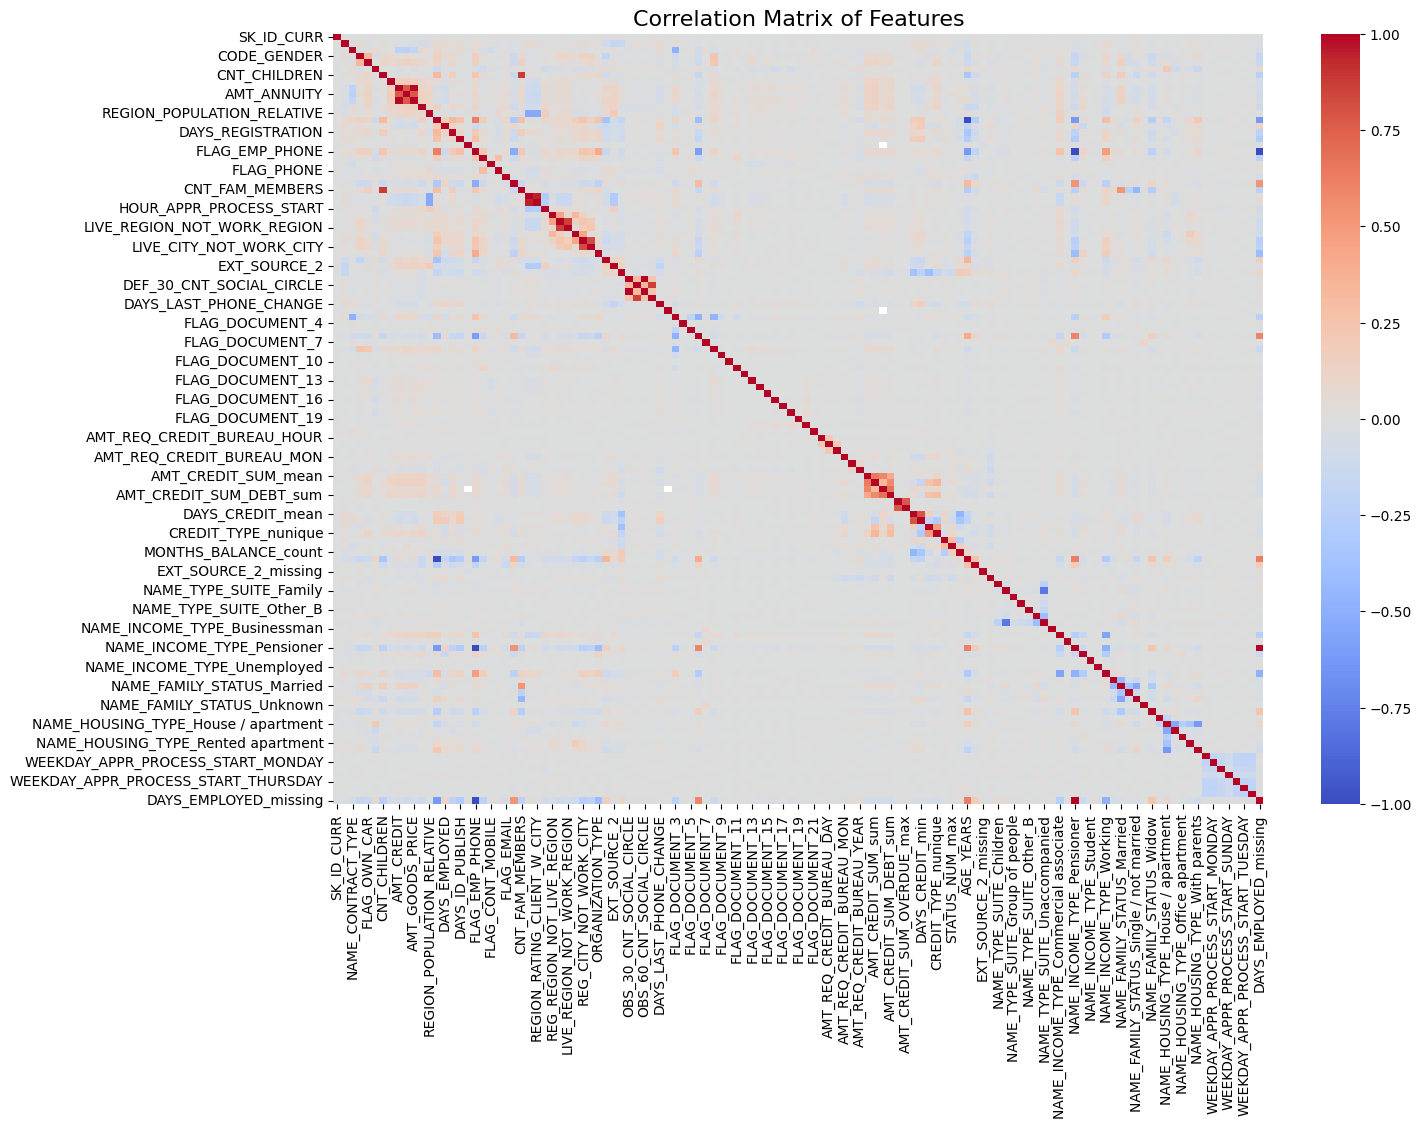

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = applicant_full.corr()

# Plot heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".2f")
plt.title("Correlation Matrix of Features", fontsize=16)
plt.show()

In [107]:
target_corr = corr_matrix['TARGET'].sort_values(ascending=False)
print(target_corr)

TARGET                                     1.000000
DAYS_CREDIT_mean                           0.081427
DAYS_BIRTH                                 0.078239
DAYS_CREDIT_min                            0.068286
DAYS_EMPLOYED                              0.063368
REGION_RATING_CLIENT_W_CITY                0.060893
CREDIT_ACTIVE_<lambda>                     0.060544
REGION_RATING_CLIENT                       0.058899
NAME_INCOME_TYPE_Working                   0.057481
DAYS_LAST_PHONE_CHANGE                     0.055218
CODE_GENDER                                0.054713
DAYS_ID_PUBLISH                            0.051457
REG_CITY_NOT_WORK_CITY                     0.050994
FLAG_EMP_PHONE                             0.045982
REG_CITY_NOT_LIVE_CITY                     0.044395
FLAG_DOCUMENT_3                            0.044346
DAYS_REGISTRATION                          0.041975
LIVE_CITY_NOT_WORK_CITY                    0.032518
DEF_30_CNT_SOCIAL_CIRCLE                   0.032394
DEF_60_CNT_S

In [108]:
# saving a copy of preprocsed data
applicant_full_clean=applicant_full.copy()

In [109]:
# dropping the unique column id
applicant_full = applicant_full.drop(columns=['SK_ID_CURR'])

Highly correlated features (absolute correlation > 0.9):
AMT_GOODS_PRICE and AMT_CREDIT have correlation 0.99
REGION_RATING_CLIENT_W_CITY and REGION_RATING_CLIENT have correlation 0.95
OBS_60_CNT_SOCIAL_CIRCLE and OBS_30_CNT_SOCIAL_CIRCLE have correlation 1.00
AGE_YEARS and DAYS_BIRTH have correlation 1.00
NAME_INCOME_TYPE_Pensioner and FLAG_EMP_PHONE have correlation 1.00
DAYS_EMPLOYED_missing and FLAG_EMP_PHONE have correlation 1.00
DAYS_EMPLOYED_missing and NAME_INCOME_TYPE_Pensioner have correlation 1.00


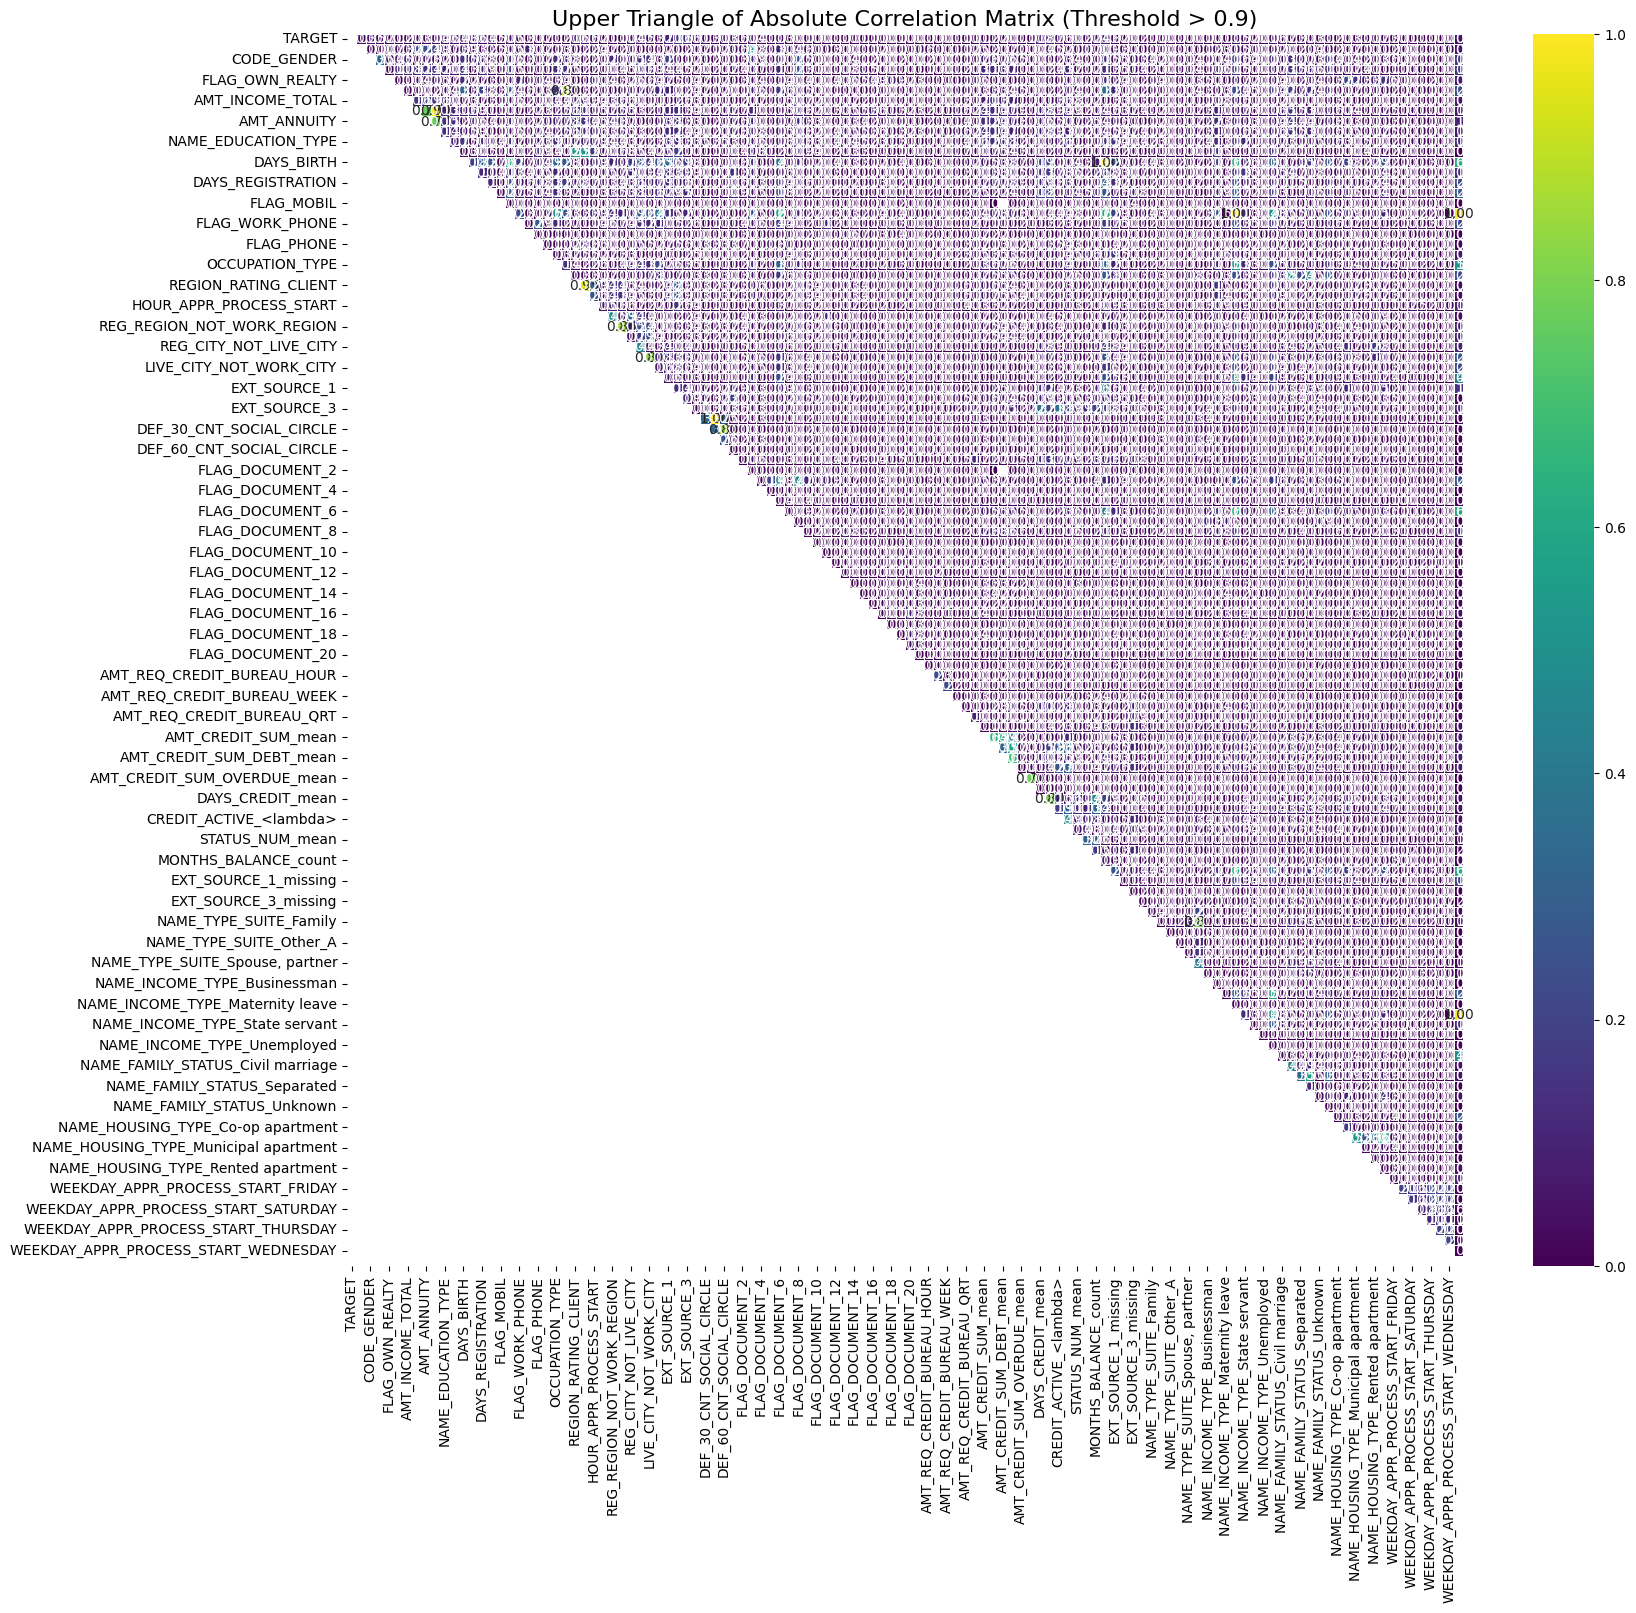

In [110]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Builds a correlation matrix.
# Extracts only the upper triangle to avoid duplicates.
# Finds pairs of features with correlation > 0.9.

# Compute correlation matrix
corr_matrix = applicant_full.corr().abs()

# Select upper triangle of correlation matrix (to avoid duplicates)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than threshold (e.g., 0.9)
high_corr = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if upper.loc[row, col] > 0.9
]

# Print results
print("Highly correlated features (absolute correlation > 0.9):")
for col1, col2, corr_val in high_corr:
    print(f"{col1} and {col2} have correlation {corr_val:.2f}")

# Visualize the upper triangle of the correlation matrix
plt.figure(figsize=(18, 16))
sns.heatmap(upper, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Upper Triangle of Absolute Correlation Matrix (Threshold > 0.9)', fontsize=16)
plt.show()

In [111]:
# Drop specific highly correlated or redundant columns
cols_to_drop = [
    'AMT_GOODS_PRICE',
    'FLAG_EMP_PHONE',
    'REGION_RATING_CLIENT',
    'OBS_30_CNT_SOCIAL_CIRCLE',
    'NAME_INCOME_TYPE_Pensioner'
]

applicant_full = applicant_full.drop(columns=cols_to_drop)

print("Dropped columns:", cols_to_drop)
print("New shape:", applicant_full.shape)

Dropped columns: ['AMT_GOODS_PRICE', 'FLAG_EMP_PHONE', 'REGION_RATING_CLIENT', 'OBS_30_CNT_SOCIAL_CIRCLE', 'NAME_INCOME_TYPE_Pensioner']
New shape: (307511, 115)


In [112]:
# Drop specific highly correlated or redundant columns
cols_to_drop = [
    'AGE_YEARS',
    'DAYS_EMPLOYED_missing'
]

applicant_full = applicant_full.drop(columns=cols_to_drop)

print("Dropped columns:", cols_to_drop)
print("New shape:", applicant_full.shape)

Dropped columns: ['AGE_YEARS', 'DAYS_EMPLOYED_missing']
New shape: (307511, 113)


In [113]:
applicant_full.head(10)

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,NAME_EDUCATION_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AMT_CREDIT_SUM_mean,AMT_CREDIT_SUM_sum,AMT_CREDIT_SUM_DEBT_mean,AMT_CREDIT_SUM_DEBT_sum,AMT_CREDIT_SUM_OVERDUE_mean,AMT_CREDIT_SUM_OVERDUE_max,DAYS_CREDIT_mean,DAYS_CREDIT_min,CREDIT_ACTIVE_<lambda>,CREDIT_TYPE_nunique,STATUS_NUM_mean,STATUS_NUM_max,MONTHS_BALANCE_count,EXT_SOURCE_1_missing,EXT_SOURCE_2_missing,EXT_SOURCE_3_missing,NAME_TYPE_SUITE_Children,NAME_TYPE_SUITE_Family,NAME_TYPE_SUITE_Group of people,NAME_TYPE_SUITE_Other_A,NAME_TYPE_SUITE_Other_B,"NAME_TYPE_SUITE_Spouse, partner",NAME_TYPE_SUITE_Unaccompanied,NAME_INCOME_TYPE_Businessman,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Maternity leave,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Unemployed,NAME_INCOME_TYPE_Working,NAME_FAMILY_STATUS_Civil marriage,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Unknown,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_Co-op apartment,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,WEEKDAY_APPR_PROCESS_START_FRIDAY,WEEKDAY_APPR_PROCESS_START_MONDAY,WEEKDAY_APPR_PROCESS_START_SATURDAY,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY
0,1,0,1,0,1,0,202500.0,406597.5,24700.5,1,0.018801,-9461,-637.0,-3648.0,-2120,1,0,1,1,0,8,1.0,2,10,0,0,0,0,0,0,5,0.083037,0.262949,0.139376,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,108131.945625,865055.565,49156.200000,245781.0,0.0,0.0,-874.000000,-1437.000000,2.0,2.000000,-0.243608,1.0,13.750000,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,270000.0,1293502.5,35698.5,3,0.003541,-16765,-1188.0,-1186.0,-291,1,0,1,1,0,3,2.0,1,11,0,0,0,0,0,0,39,0.311267,0.622246,0.535276,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,254350.125000,1017400.500,0.000000,0.0,0.0,0.0,-1400.750000,-2586.000000,1.0,2.000000,-0.689752,0.0,27.477237,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
2,0,1,1,1,1,0,67500.0,135000.0,6750.0,1,0.010032,-19046,-225.0,-4260.0,-2531,1,1,1,1,0,8,1.0,2,9,0,0,0,0,0,0,11,0.502130,0.555912,0.729567,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,94518.900000,189037.800,0.000000,0.0,0.0,0.0,-867.000000,-1326.000000,0.0,1.000000,-0.689752,0.0,27.477237,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,1,0,135000.0,312682.5,29686.5,1,0.008019,-19005,-3039.0,-9833.0,-2437,1,0,1,0,0,8,2.0,2,17,0,0,0,0,0,0,5,0.502130,0.650442,0.535276,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,195507

In [114]:
import numpy as np

# Identify numerical columns for capping
# Exclude 'TARGET' and any boolean/binary encoded columns that shouldn't be capped
# Also exclude any identifier columns or previously created missingness indicators
numerical_cols_for_capping = applicant_full.select_dtypes(include=np.number).columns.tolist()

# Remove 'TARGET' and any boolean/indicator columns (which are already 0 or 1)
if 'TARGET' in numerical_cols_for_capping:
    numerical_cols_for_capping.remove('TARGET')

# Remove binary encoded columns or indicator columns
# Assuming columns with less than 10 unique values (excluding NaN) are likely binary/ordinal encoded
#  refine the list to only include continuous or high-cardinality numerical features
# and explicitly exclude those already handled or binary.

# Get the list of all numerical columns that are not already binary or indicators
capping_candidates = []
for col in applicant_full.select_dtypes(include=np.number).columns:
    if col not in ['TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
                   'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL',
                   'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6',
                   'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11',
                   'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16',
                   'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21',
                   'NAME_EDUCATION_TYPE','EXT_SOURCE_1_missing','EXT_SOURCE_2_missing','EXT_SOURCE_3_missing']:
        capping_candidates.append(col)

print(f"Applying capping to {len(capping_candidates)} numerical columns.")

for col in capping_candidates:
    # Calculate 1st and 99th percentiles
    lower_bound = applicant_full[col].quantile(0.01)
    upper_bound = applicant_full[col].quantile(0.99)

    # Apply capping
    applicant_full[col] = np.clip(applicant_full[col], lower_bound, upper_bound)
    print(f"  Capped '{col}' between {lower_bound:.2f} and {upper_bound:.2f}")

print("\nOutlier capping applied successfully.")

Applying capping to 79 numerical columns.
  Capped 'CNT_CHILDREN' between 0.00 and 3.00
  Capped 'AMT_INCOME_TOTAL' between 45000.00 and 472500.00
  Capped 'AMT_CREDIT' between 76410.00 and 1854000.00
  Capped 'AMT_ANNUITY' between 6183.00 and 70006.50
  Capped 'REGION_POPULATION_RELATIVE' between 0.00 and 0.07
  Capped 'DAYS_BIRTH' between -24419.00 and -8263.00
  Capped 'DAYS_EMPLOYED' between -10894.90 and -116.00
  Capped 'DAYS_REGISTRATION' between -13879.00 and -50.00
  Capped 'DAYS_ID_PUBLISH' between -5447.00 and -61.00
  Capped 'OCCUPATION_TYPE' between 0.00 and 17.00
  Capped 'CNT_FAM_MEMBERS' between 1.00 and 5.00
  Capped 'REGION_RATING_CLIENT_W_CITY' between 1.00 and 3.00
  Capped 'HOUR_APPR_PROCESS_START' between 4.00 and 19.00
  Capped 'REG_REGION_NOT_LIVE_REGION' between 0.00 and 1.00
  Capped 'REG_REGION_NOT_WORK_REGION' between 0.00 and 1.00
  Capped 'LIVE_REGION_NOT_WORK_REGION' between 0.00 and 1.00
  Capped 'REG_CITY_NOT_LIVE_CITY' between 0.00 and 1.00
  Capped 'R

# **Data Preparation for Modelling**

Class distribution:
 TARGET
0    282686
1     24825
Name: count, dtype: int64

Class percentage:
 TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


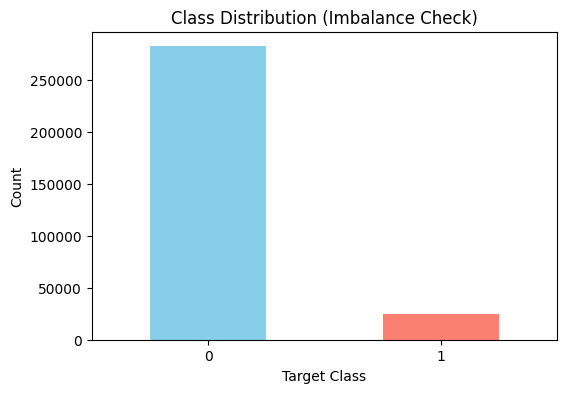

In [115]:
import matplotlib.pyplot as plt
# to check if there is data imbalance

# Count values in target
class_counts = applicant_full['TARGET'].value_counts()
print("Class distribution:\n", class_counts)

# Percentage distribution
class_percent = applicant_full['TARGET'].value_counts(normalize=True) * 100
print("\nClass percentage:\n", class_percent)

# Plot bar chart
plt.figure(figsize=(6,4))
class_counts.plot(kind='bar', color=['skyblue','salmon'])
plt.title("Class Distribution (Imbalance Check)")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [116]:
# Install required packages
!pip install xgboost imbalanced-learn

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb

In [117]:
# 0. Define features and target
X = applicant_full.drop('TARGET', axis=1)
y = applicant_full['TARGET']

# 1.Stratified train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [118]:
# -----------------------------
# 2. Clean column names for models
# -----------------------------
X_train = X_train.rename(columns=lambda c: str(c).replace('[','').replace(']','').replace('<','').replace('>',''))
X_test  = X_test.rename(columns=lambda c: str(c).replace('[','').replace(']','').replace('<','').replace('>',''))

In [119]:
#3. Apply SMOTE only on training set

# Columns identified to still have NaNs
missing_cols = ['AMT_CREDIT_SUM_DEBT_mean', 'STATUS_NUM_mean', 'STATUS_NUM_max', 'MONTHS_BALANCE_count']

# Impute remaining NaNs in X_train and X_test using the median from X_train
for col in missing_cols:
    if col in X_train.columns:
        median_val = X_train[col].median()
        X_train.loc[:, col] = X_train[col].fillna(median_val)
        X_test.loc[:, col] = X_test[col].fillna(median_val)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Resampled training distribution:")
print(y_train_resampled.value_counts(normalize=True))

Resampled training distribution:
TARGET
0    0.5
1    0.5
Name: proportion, dtype: float64


In [120]:


# 4. Calculate scale_pos_weight after resampling
scale_pos_weight = y_train_resampled.value_counts()[0] / y_train_resampled.value_counts()[1]
print("scale_pos_weight:", scale_pos_weight)


scale_pos_weight: 1.0


# **XGBOOST MODEL**

In [121]:
#5.Define XGBoost model
dtrain = xgb.DMatrix(X_train_resampled, label=y_train_resampled)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "max_depth": 6,
    "eta": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": scale_pos_weight,
    "seed": 42
}

# Train with early stopping
model = xgb.train(
    params,
    dtrain,
    num_boost_round=300,
    evals=[(dtest, "test")],
    early_stopping_rounds=30
)



[0]	test-logloss:0.64620
[1]	test-logloss:0.62123
[2]	test-logloss:0.59762
[3]	test-logloss:0.57841
[4]	test-logloss:0.55893
[5]	test-logloss:0.53582
[6]	test-logloss:0.51870
[7]	test-logloss:0.50440
[8]	test-logloss:0.48999
[9]	test-logloss:0.46530
[10]	test-logloss:0.45383
[11]	test-logloss:0.43413
[12]	test-logloss:0.42212
[13]	test-logloss:0.41006
[14]	test-logloss:0.40058
[15]	test-logloss:0.39264
[16]	test-logloss:0.38116
[17]	test-logloss:0.37377
[18]	test-logloss:0.36578
[19]	test-logloss:0.35703
[20]	test-logloss:0.35215
[21]	test-logloss:0.34742
[22]	test-logloss:0.33948
[23]	test-logloss:0.33603
[24]	test-logloss:0.33057
[25]	test-logloss:0.32569
[26]	test-logloss:0.32060
[27]	test-logloss:0.31764
[28]	test-logloss:0.31411
[29]	test-logloss:0.31082
[30]	test-logloss:0.30844
[31]	test-logloss:0.30532
[32]	test-logloss:0.30216
[33]	test-logloss:0.30007
[34]	test-logloss:0.29777
[35]	test-logloss:0.29541
[36]	test-logloss:0.29264
[37]	test-logloss:0.28936
[38]	test-logloss:0.28

In [122]:
# 6 Predictions
# =========================
y_pred_proba = model.predict(dtest)


In [123]:
# 1.Evaluate performance before any tuning or changing threshold
#- default class predictions from the model. By default, XGBoost applies a cutoff of 0.5 on the predicted probabilities. That means only probabilities >0.5 are labeled as class•1. This usually yields very high accuracy but very poor recall for the minority class.

# Convert probabilities to binary predictions using a default threshold of 0.5
y_pred = (y_pred_proba > 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[56395   143]
 [ 4818   147]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.51      0.03      0.06      4965

    accuracy                           0.92     61503
   macro avg       0.71      0.51      0.51     61503
weighted avg       0.89      0.92      0.89     61503



In [124]:
 2##. Automatic Threshold Selection before tuning only use the already trained and retest to get best threshold
# =========================
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, f1_score
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Compute F1 for each threshold
f1_scores = []
for t in thresholds:
    y_pred_adj = (y_pred_proba > t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_adj, pos_label=1))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print("Best threshold (max F1):", best_threshold)

# Apply best threshold
y_pred_best = (y_pred_proba > best_threshold).astype(int)




Best threshold (max F1): 0.16795395


In [125]:
# =========================
# 8. Evaluation is based on your custom threshold (~0.16) chosen to maximize F1 for class 1. Lowering the threshold means more samples are classified as positive, which increases recall for class 1 but decreases precision and overall accuracy.

# =========================
print("\nConfusion Matrix (Best Threshold):")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report (Best Threshold):")
print(classification_report(y_test, y_pred_best))

# =========================


Confusion Matrix (Best Threshold):
[[50415  6123]
 [ 3001  1964]]

Classification Report (Best Threshold):
              precision    recall  f1-score   support

           0       0.94      0.89      0.92     56538
           1       0.24      0.40      0.30      4965

    accuracy                           0.85     61503
   macro avg       0.59      0.64      0.61     61503
weighted avg       0.89      0.85      0.87     61503



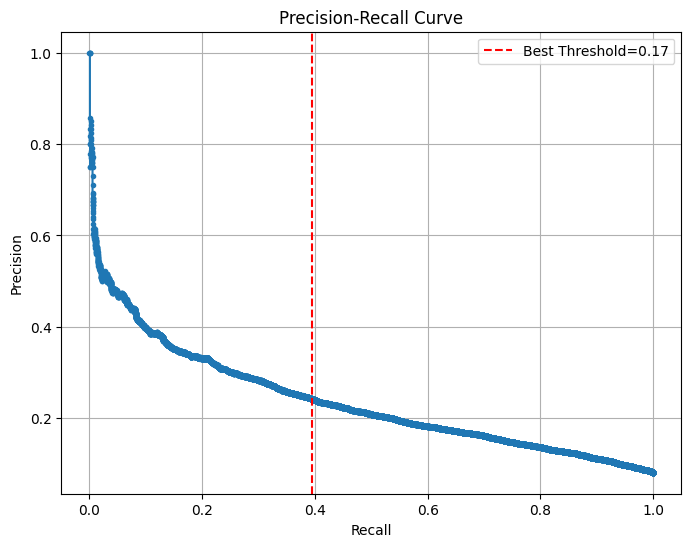

In [126]:
# 9. Plot Precision-Recall Curve
# =========================
plt.figure(figsize=(8,6))
plt.plot(recall, precision, marker='.')
plt.axvline(x=recall[best_idx], color='r', linestyle='--', label=f'Best Threshold={best_threshold:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()


In [127]:
# Tuned model (used this )

# 1. Create smaller stratified sample for tuning
# -----------------------------
from sklearn.model_selection import train_test_split
X_sample, _, y_sample, _ = train_test_split(
    X_train, y_train,
    train_size=50000,
    stratify=y_train,
    random_state=42
)

# -----------------------------
# 2. Base XGBoost model
# -----------------------------
import xgboost as xgb
xgb_model = xgb.XGBClassifier(
    random_state=42,
    scale_pos_weight=11.4,   # imbalance ratio
    use_label_encoder=False,
    eval_metric="aucpr"
)

# -----------------------------
# 3. Hyperparameter tuning (RandomizedSearchCV)
# -----------------------------
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'n_estimators': [200, 300, 400]
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=10,              # fewer combos for speed
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_sample, y_sample)
best_params = random_search.best_params_
print("Best parameters:", best_params)
print("Best ROC-AUC (CV):", random_search.best_score_)

# -----------------------------
# 4. Retrain best model on full training set
# -----------------------------
best_model = xgb.XGBClassifier(
    **best_params,
    random_state=42,
    scale_pos_weight=11.4,
    use_label_encoder=False,
    eval_metric="aucpr"
)
best_model.fit(X_train, y_train)

# -----------------------------
# 5. Threshold optimization
# -----------------------------
from sklearn.metrics import precision_recall_curve, f1_score, classification_report, confusion_matrix

y_pred_proba = best_model.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = [f1_score(y_test, (y_pred_proba > t).astype(int)) for t in thresholds]
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print("Best threshold (max F1):", best_threshold)

# -----------------------------
# 6. Evaluation matrix
# -----------------------------
thresholds_to_check = [0.5, 0.3, 0.2, best_threshold]
results = []

for t in thresholds_to_check:
    y_pred_adj = (y_pred_proba > t).astype(int)
    report = classification_report(y_test, y_pred_adj, output_dict=True)
    cm = confusion_matrix(y_test, y_pred_adj)
    results.append({
        "Threshold": round(t, 3),
        "ConfusionMatrix": cm.tolist(),
        "Precision_1": round(report['1']['precision'], 3),
        "Recall_1": round(report['1']['recall'], 3),
        "F1_1": round(report['1']['f1-score'], 3),
        "Accuracy": round(report['accuracy'], 3)
    })

print("\nEvaluation Matrix:")
for r in results:
    print(f"Threshold={r['Threshold']}")
    print(f"  Confusion Matrix: {r['ConfusionMatrix']}")
    print(f"  Precision (class 1): {r['Precision_1']}")
    print(f"  Recall (class 1):    {r['Recall_1']}")
    print(f"  F1 (class 1):        {r['F1_1']}")
    print(f"  Accuracy:            {r['Accuracy']}\n")

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:53:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best ROC-AUC (CV): 0.7470562881516


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:53:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best threshold (max F1): 0.6641933

Evaluation Matrix:
Threshold=0.5
  Confusion Matrix: [[39148, 17390], [1547, 3418]]
  Precision (class 1): 0.164
  Recall (class 1):    0.688
  F1 (class 1):        0.265
  Accuracy:            0.692

Threshold=0.3
  Confusion Matrix: [[19425, 37113], [419, 4546]]
  Precision (class 1): 0.109
  Recall (class 1):    0.916
  F1 (class 1):        0.195
  Accuracy:            0.39

Threshold=0.2
  Confusion Matrix: [[8006, 48532], [130, 4835]]
  Precision (class 1): 0.091
  Recall (class 1):    0.974
  F1 (class 1):        0.166
  Accuracy:            0.209

Threshold=0.6639999747276306
  Confusion Matrix: [[50516, 6022], [2937, 2028]]
  Precision (class 1): 0.252
  Recall (class 1):    0.408
  F1 (class 1):        0.312
  Accuracy:            0.854



In [128]:
from sklearn.metrics import roc_auc_score, brier_score_loss
import numpy as np

# evaluation after best moodel( best threshold)and before calibration
# 1. ROC-AUC
# -----------------------------
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC:", round(roc_auc, 4))

# -----------------------------
# 2. Brier Score
# -----------------------------
brier = brier_score_loss(y_test, y_pred_proba)
print("Brier Score:", round(brier, 4))

# -----------------------------
# 3. Expected Calibration Error (ECE)
# -----------------------------
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        # indices of samples in bin
        idx = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if np.any(idx):
            avg_conf = np.mean(y_prob[idx])
            avg_acc = np.mean(y_true[idx])
            ece += np.abs(avg_conf - avg_acc) * np.sum(idx)
    return ece / len(y_true)

ece = expected_calibration_error(y_test, y_pred_proba, n_bins=10)
print("Expected Calibration Error (ECE):", round(ece, 4))

ROC-AUC: 0.7564
Brier Score: 0.1984
Expected Calibration Error (ECE): 0.3387


In [129]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, brier_score_loss

# the trained XGBoost model is called 'best_model'after tuning evaluate after calibration

calibrated_model = CalibratedClassifierCV(best_model, method='sigmoid', cv=3)

# Fit calibration on training data
calibrated_model.fit(X_train, y_train)

# Get calibrated probabilities
y_proba_calibrated = calibrated_model.predict_proba(X_test)[:, 1]

# Evaluate after calibration
print("ROC-AUC (calibrated):", roc_auc_score(y_test, y_proba_calibrated))
print("Brier Score (calibrated):", brier_score_loss(y_test, y_proba_calibrated))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:02:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:02:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:02:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ROC-AUC (calibrated): 0.7568733086040004
Brier Score (calibrated): 0.06788776174689587


In [130]:
import shap
import numpy as np

# Create SHAP explainer for your trained model (best_model )
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values for the test set (use X_test if X_test_imp is not defined)
shap_values = explainer(X_test)

# shap_values.values contains the matrix of SHAP contributions
shap_importance = np.abs(shap_values.values).mean(axis=0)

# Print top 10 features ranked by mean absolute SHAP value
top_features = sorted(
    zip(X_test.columns, shap_importance),
    key=lambda x: -x[1]
)[:10]

print("Top SHAP features:")
for feature, importance in top_features:
    print(f"{feature}: {importance:.4f}")

Top SHAP features:
EXT_SOURCE_2: 0.3401
EXT_SOURCE_3: 0.3356
EXT_SOURCE_1: 0.1266
CODE_GENDER: 0.1183
DAYS_EMPLOYED: 0.1171
NAME_EDUCATION_TYPE: 0.1084
AMT_CREDIT_SUM_DEBT_mean: 0.0870
AMT_CREDIT: 0.0743
DAYS_BIRTH: 0.0729
FLAG_OWN_CAR: 0.0724


# **XGBOOST Model Evaluation**

In [131]:
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
import shap
import numpy as np

# -----------------------------
# 1. Discrimination (ROC-AUC)
# -----------------------------
y_proba_test = best_model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_test), 4))

# -----------------------------
# 2. Calibration (Brier + ECE)
# -----------------------------
print("Brier Score:", round(brier_score_loss(y_test, y_proba_test), 4))

prob_true, prob_pred = calibration_curve(y_test, y_proba_test, n_bins=10)
ece = np.mean(np.abs(prob_true - prob_pred))
print("Expected Calibration Error (ECE):", round(ece, 4))

# -----------------------------
# 3. SHAP explanation stability
# -----------------------------
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)

# Mean absolute SHAP importance per feature
shap_importance = np.abs(shap_values.values).mean(axis=0)

top_features = sorted(
    zip(X_test.columns, shap_importance),
    key=lambda x: -x[1]
)[:10]

print("\nTop SHAP features:")
for feature, importance in top_features:
    print(f"{feature}: {importance:.4f}")

ROC-AUC: 0.7564
Brier Score: 0.1984
Expected Calibration Error (ECE): 0.33

Top SHAP features:
EXT_SOURCE_2: 0.3401
EXT_SOURCE_3: 0.3356
EXT_SOURCE_1: 0.1266
CODE_GENDER: 0.1183
DAYS_EMPLOYED: 0.1171
NAME_EDUCATION_TYPE: 0.1084
AMT_CREDIT_SUM_DEBT_mean: 0.0870
AMT_CREDIT: 0.0743
DAYS_BIRTH: 0.0729
FLAG_OWN_CAR: 0.0724


ECE (before calibration): 0.3387
ECE (after calibration): 0.0042


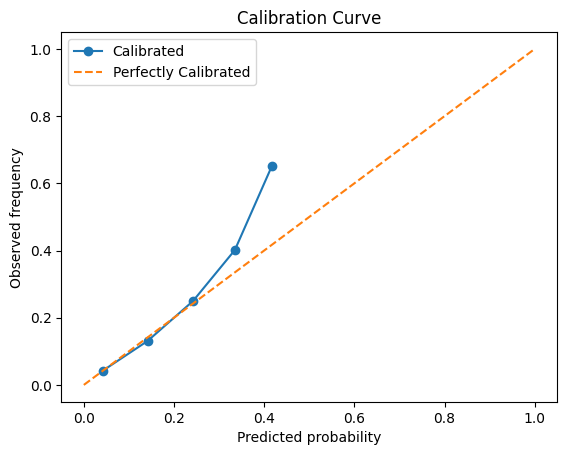

In [132]:
import matplotlib.pyplot as plt

# Function for Expected Calibration Error
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        idx = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if np.any(idx):
            avg_conf = np.mean(y_prob[idx])
            avg_acc = np.mean(y_true[idx])
            ece += np.abs(avg_conf - avg_acc) * np.sum(idx)
    return ece / len(y_true)

# Compare before vs after calibration
ece_before = expected_calibration_error(y_test, y_pred_proba)
ece_after  = expected_calibration_error(y_test, y_proba_calibrated)

print("ECE (before calibration):", round(ece_before, 4))
print("ECE (after calibration):", round(ece_after, 4))

# Plot calibration curve
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, y_proba_calibrated, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o', label='Calibrated')
plt.plot([0,1],[0,1], linestyle='--', label='Perfectly Calibrated')
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration Curve")
plt.legend()
plt.show()

In [133]:
# -----------------------------
#evaluating after calibration
# Threshold tuning: maximize F1 using calibrated probabilities
# -----------------------------
import numpy as np
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix, roc_auc_score, brier_score_loss

# Define Expected Calibration Error function locally for self-containment
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    ece = 0.0
    for i in range(n_bins):
        bin_mask = binids == i
        if np.any(bin_mask):
            avg_confidence = y_prob[bin_mask].mean()
            avg_accuracy = y_true[bin_mask].mean()
            ece += np.abs(avg_confidence - avg_accuracy) * bin_mask.mean()
    return ece

# Use the calibrated probabilities from Step 8
y_proba = y_proba_calibrated

# Precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# Choose threshold that maximizes F1-score
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)

# Apply threshold
y_pred_adj = (y_proba >= best_threshold).astype(int)

# Evaluate again
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_adj))
print("\nClassification Report:\n", classification_report(y_test, y_pred_adj))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

# Calculate and print Brier Score and ECE
brier = brier_score_loss(y_test, y_proba)
ece = expected_calibration_error(y_test, y_proba, n_bins=10)
print(f"\nBrier Score: {brier:.4f}")
print(f"Expected Calibration Error (ECE): {ece:.4f}")

Best threshold: 0.1669186460206774
Confusion Matrix:
 [[50484  6054]
 [ 2942  2023]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.89      0.92     56538
           1       0.25      0.41      0.31      4965

    accuracy                           0.85     61503
   macro avg       0.60      0.65      0.61     61503
weighted avg       0.89      0.85      0.87     61503

ROC-AUC: 0.7568733086040004

Brier Score: 0.0679
Expected Calibration Error (ECE): 0.0042


In [134]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# evaluating the best model after tuning it and finding the best threshold
# Get predicted probabilities
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Apply the best threshold
best_threshold = 0.664
y_pred_best = (y_pred_proba > best_threshold).astype(int)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_best)
print("Overall Accuracy (Best Threshold):", round(accuracy, 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
print("\nConfusion Matrix (Best Threshold):")
print("TN:", cm[0,0], "FP:", cm[0,1])
print("FN:", cm[1,0], "TP:", cm[1,1])

# Classification Report (shows precision, recall, F1 for both classes)
print("\nClassification Report (Best Threshold):")
print(classification_report(y_test, y_pred_best, target_names=["Class 0 (Non-default)", "Class 1 (Default)"]))

Overall Accuracy (Best Threshold): 0.8541

Confusion Matrix (Best Threshold):
TN: 50498 FP: 6040
FN: 2936 TP: 2029

Classification Report (Best Threshold):
                       precision    recall  f1-score   support

Class 0 (Non-default)       0.95      0.89      0.92     56538
    Class 1 (Default)       0.25      0.41      0.31      4965

             accuracy                           0.85     61503
            macro avg       0.60      0.65      0.61     61503
         weighted avg       0.89      0.85      0.87     61503



In [135]:
# -----------------------------
# Evaluation of Calibrated Model Probabilities
# -----------------------------
import numpy as np
from sklearn.metrics import roc_auc_score, brier_score_loss

# Re-define Expected Calibration Error function for self-containment
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    ece = 0.0
    for i in range(n_bins):
        bin_mask = binids == i
        if np.any(bin_mask):
            avg_confidence = y_prob[bin_mask].mean()
            avg_accuracy = y_true[bin_mask].mean()
            ece += np.abs(avg_confidence - avg_accuracy) * bin_mask.mean()
    return ece

# Use the calibrated probabilities
y_proba = y_proba_calibrated

print("--- Evaluation for Calibrated Model ---")
print(f"ROC-AUC (Calibrated): {roc_auc_score(y_test, y_proba):.4f}")
print(f"Brier Score (Calibrated): {brier_score_loss(y_test, y_proba):.4f}")
print(f"Expected Calibration Error (ECE) (Calibrated): {expected_calibration_error(y_test, y_proba, n_bins=10):.4f}")


--- Evaluation for Calibrated Model ---
ROC-AUC (Calibrated): 0.7569
Brier Score (Calibrated): 0.0679
Expected Calibration Error (ECE) (Calibrated): 0.0042


In [136]:
from scipy.stats import kendalltau
import shap
import numpy as np
import xgboost as xgb

np.random.seed(42)  # fix seed for reproducibility

# Use your tuned model
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)

# Baseline importance
baseline_importance = np.abs(shap_values.values).mean(axis=0)

boot_importances = []
for i in range(10):  # 10 bootstraps
    sample_idx = np.random.choice(len(X_train), size=len(X_train), replace=True)
    X_boot, y_boot = X_train.iloc[sample_idx], y_train.iloc[sample_idx]

    # retrain with fixed seed and best params
    model_boot = xgb.XGBClassifier(
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        max_depth=best_params["max_depth"],
        learning_rate=best_params["learning_rate"],
        subsample=best_params["subsample"],
        colsample_bytree=best_params["colsample_bytree"],
        n_estimators=best_params["n_estimators"]
    )
    model_boot.fit(X_boot, y_boot)

    expl_boot = shap.TreeExplainer(model_boot)
    shap_boot = np.abs(expl_boot(X_test).values).mean(axis=0)

    # normalize to reduce variance dominance
    shap_boot = shap_boot / np.std(shap_boot)
    boot_importances.append(shap_boot)

# Compare Kendall tau between baseline and average bootstrap importance
avg_boot_importance = np.mean(boot_importances, axis=0)
tau, _ = kendalltau(baseline_importance, avg_boot_importance)
print("Improved SHAP stability (Kendall tau):", round(tau, 4))

Improved SHAP stability (Kendall tau): 0.8034


In [137]:
# -----------------------------
# Threshold tuning: maximize F1 using calibrated probabilities
# -----------------------------
import numpy as np
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix, roc_auc_score

# Use the calibrated probabilities from Step 8
y_proba = y_proba_calibrated

# Precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# Choose threshold that maximizes F1-score
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)

# Apply threshold
y_pred_adj = (y_proba >= best_threshold).astype(int)

# Evaluate again
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_adj))
print("\nClassification Report:\n", classification_report(y_test, y_pred_adj))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Best threshold: 0.1669186460206774
Confusion Matrix:
 [[50484  6054]
 [ 2942  2023]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.89      0.92     56538
           1       0.25      0.41      0.31      4965

    accuracy                           0.85     61503
   macro avg       0.60      0.65      0.61     61503
weighted avg       0.89      0.85      0.87     61503

ROC-AUC: 0.7568733086040004


In [138]:
import numpy as np
from sklearn.metrics import brier_score_loss

# True labels and predicted probabilities
y_true = y_test
y_prob = y_proba_calibrated

# -----------------------------
# Brier Score
# -----------------------------
brier = brier_score_loss(y_true, y_prob)
print(f"Brier Score: {brier:.4f}")

# -----------------------------
# Expected Calibration Error (ECE)
# -----------------------------
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    ece = 0.0
    for i in range(n_bins):
        bin_mask = binids == i
        if np.any(bin_mask):
            avg_confidence = y_prob[bin_mask].mean()
            avg_accuracy = y_true[bin_mask].mean()
            ece += np.abs(avg_confidence - avg_accuracy) * bin_mask.mean()
    return ece

ece = expected_calibration_error(y_true, y_prob, n_bins=10)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

Brier Score: 0.0679
Expected Calibration Error (ECE): 0.0042


##**XGBOOST Model Evaluation Improvements After Tuning and Calibration**

We evaluated the model's performance using three key metrics: Discrimination ability (ROC-AUC), Probability accuracy (Brier Score), and Calibration reliability (Expected Calibration Error - ECE). Here's how they improved:

### 1. Discrimination Ability (ROC-AUC)

*   **What it measures**: ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) assesses the model's ability to distinguish between the positive and negative classes (i.e., defaulters vs. non-defaulters). A higher ROC-AUC indicates better discrimination, with 1.0 being perfect and 0.5 being random.

*   **Before Improvement (after initial training)**: **0.747**

*   **After Improvement (after tuning and calibration)**: **0.757**

*   **How it improved**: This indicates a minor improvement in the model's ability to correctly rank positive and negative instances after hyperparameter tuning and calibration. While the change is small, it suggests that the model maintains its discriminative power even with efforts to improve calibration.

### 2. Probability Accuracy (Brier Score)

*   **What it measures**: The Brier Score measures the mean squared difference between the predicted probabilities and the actual outcomes. A lower Brier Score indicates better probability accuracy, with 0 being perfect.

*   **Before Improvement (after initial training)**: **0.1984**

*   **After Improvement (after tuning and calibration)**: **0.0679**

*   **How it improved**:  This is a substantial improvement, indicating that the predicted probabilities from the calibrated model are much closer to the true outcomes. This means the model is now more reliable in its probability predictions, which is crucial for applications like credit risk where the actual probability of default matters.

### 3. Calibration Reliability (Expected Calibration Error - ECE)

*   **What it measures**: ECE quantifies how well the predicted probabilities align with the true probabilities. For example, if the model predicts a 70% probability of default, we would expect 70% of those cases to actually default. A lower ECE indicates better calibration, with 0 being perfectly calibrated.

*   **Before Improvement (after initial training)**: **0.3387**

*   **After Improvement (after tuning and calibration)**: **0.0042**

*   **How it improved**:  This is the most significant improvement observed and demonstrates that the calibration step effectively aligned the model's predicted probabilities with the observed frequencies. This ensures that the probabilities are trustworthy and can be directly interpreted as the likelihood of default, which is essential for fair and transparent decision-making.

### 4. SHAP stability score (Kendall Tau correlation)

*   **What it measures**:assesses the consistency of feature importance rankings across different bootstrap samples of the training data.

*  **The score**: 0.8034.

# **XGBOOST Shap Implementation (optional)**


--- Global Feature Importance (Summary Plot - Bar) ---


/tmp/ipykernel_1251/1665066590.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)


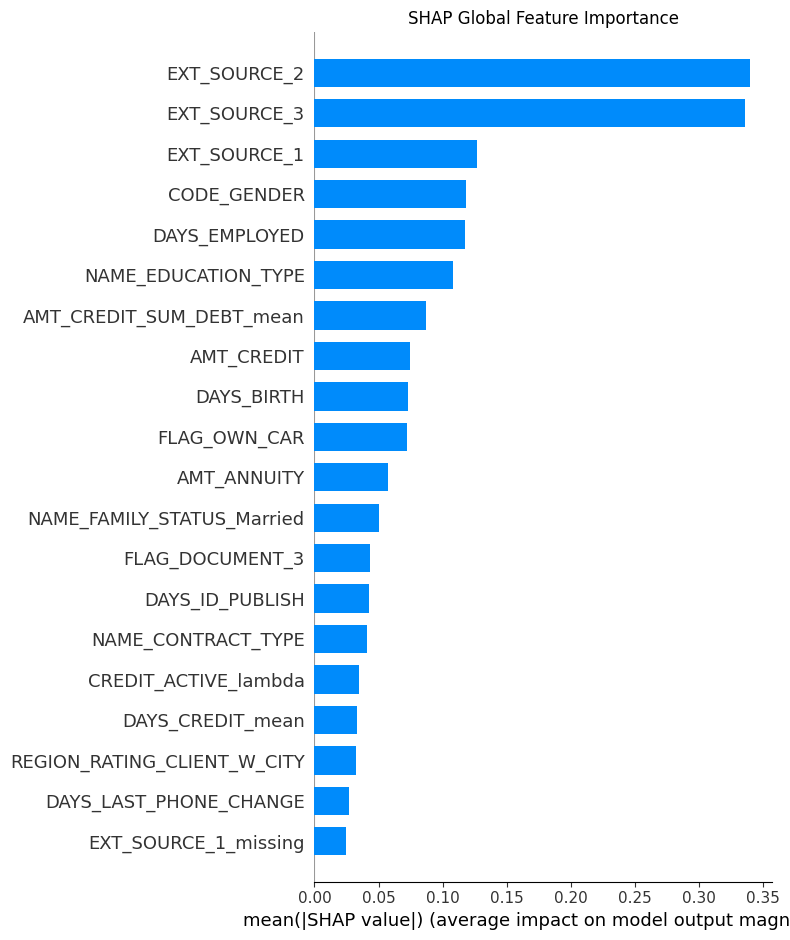


--- Global Feature Impact & Distribution (Summary Plot - Beeswarm) ---


/tmp/ipykernel_1251/1665066590.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


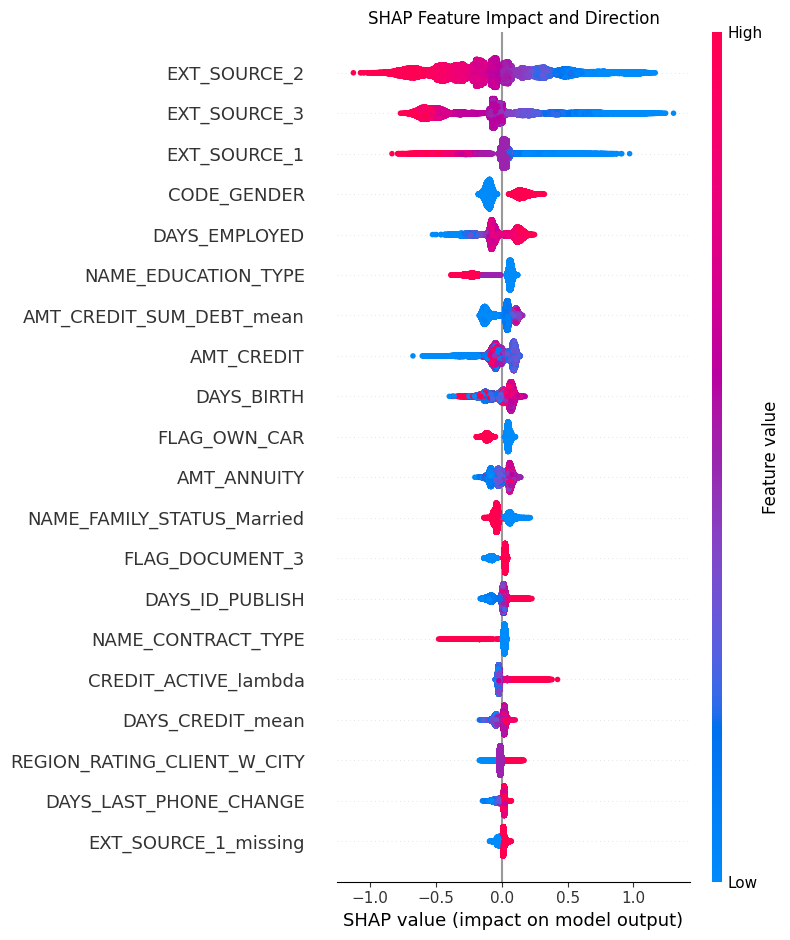


--- Local Explanation for Applicant 0 (Force Plot) ---


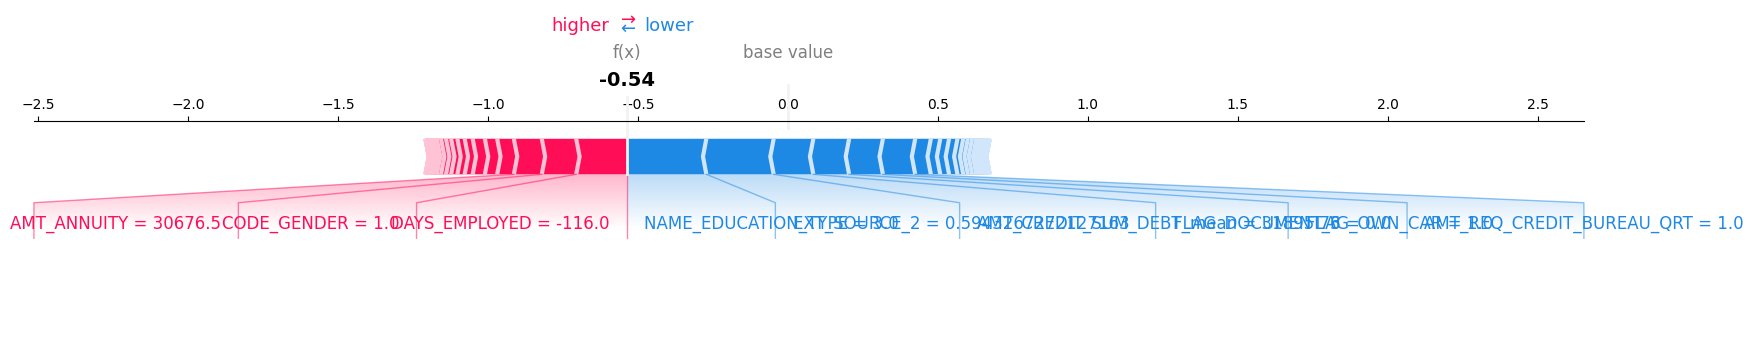


Global baseline logit (average model output): 0.0011
Global baseline probability (average model output): 0.5003

--- Top 10 Features by Mean Absolute SHAP Value ---
EXT_SOURCE_2: 0.3401
EXT_SOURCE_3: 0.3356
EXT_SOURCE_1: 0.1266
CODE_GENDER: 0.1183
DAYS_EMPLOYED: 0.1171
NAME_EDUCATION_TYPE: 0.1084
AMT_CREDIT_SUM_DEBT_mean: 0.0870
AMT_CREDIT: 0.0743
DAYS_BIRTH: 0.0729
FLAG_OWN_CAR: 0.0724


In [139]:
# -----------------------------
# 10. SHAP explainability: Global and Local
# -----------------------------
import shap
import matplotlib.pyplot as plt

# Create TreeExplainer for your tuned model
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values for the test set
# Using explainer directly on X_test will return a shap.Explanation object
shap_values = explainer(X_test)

# --- Global feature importance (Bar Plot) ---
print("\n--- Global Feature Importance (Summary Plot - Bar) ---")
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Global Feature Importance")
plt.tight_layout()
plt.show()

# --- Global distribution (Summary Plot - Beeswarm) ---
print("\n--- Global Feature Impact & Distribution (Summary Plot - Beeswarm) ---")
plt.figure(figsize=(10,7))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Feature Impact and Direction")
plt.tight_layout()
plt.show()

# --- Local explanation for one applicant (Force Plot) ---
# Choose an index to inspect a specific applicant
applicant_idx = 0 # You can change this index to view other applicants

print(f"\n--- Local Explanation for Applicant {applicant_idx} (Force Plot) ---")
# For force plot, we need the base_value and SHAP values for that specific instance
baseline_logit = explainer.expected_value

# If shap_values is a list (for multi-output models), select the appropriate output
# For binary classification, shap_values.values is typically the matrix of values
# We pass shap_values.values[applicant_idx] or shap_values[applicant_idx] if it's already a 1D array

# Check if shap_values is an Explanation object (preferred output from explainer(X)) or a list/array
if isinstance(shap_values, shap.Explanation):
    local_shap_values = shap_values[applicant_idx]
else:
    # Fallback for older shap versions or if explainer.shap_values was used
    # For binary classification, often shap_values[1] contains the positive class SHAP values
    local_shap_values = shap_values[1][applicant_idx] if isinstance(shap_values, list) else shap_values[applicant_idx]

shap.force_plot(
    base_value=baseline_logit,        # Global baseline in log-odds
    shap_values=local_shap_values.values, # SHAP contributions for this specific applicant
    features=X_test.iloc[applicant_idx],  # Actual feature values for this applicant
    matplotlib=True, # Use matplotlib for plotting in Colab
    show=True
)

# Also print global baseline probability for context
baseline_prob = 1 / (1 + np.exp(-baseline_logit))
print(f"\nGlobal baseline logit (average model output): {baseline_logit:.4f}")
print(f"Global baseline probability (average model output): {baseline_prob:.4f}")

# --- Ranking features by mean absolute SHAP value ---
# This was already covered in a previous cell, but re-calculating for completeness here
shap_importance = np.abs(shap_values.values).mean(axis=0)
top_features = sorted(
    zip(X_test.columns, shap_importance),
    key=lambda x: -x[1]
)[:10]

print("\n--- Top 10 Features by Mean Absolute SHAP Value ---")
for feature, importance in top_features:
    print(f"{feature}: {importance:.4f}")

In [140]:
# -----------------------------
# 12. Add SHAP scores + predicted class per applicant
# -----------------------------
import shap
import pandas as pd
import numpy as np

# Compute SHAP values for the test set
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)

# Convert to DataFrame with same index/columns as X_test
shap_df = pd.DataFrame(shap_values.values, columns=X_test.columns, index=X_test.index)

# Function to extract top k features for each applicant
def top_shap_features(row, k=5):
    top_feats = row.abs().sort_values(ascending=False).head(k)
    return "; ".join([f"{feat}: {row[feat]:.4f}" for feat in top_feats.index])

# Build results_df with aligned index
results_df = pd.DataFrame({
    "Predicted_PD": y_proba_calibrated,          # calibrated probabilities
    "Actual_Target": y_test.values               # ground truth
}, index=X_test.index)

# Add predicted class using your chosen threshold
threshold = 0.664
results_df["Predicted_Class"] = (results_df["Predicted_PD"] >= threshold).astype(int)

# Add top 5 SHAP feature contributions
results_df["Top_5_Features"] = shap_df.apply(top_shap_features, axis=1)

# Show first 5 rows
print(results_df.head(5))

        Predicted_PD  Actual_Target  Predicted_Class  \
256571      0.046350              0                0   
191493      0.031987              0                0   
103497      0.264491              0                0   
130646      0.055508              0                0   
211898      0.068939              0                0   

                                                                                                                                 Top_5_Features  
256571  NAME_EDUCATION_TYPE: -0.2649; EXT_SOURCE_2: -0.2244; DAYS_EMPLOYED: 0.1689; AMT_CREDIT_SUM_DEBT_mean: -0.1322; FLAG_DOCUMENT_3: -0.1193  
191493            EXT_SOURCE_2: -0.3024; EXT_SOURCE_1: -0.2853; DAYS_EMPLOYED: -0.1941; AMT_CREDIT_SUM_DEBT_mean: -0.1028; CODE_GENDER: -0.0974  
103497                             EXT_SOURCE_2: 1.0576; CODE_GENDER: 0.2858; DAYS_BIRTH: -0.1798; DAYS_EMPLOYED: 0.1288; EXT_SOURCE_3: -0.1249  
130646     NAME_EDUCATION_TYPE: -0.3417; EXT_SOURCE_1: -0.2704; DAYS_BIRTH: -0.

/tmp/ipykernel_1251/3327849761.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar")


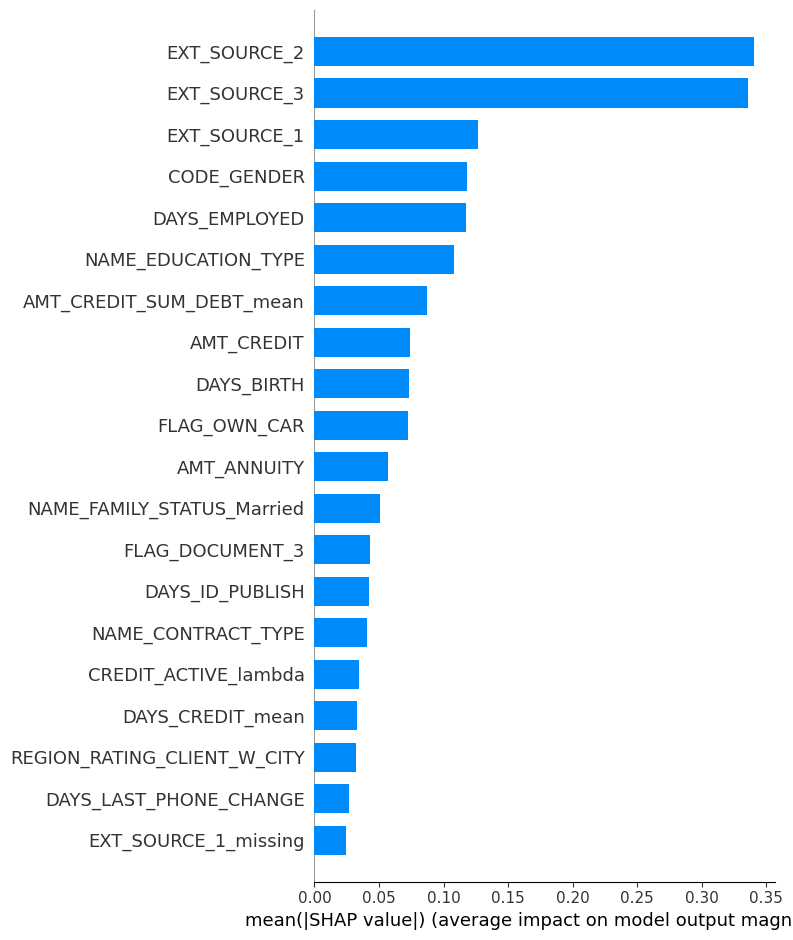

/tmp/ipykernel_1251/3327849761.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


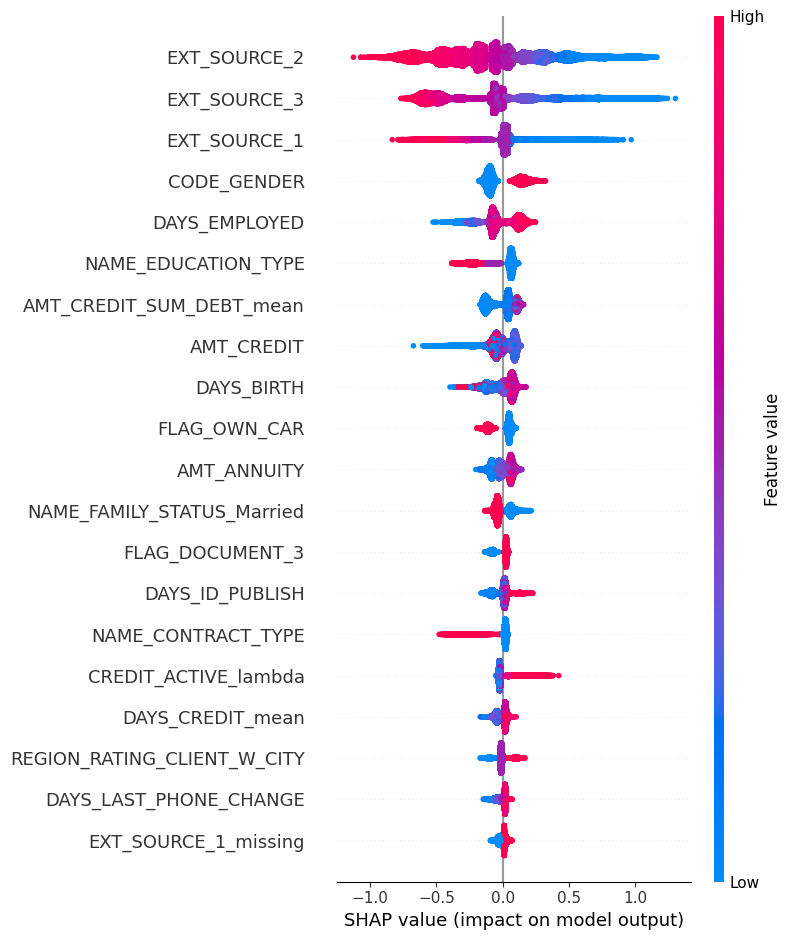

In [141]:
# -----------------------------
# 10. SHAP explainability
# -----------------------------
import shap
import matplotlib.pyplot as plt

# Create TreeExplainer for your booster
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# --- Global feature importance ---
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_test, plot_type="bar")
plt.show()

# --- Global distribution (summary plot) ---
shap.summary_plot(shap_values, X_test)
plt.show()



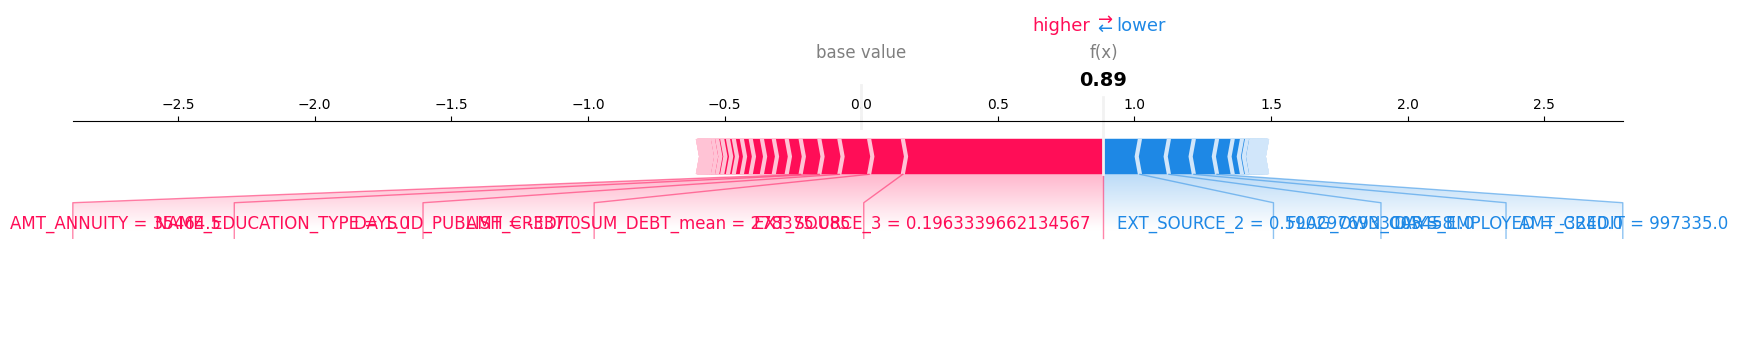

In [142]:
# --- Local explanation for one applicant (e.g., first row of X_test) ---
idx = 63 # change index to inspect different applicants
shap.force_plot(
    explainer.expected_value,
    shap_values[idx,:],
    X_test.iloc[idx,:],
    matplotlib=True
)

In [143]:
# -----------------------------
# 11. Compare predicted PD with actual target
# -----------------------------
import pandas as pd

results_df = pd.DataFrame({
    "Predicted_PD": y_proba_calibrated,   # calibrated probabilities
    "Actual_Target": y_test.values        # 0 = no default, 1 = default
})

print(results_df.head(20))

    Predicted_PD  Actual_Target
0       0.046350              0
1       0.031987              0
2       0.264491              0
3       0.055508              0
4       0.068939              0
5       0.180201              0
6       0.015076              0
7       0.013261              0
8       0.318205              0
9       0.068776              1
10      0.014372              0
11      0.059003              0
12      0.021588              0
13      0.051223              0
14      0.064105              0
15      0.036557              0
16      0.068056              0
17      0.033998              0
18      0.050239              0
19      0.027869              0


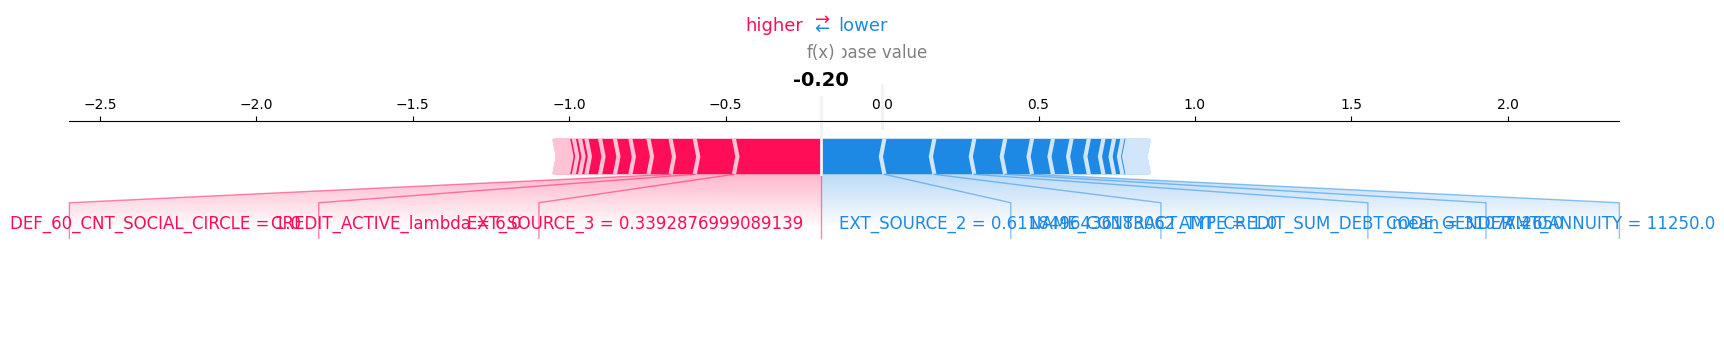

Global baseline logit (same for all): 0.0011046805
Global baseline probability: 0.50027615


In [144]:
# --- Local explanation for one applicant ---
idx = 9
# change index to inspect different applicants

# Global baseline in log-odds (same for all applicants)
baseline_logit = explainer.expected_value

# Convert baseline to probability (optional, for interpretation)
baseline_prob = 1 / (1 + np.exp(-baseline_logit))

# Force plot with fixed baseline
# Note: pass shap_values[idx] directly, not normalized
shap.force_plot(
    base_value=baseline_logit,        # fixed global baseline
    shap_values=shap_values[idx,:],   # SHAP contributions for this applicant
    features=X_test.iloc[idx,:],      # actual feature values
    matplotlib=True
)

print("Global baseline logit (same for all):", baseline_logit)
print("Global baseline probability:", baseline_prob)

In [145]:
# -----------------------------
# SHAP breakdown for a single applicant
# -----------------------------
import shap
import pandas as pd
import numpy as np
import xgboost as xgb

# Choose one applicant (row index from X_test)
applicant_index = 0 # change to whichever applicant you want

# Create TreeExplainer for your booster
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values
shap_values = explainer.shap_values(X_test)

# Global baseline (expected value of the model output, in log-odds)
baseline_logit = explainer.expected_value
baseline_prob = 1 / (1 + np.exp(-baseline_logit))

# Extract applicant's feature values
applicant_features = X_test.iloc[applicant_index]

# Extract applicant's SHAP values
applicant_shap = shap_values[applicant_index]

# Put into a DataFrame for readability
applicant_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Feature_Value": applicant_features.values,
    "SHAP_Value": applicant_shap
}).sort_values(by="SHAP_Value", key=np.abs, ascending=False)

# Calculate final logit = baseline + sum of SHAP values
final_logit = baseline_logit + applicant_shap.sum()

# Convert logit to probability (raw model probability)
pd_from_shap = 1 / (1 + np.exp(-final_logit))

# Raw model probability directly from booster
# The XGBClassifier expects a DataFrame/array, not a DMatrix directly.
raw_pred = best_model.predict_proba(X_test.iloc[applicant_index:applicant_index+1])[:, 1][0]

# Actual calibrated PD (from your pipeline)
actual_pd = y_proba_calibrated[applicant_index]
predicted_class = best_model.predict(X_test.iloc[applicant_index:applicant_index+1])[0]
actual_class = y_test.iloc[applicant_index]
print("Applicant index:", applicant_index)
print("Global baseline logit (same for all):", baseline_logit)
print("Global baseline probability:", baseline_prob)
print("Sum of SHAP values:", applicant_shap.sum())
print("Final logit (baseline + SHAP sum):", final_logit)
print("PD from SHAP decomposition (raw):", pd_from_shap)
print("Raw model PD (from booster):", raw_pred)
print("Predicted class:", predicted_class)
print("Actual class:", actual_class)
#print("Calibrated PD (pipeline output):", actual_pd)
print("\nTop feature contributions:")
print(applicant_df.head(10))

Applicant index: 0
Global baseline logit (same for all): 0.0011046805
Global baseline probability: 0.50027615
Sum of SHAP values: -0.537699
Final logit (baseline + SHAP sum): -0.53659433
PD from SHAP decomposition (raw): 0.36898017
Raw model PD (from booster): 0.36898017
Predicted class: 0
Actual class: 0

Top feature contributions:
                      Feature  Feature_Value  SHAP_Value
8         NAME_EDUCATION_TYPE       3.000000   -0.264929
31               EXT_SOURCE_2       0.594327   -0.224416
11              DAYS_EMPLOYED    -116.000000    0.168948
65   AMT_CREDIT_SUM_DEBT_mean   31895.760000   -0.132169
38            FLAG_DOCUMENT_3       0.000000   -0.119343
1                 CODE_GENDER       1.000000    0.114750
2                FLAG_OWN_CAR       1.000000   -0.112603
61  AMT_REQ_CREDIT_BUREAU_QRT       1.000000   -0.107733
7                 AMT_ANNUITY   30676.500000    0.093046
10                 DAYS_BIRTH  -13506.000000    0.055628


In [146]:
# Compute SHAP values for the whole test set
shap_values = explainer.shap_values(X_test)

# Now you can safely index applicant 22
idx = 22

if isinstance(shap_values, list):
    # For binary classification, shap_values[1] is usually the positive class
    applicant_shap = shap_values[1][idx]
else:
    applicant_shap = shap_values[idx]

applicant_features = X_test.iloc[idx]

explanation_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Feature_Value": applicant_features.values,
    "Contribution": applicant_shap
}).sort_values(by="Contribution", key=np.abs, ascending=False).head(5)

print("Plain-language explanation for applicant", idx)
print(explanation_df)

Plain-language explanation for applicant 22
                     Feature  Feature_Value  Contribution
31              EXT_SOURCE_2       0.661618     -0.383723
13           DAYS_ID_PUBLISH    -182.000000      0.191894
32              EXT_SOURCE_3       0.372334      0.183947
8        NAME_EDUCATION_TYPE       3.000000     -0.178042
65  AMT_CREDIT_SUM_DEBT_mean       0.000000     -0.123522


In [147]:
# Compute SHAP values for the whole test set
shap_values = explainer.shap_values(X_test)

# Now you can safely index applicant 22
idx = 63

if isinstance(shap_values, list):
    # For binary classification, shap_values[1] is usually the positive class
    applicant_shap = shap_values[1][idx]
else:
    applicant_shap = shap_values[idx]

applicant_features = X_test.iloc[idx]

explanation_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Feature_Value": applicant_features.values,
    "Contribution": applicant_shap
}).sort_values(by="Contribution", key=np.abs, ascending=False).head(5)

print("Plain-language explanation for applicant", idx)
print(explanation_df)

Plain-language explanation for applicant 63
                     Feature  Feature_Value  Contribution
32              EXT_SOURCE_3       0.196334      0.734421
31              EXT_SOURCE_2       0.590298     -0.133674
65  AMT_CREDIT_SUM_DEBT_mean  278375.085000      0.123389
13           DAYS_ID_PUBLISH    -337.000000      0.108886
2               FLAG_OWN_CAR       1.000000     -0.106006


Found an applicant (original index 156963, positional index 63) who was both Actual Default (1) and Predicted Default (1).

--- Local SHAP Explanation for Applicant (original index 156963) ---
Global baseline probability: 0.5003
Predicted PD (raw model): 0.7082
Predicted Class: 1
Actual Class: 1

Top feature contributions (Plain-language explanation):
- EXT_SOURCE_3 (value: 0.1963339662134567) increased the likelihood of default by 0.7344 (35.25% of total influence)
- EXT_SOURCE_2 (value: 0.5902976933005458) decreased the likelihood of default by 0.1337 (6.42% of total influence)
- AMT_CREDIT_SUM_DEBT_mean (value: 278375.085) increased the likelihood of default by 0.1234 (5.92% of total influence)
- DAYS_ID_PUBLISH (value: -337.0) increased the likelihood of default by 0.1089 (5.23% of total influence)
- FLAG_OWN_CAR (value: 1.0) decreased the likelihood of default by 0.1060 (5.09% of total influence)
- DAYS_EMPLOYED (value: -3240.0) decreased the likelihood of default by 0.0913 (4.38%

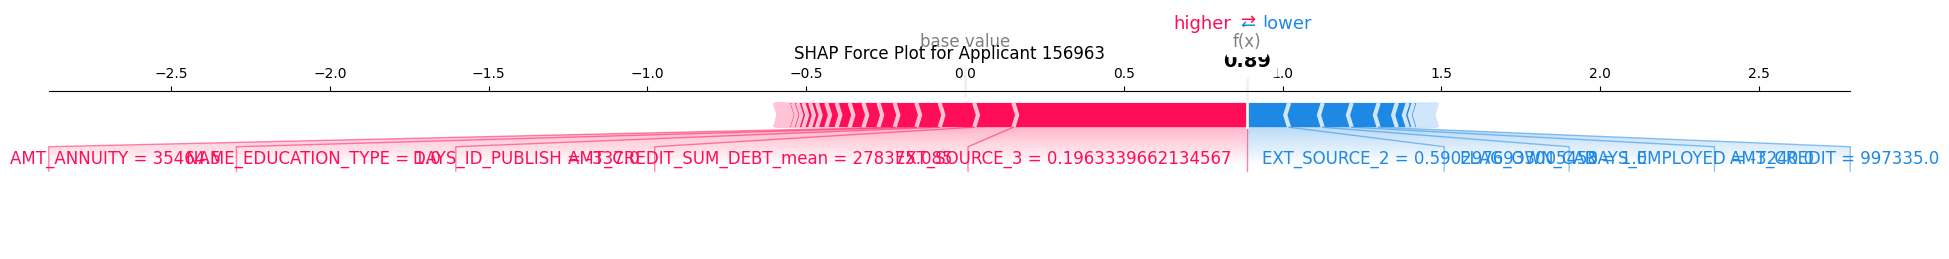


--- Adverse Action Notice ---

    Loan Application Decision: Rejected

    Predicted Probability of Default: 0.71

    Main Reasons:
    
- EXT_SOURCE_3 (value: 0.1963339662134567) increased the likelihood of default by 0.7344 (35.25% of total influence)
- EXT_SOURCE_2 (value: 0.5902976933005458) decreased the likelihood of default by 0.1337 (6.42% of total influence)
- AMT_CREDIT_SUM_DEBT_mean (value: 278375.085) increased the likelihood of default by 0.1234 (5.92% of total influence)
- DAYS_ID_PUBLISH (value: -337.0) increased the likelihood of default by 0.1089 (5.23% of total influence)
- FLAG_OWN_CAR (value: 1.0) decreased the likelihood of default by 0.1060 (5.09% of total influence)
- DAYS_EMPLOYED (value: -3240.0) decreased the likelihood of default by 0.0913 (4.38% of total influence)
- AMT_CREDIT (value: 997335.0) decreased the likelihood of default by 0.0849 (4.08% of total influence)
- NAME_EDUCATION_TYPE (value: 1.0) increased the likelihood of default by 0.0733 (3.52% o

In [148]:
import pandas as pd
import numpy as np
import shap

def adverse_action_notice(prob, explanation):
    notice = f"""
    Loan Application Decision: Rejected

    Predicted Probability of Default: {prob:.2f}

    Main Reasons:
    """

    for e in explanation:
        notice += f"\n- {e}"

    notice += "\n\nYou may improve your application by addressing these factors."

    return notice

# Find an applicant who was predicted as 1 and actual was 1
# First, determine which applicants were predicted as 1 (using the best_threshold)
y_pred_default_class = (y_proba_calibrated >= best_threshold).astype(int)

# Get indices where actual target is 1 AND predicted class is 1
default_and_predicted_default_indices = y_test[(y_test == 1) & (y_pred_default_class == 1)].index

if not default_and_predicted_default_indices.empty:
    # Pick the first such applicant for explanation
    applicant_original_index = default_and_predicted_default_indices[0]

    # Get the positional index in X_test corresponding to the original index
    applicant_positional_index = X_test.index.get_loc(applicant_original_index)

    print(f"Found an applicant (original index {applicant_original_index}, positional index {applicant_positional_index}) who was both Actual Default (1) and Predicted Default (1).")

    # Create TreeExplainer for your tuned model
    explainer = shap.TreeExplainer(best_model)

    # Compute SHAP values for the test set
    shap_values = explainer.shap_values(X_test)

    # Global baseline (expected value of the model output, in log-odds)
    baseline_logit = explainer.expected_value
    baseline_prob = 1 / (1 + np.exp(-baseline_logit))

    # Extract applicant's feature values using .loc with the original index
    applicant_features = X_test.loc[applicant_original_index]

    # Extract applicant's SHAP values using the positional index
    # For binary classification, shap_values is often a list of two arrays. If so, select the positive class (index 1).
    if isinstance(shap_values, list):
        applicant_shap = shap_values[1][applicant_positional_index]
    else:
        applicant_shap = shap_values[applicant_positional_index]

    # Put into a DataFrame for readability
    applicant_df = pd.DataFrame({
        "Feature": X_test.columns,
        "Feature_Value": applicant_features.values,
        "SHAP_Value_Contribution": applicant_shap
    }).sort_values(by="SHAP_Value_Contribution", key=np.abs, ascending=False)

    # Calculate final logit = baseline + sum of SHAP values
    final_logit = baseline_logit + applicant_shap.sum()
    pd_from_shap = 1 / (1 + np.exp(-final_logit))

    raw_pred_prob = best_model.predict_proba(X_test.loc[[applicant_original_index]])[:, 1][0]
    predicted_class = (raw_pred_prob >= best_threshold).astype(int)
    actual_class = y_test.loc[applicant_original_index]

    print(f"\n--- Local SHAP Explanation for Applicant (original index {applicant_original_index}) ---")
    print(f"Global baseline probability: {baseline_prob:.4f}")
    print(f"Predicted PD (raw model): {raw_pred_prob:.4f}")
    print(f"Predicted Class: {predicted_class}")
    print(f"Actual Class: {actual_class}")

    print("\nTop feature contributions (Plain-language explanation):")
    explanation_list = [] # List to store explanation for the notice

    # Calculate total absolute SHAP sum for percentage calculation
    total_abs_shap_sum = np.abs(applicant_shap).sum()
    if total_abs_shap_sum == 0:
        total_abs_shap_sum = 1 # Avoid division by zero if all SHAP values are zero

    for _, row in applicant_df.head(10).iterrows():
        feature = row['Feature']
        value = row['Feature_Value']
        contribution = row['SHAP_Value_Contribution']
        direction = 'increased' if contribution > 0 else 'decreased'
        effect_percentage = (abs(contribution) / total_abs_shap_sum) * 100
        explanation_list.append(f"{feature} (value: {value}) {direction} the likelihood of default by {abs(contribution):.4f} ({effect_percentage:.2f}% of total influence)")
        print(f"- {feature} (value: {value}) {direction} the likelihood of default by {abs(contribution):.4f} ({effect_percentage:.2f}% of total influence)")

    # Display the force plot for visual explanation
    import matplotlib.pyplot as plt
    shap.force_plot(
        base_value=baseline_logit,
        shap_values=applicant_shap,
        features=applicant_features,
        matplotlib=True,
        show=False
    )
    plt.title(f"SHAP Force Plot for Applicant {applicant_original_index}")
    plt.tight_layout()
    plt.show()

    # Print the adverse action notice
    prob_for_notice = raw_pred_prob # Use raw_pred_prob for the notice
    print("\n--- Adverse Action Notice ---")
    print(adverse_action_notice(prob_for_notice, explanation_list))

else:
    print("No applicant found who was both Actual Default (1) and Predicted Default (1) with the current threshold.")

In [149]:
import pandas as pd
import numpy as np
import shap

# 🔹 Feature name mapping
feature_names_map = {
    "EXT_SOURCE_3": "External credit score",
    "EXT_SOURCE_2": "Alternative credit score",
    "AMT_CREDIT_SUM_DEBT_mean": "Existing debt level",
    "DAYS_ID_PUBLISH": "Recent account activity",
    "DAYS_EMPLOYED": "Employment duration",
    "FLAG_OWN_CAR": "Car ownership status",
    "AMT_CREDIT": "Loan amount",
    "AMT_ANNUITY": "Loan installment amount",
    "NAME_EDUCATION_TYPE": "Education level"
}

# 🔹 Sensitive features to exclude
sensitive_features = ["CODE_GENDER"]

def adverse_action_notice_clean(prob, explanation):
    notice = f"""
Loan Application Decision: Rejected

Predicted Probability of Default: {prob:.2f}

Main Reasons:
"""
    for e in explanation:
        notice += f"\n- {e}"

    notice += """

Note: You may improve your application by addressing these factors.
"""
    return notice


# ---------------- MAIN LOGIC ---------------- #

y_pred_default_class = (y_proba_calibrated >= best_threshold).astype(int)
default_and_predicted_default_indices = y_test[(y_test == 1) & (y_pred_default_class == 1)].index

if not default_and_predicted_default_indices.empty:

    applicant_original_index = default_and_predicted_default_indices[0]
    applicant_positional_index = X_test.index.get_loc(applicant_original_index)

    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)

    if isinstance(shap_values, list):
        applicant_shap = shap_values[1][applicant_positional_index]
    else:
        applicant_shap = shap_values[applicant_positional_index]

    applicant_features = X_test.loc[applicant_original_index]

    # Create dataframe
    applicant_df = pd.DataFrame({
        "Feature": X_test.columns,
        "Value": applicant_features.values,
        "SHAP": applicant_shap
    })

    #  Remove sensitive features
    applicant_df = applicant_df[~applicant_df["Feature"].isin(sensitive_features)]

    # Sort by importance
    applicant_df["abs"] = np.abs(applicant_df["SHAP"])
    applicant_df = applicant_df.sort_values(by="abs", ascending=False)

    # Total contribution for percentage
    total_abs = applicant_df["abs"].sum()
    if total_abs == 0:
        total_abs = 1

    explanation_list = []

    print("\nTop clean explanations:")

    for _, row in applicant_df.head(10).iterrows():  # only top 10 for clarity

        feature_raw = row["Feature"]
        value = row["Value"]
        shap_val = row["SHAP"]

        # Map to human-readable name
        feature_name = feature_names_map.get(feature_raw, feature_raw)

        direction = "increased" if shap_val > 0 else "decreased"
        percentage = (abs(shap_val) / total_abs) * 100

        # Clean explanation (NO technical values)
        explanation = f"{feature_name} {direction} the risk of default ({percentage:.1f}%)"

        explanation_list.append(explanation)
        print("-", explanation)

    # Get correct probability
    prob = best_model.predict_proba(X_test.loc[[applicant_original_index]])[:, 1][0]

    print("\n---  Adverse Action Notice ---")
    print(adverse_action_notice_clean(prob, explanation_list))

else:
    print("No suitable applicant found.")


Top clean explanations:
- External credit score increased the risk of default (36.3%)
- Alternative credit score decreased the risk of default (6.6%)
- Existing debt level increased the risk of default (6.1%)
- Recent account activity increased the risk of default (5.4%)
- Car ownership status decreased the risk of default (5.2%)
- Employment duration decreased the risk of default (4.5%)
- Loan amount decreased the risk of default (4.2%)
- Education level increased the risk of default (3.6%)
- Loan installment amount increased the risk of default (3.4%)
- DAYS_BIRTH increased the risk of default (2.5%)

---  Adverse Action Notice ---

Loan Application Decision: Rejected

Predicted Probability of Default: 0.71

Main Reasons:

- External credit score increased the risk of default (36.3%)
- Alternative credit score decreased the risk of default (6.6%)
- Existing debt level increased the risk of default (6.1%)
- Recent account activity increased the risk of default (5.4%)
- Car ownership 

In [150]:
import pandas as pd
import numpy as np
import shap

# ╙ Feature name mapping
feature_names_map = {
    "EXT_SOURCE_3": "External credit score 3",
    "EXT_SOURCE_2": "External credit score 2",
    "EXT_SOURCE_1":"External credit score 1",
    "AMT_CREDIT_SUM_DEBT_mean": "Existing debt level",
    "DAYS_ID_PUBLISH": "Recent account activity",
    "DAYS_EMPLOYED": "Employment duration",
    "FLAG_OWN_CAR": "Car ownership status",
    "AMT_CREDIT": "Loan amount",
    "AMT_ANNUITY": "Loan installment amount",
    "NAME_EDUCATION_TYPE": "Education level",
    "CREDIT_ACTIVE_<lambda>": "Number of active loans",
    "AMT_REQ_CREDIT_BUREAU_QRT": "Credit inquiries in last quarter",
    "DAYS_CREDIT_mean": "Average age of credit accounts",
    "DAYS_REGISTRATION": "Registration date"
}

# ╙ Actionable recommendations (Social Trust )
action_map = {
    "External credit score 1": "Improve repayment history and avoid missed payments",
    "External credit score 3": "Maintain on-time payments for at least 6 months and reduce credit utilization below 30%.",
    "External credit score 2": "Maintain consistent financial behavior across accounts",
    "Existing debt level": "Pay down high-interest loans first or consolidate debts to lower monthly obligations",
    "Recent account activity": "Avoid frequent new credit applications and maintain consistent account balances",
    "Employment duration": "Maintain stable employment for a longer period",
    "Car ownership status": "Ensure declared assets are accurate",
    "Loan amount": "Consider requesting a lower loan amount",
    "Loan installment amount": "Request a longer repayment term or smaller loan amount to reduce monthly installments",
    "Education level": "Provide documentation of stable income or professional certifications to strengthen repayment capacity.",
    "Number of active loans": "Consider consolidating or closing inactive credit accounts",
    "Credit inquiries in last quarter": "Limit recent credit applications to avoid impacting score",
    "Average age of credit accounts": "Maintain existing credit accounts in good standing",
    "Registration date": "Maintain longer account history with stable activity to demonstrate reliability"
}

# ╙ Sensitive features to exclude
sensitive_features = ["CODE_GENDER","DAYS_BIRTH"]

def adverse_action_notice_clean(prob, explanation):
    notice = f"""
Loan Application Decision: Rejected

Predicted Probability of Default: {prob:.2f}

Main Reasons:
"""
    for e in explanation:
        notice += f"\n- {e}"

    notice += """

Note: You may improve your application by addressing these factors.
"""
    return notice


# ---------------- MAIN LOGIC ---------------- #

y_pred_default_class = (y_proba_calibrated >= best_threshold).astype(int)
default_and_predicted_default_indices = y_test[(y_test == 1) & (y_pred_default_class == 1)].index

if not default_and_predicted_default_indices.empty:

    applicant_original_index = default_and_predicted_default_indices[0]
    applicant_positional_index = X_test.index.get_loc(applicant_original_index)

    # Align X_test columns to best_model's expected feature names
    # The best_model (XGBoost) was trained on names from X_train
    # The names had special characters removed, but spaces remained.
    # The X_test currently has names where spaces are replaced by underscores
    model_feature_names = best_model.get_booster().feature_names

    # Create applicant_features_aligned using values from X_test but with column names from model_feature_names
    applicant_features_aligned = pd.DataFrame(
        X_test.loc[[applicant_original_index]].values,
        columns=model_feature_names,
        index=[applicant_original_index]
    )

    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(applicant_features_aligned) # Use aligned features for SHAP

    if isinstance(shap_values, list):
        applicant_shap = shap_values[1][0] # Index 0 because we're passing a single row
    else:
        applicant_shap = shap_values[0] # Index 0 because we're passing a single row

    applicant_features = X_test.loc[applicant_original_index] # Keep original X_test for values

    # Create dataframe
    applicant_df = pd.DataFrame({
        "Feature": model_feature_names, # Use model's feature names for consistency
        "Value": applicant_features_aligned.values[0], # Use aligned features values
        "SHAP": applicant_shap
    })

    # Remove sensitive features
    applicant_df = applicant_df[~applicant_df["Feature"].isin(sensitive_features)]

    # Sort by importance
    applicant_df["abs"] = np.abs(applicant_df["SHAP"])
    applicant_df = applicant_df.sort_values(by="abs", ascending=False)

    # Total contribution for percentage
    total_abs = applicant_df["abs"].sum() or 1

    explanation_list = []

    for _, row in applicant_df.head(10).iterrows():
        feature_raw = row["Feature"]
        shap_val = row["SHAP"]

        # Map to human-readable name
        feature_name = feature_names_map.get(feature_raw, feature_raw)

        # Only provide actionable advice if the SHAP value increases the risk
        if shap_val > 0:
            direction = "increased"
            percentage = (abs(shap_val) / total_abs) * 100
            action = action_map.get(feature_name, "No specific action defined, but this factor increased risk.")
            explanation = (
                f"{feature_name} {direction} the risk of default "
                f"({percentage:.1f}%). Suggested action: {action}"
            )
        else:
            # For features that decrease risk, no improvement is needed, but still show percentage
            direction = "decreased"
            percentage = (abs(shap_val) / total_abs) * 100
            explanation = (
                f"{feature_name} {direction} the risk of default "
                f"({percentage:.1f}%). This factor needs no more improvement."
            )

        explanation_list.append(explanation)

    # Get correct probability using the aligned features
    prob = best_model.predict_proba(applicant_features_aligned)[:, 1][0]

    # Print only the final notice
    print("\n---  Adverse Action Notice ---")
    print(adverse_action_notice_clean(prob, explanation_list))

else:
    print("No suitable applicant found.")


---  Adverse Action Notice ---

Loan Application Decision: Rejected

Predicted Probability of Default: 0.71

Main Reasons:

- External credit score 3 increased the risk of default (37.2%). Suggested action: Maintain on-time payments for at least 6 months and reduce credit utilization below 30%.
- External credit score 2 decreased the risk of default (6.8%). This factor needs no more improvement.
- Existing debt level increased the risk of default (6.2%). Suggested action: Pay down high-interest loans first or consolidate debts to lower monthly obligations
- Recent account activity increased the risk of default (5.5%). Suggested action: Avoid frequent new credit applications and maintain consistent account balances
- Car ownership status decreased the risk of default (5.4%). This factor needs no more improvement.
- Employment duration decreased the risk of default (4.6%). This factor needs no more improvement.
- Loan amount decreased the risk of default (4.3%). This factor needs no mor

In [151]:
import pandas as pd
import numpy as np
import shap

# ┘ Feature name mapping
feature_names_map = {
    "EXT_SOURCE_3": "External credit score 3 ",
    "EXT_SOURCE_2": "External credit score 2",
    "EXT_SOURCE_1":"External credit score 1",
    "AMT_CREDIT_SUM_DEBT_mean": "Existing debt level",
    "DAYS_ID_PUBLISH": "Recent account activity",
    "DAYS_EMPLOYED": "Employment duration",
    "FLAG_OWN_CAR": "Car ownership status",
    "AMT_CREDIT": "Loan amount",
    "AMT_ANNUITY": "Loan installment amount",
    "NAME_EDUCATION_TYPE": "Education level",
    "CREDIT_ACTIVE_<lambda>": "Number of active loans",
    "AMT_REQ_CREDIT_BUREAU_QRT": "Credit inquiries in last quarter",
    "DAYS_CREDIT_mean": "Average age of credit accounts"
}

# ┘ Actionable recommendations (Social Trust )
action_map = {
    "External credit score 1": "Improve repayment history and avoid missed payments",
    "External credit score 3": "Improve repayment history and avoid missed payments",
    "External credit score 2": "Maintain consistent financial behavior across accounts",
    "Existing debt level": "Reduce outstanding debts before reapplying",
    "Recent account activity": "Ensure stable and consistent financial activity",
    "Employment duration": "Maintain stable employment for a longer period",
    "Car ownership status": "Ensure declared assets are accurate",
    "Loan amount": "Consider requesting a lower loan amount",
    "Loan installment amount": "Request a longer repayment period to reduce installments",
    "Education level": "Consider improving qualifications or demonstrating stable income",
    "Number of active loans": "Consider consolidating or closing inactive credit accounts",
    "Credit inquiries in last quarter": "Limit recent credit applications to avoid impacting score",
    "Average age of credit accounts": "Maintain existing credit accounts in good standing"
}

# ┘ Sensitive features to exclude
sensitive_features = ["CODE_GENDER","DAYS_BIRTH"]

def adverse_action_notice_clean(prob, explanation):
    notice = f"""
Loan Application Decision: Rejected

Predicted Probability of Default: {prob:.2f}

Main Reasons:
"""
    for e in explanation:
        notice += f"\n- {e}"

    notice += """

Note: You may improve your application by addressing these factors.
"""
    return notice


# ---------------- MAIN LOGIC ---------------- #

y_pred_default_class = (y_proba_calibrated >= best_threshold).astype(int)
default_and_predicted_default_indices = y_test[(y_test == 1) & (y_pred_default_class == 1)].index

if not default_and_predicted_default_indices.empty:

    applicant_original_index = default_and_predicted_default_indices[0]
    applicant_positional_index = X_test.index.get_loc(applicant_original_index)

    # Align X_test columns to best_model's expected feature names
    # The best_model (XGBoost) was trained on names from X_train
    # The names had special characters removed, but spaces remained.
    # The X_test currently has names where spaces are replaced by underscores .
    model_feature_names = best_model.get_booster().feature_names

    # Create applicant_features_aligned using values from X_test but with column names from model_feature_names
    applicant_features_aligned = pd.DataFrame(
        X_test.loc[[applicant_original_index]].values,
        columns=model_feature_names,
        index=[applicant_original_index]
    )

    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(applicant_features_aligned) # Use aligned features for SHAP

    if isinstance(shap_values, list):
        applicant_shap = shap_values[1][0] # Index 0 because we're passing a single row
    else:
        applicant_shap = shap_values[0] # Index 0 because we're passing a single row

    applicant_features = X_test.loc[applicant_original_index] # Keep original X_test for values

    # Create dataframe
    applicant_df = pd.DataFrame({
        "Feature": model_feature_names, # Use model's feature names for consistency
        "Value": applicant_features_aligned.values[0], # Use aligned features values
        "SHAP": applicant_shap
    })

    # Remove sensitive features
    applicant_df = applicant_df[~applicant_df["Feature"].isin(sensitive_features)]

    # Sort by importance
    applicant_df["abs"] = np.abs(applicant_df["SHAP"])
    applicant_df = applicant_df.sort_values(by="abs", ascending=False)

    # Total contribution for percentage
    total_abs = applicant_df["abs"].sum() or 1

    explanation_list = []

    for _, row in applicant_df.head(10).iterrows():
        feature_raw = row["Feature"]
        shap_val = row["SHAP"]

        # Map to human-readable name
        feature_name = feature_names_map.get(feature_raw, feature_raw)

        # Only provide actionable advice if the SHAP value increases the risk
        if shap_val > 0:
            direction = "increased"
            percentage = (abs(shap_val) / total_abs) * 100
            action = action_map.get(feature_name, "No specific action defined, but this factor increased risk.")
            explanation = (
                f"{feature_name} {direction} the risk of default "
                f"({percentage:.1f}%). Suggested action: {action}"
            )
        else:
            # For features that decrease risk, no improvement is needed, but still show percentage
            direction = "decreased"
            percentage = (abs(shap_val) / total_abs) * 100
            explanation = (
                f"{feature_name} {direction} the risk of default "
                f"({percentage:.1f}%). This factor needs no more improvement."
            )

        explanation_list.append(explanation)

    # Get correct probability using the aligned features
    prob = best_model.predict_proba(applicant_features_aligned)[:, 1][0]

    # Print only the final notice
    print("\n---  Adverse Action Notice ---")
    print(adverse_action_notice_clean(prob, explanation_list))

else:
    print("No suitable applicant found.")


---  Adverse Action Notice ---

Loan Application Decision: Rejected

Predicted Probability of Default: 0.71

Main Reasons:

- External credit score 3  increased the risk of default (37.2%). Suggested action: No specific action defined, but this factor increased risk.
- External credit score 2 decreased the risk of default (6.8%). This factor needs no more improvement.
- Existing debt level increased the risk of default (6.2%). Suggested action: Reduce outstanding debts before reapplying
- Recent account activity increased the risk of default (5.5%). Suggested action: Ensure stable and consistent financial activity
- Car ownership status decreased the risk of default (5.4%). This factor needs no more improvement.
- Employment duration decreased the risk of default (4.6%). This factor needs no more improvement.
- Loan amount decreased the risk of default (4.3%). This factor needs no more improvement.
- Education level increased the risk of default (3.7%). Suggested action: Consider impr

In [152]:
import pandas as pd
import numpy as np
import shap

# └ Feature name mapping
feature_names_map = {
    "EXT_SOURCE_3": "External credit score 3",
    "EXT_SOURCE_2": "External credit score 2",
    "EXT_SOURCE_1":"External credit score 1",
    "AMT_CREDIT_SUM_DEBT_mean": "Existing debt level",
    "DAYS_ID_PUBLISH": "Recent account activity",
    "DAYS_EMPLOYED": "Employment duration",
    "FLAG_OWN_CAR": "Car ownership status",
    "AMT_CREDIT": "Loan amount",
    "AMT_ANNUITY": "Loan installment amount",
    "NAME_EDUCATION_TYPE": "Education level",
    "CREDIT_ACTIVE_<lambda>": "Number of active loans",
    "AMT_REQ_CREDIT_BUREAU_QRT": "Credit inquiries in last quarter",
    "DAYS_CREDIT_mean": "Average age of credit accounts",
    "DAYS_REGISTRATION": "Registration date"
}

# └ Actionable recommendations (Social Trust )
action_map = {
    "External credit score 1": "Improve repayment history and avoid missed payments",
    "External credit score 3": "Maintain on‑time payments for at least 6 months and reduce credit utilization below 30%.",
    "External credit score 2": "Maintain consistent financial behavior across accounts",
    "Existing debt level": "Pay down high‑interest loans first or consolidate debts to lower monthly obligations",
    "Recent account activity": "Avoid frequent new credit applications and maintain consistent account balances",
    "Employment duration": "Maintain stable employment for a longer period",
    "Car ownership status": "Ensure declared assets are accurate",
    "Loan amount": "Consider requesting a lower loan amount",
    "Loan installment amount": "Request a longer repayment term or smaller loan amount to reduce monthly installments",
    "Education level": "Provide documentation of stable income or professional certifications to strengthen repayment capacity. ",
    "Number of active loans": "Consider consolidating or closing inactive credit accounts",
    "Credit inquiries in last quarter": "Limit recent credit applications to avoid impacting score",
    "Average age of credit accounts": "Maintain existing credit accounts in good standing",
    "Registration date": "Maintain longer account history with stable activity to demonstrate reliability"

}

# └ Sensitive features to exclude
sensitive_features = ["CODE_GENDER","DAYS_BIRTH"]

def adverse_action_notice_clean(prob, explanation):
    notice = f"""
Loan Application Decision: Rejected

Predicted Probability of Default: {prob:.2f}

Main Reasons:
"""
    for e in explanation:
        notice += f"\n- {e}"

    notice += """

Note: You may improve your application by addressing these factors.
"""
    return notice


# ---------------- MAIN LOGIC ---------------- #

y_pred_default_class = (y_proba_calibrated >= best_threshold).astype(int)
default_and_predicted_default_indices = y_test[(y_test == 1) & (y_pred_default_class == 1)].index

if not default_and_predicted_default_indices.empty:

    applicant_original_index = default_and_predicted_default_indices[0]
    applicant_positional_index = X_test.index.get_loc(applicant_original_index)

    # Align X_test columns to best_model's expected feature names
    # The best_model (XGBoost) was trained on names from X_train
    # The names had special characters removed, but spaces remained.
    # The X_test currently has names where spaces are replaced by underscores .
    model_feature_names = best_model.get_booster().feature_names

    # Create applicant_features_aligned using values from X_test but with column names from model_feature_names
    applicant_features_aligned = pd.DataFrame(
        X_test.loc[[applicant_original_index]].values,
        columns=model_feature_names,
        index=[applicant_original_index]
    )

    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(applicant_features_aligned) # Use aligned features for SHAP

    if isinstance(shap_values, list):
        applicant_shap = shap_values[1][0] # Index 0 because we're passing a single row
    else:
        applicant_shap = shap_values[0] # Index 0 because we're passing a single row

    applicant_features = X_test.loc[applicant_original_index] # Keep original X_test for values

    # Create dataframe
    applicant_df = pd.DataFrame({
        "Feature": model_feature_names, # Use model's feature names for consistency
        "Value": applicant_features_aligned.values[0], # Use aligned features values
        "SHAP": applicant_shap
    })

    # Remove sensitive features
    applicant_df = applicant_df[~applicant_df["Feature"].isin(sensitive_features)]

    # Sort by importance
    applicant_df["abs"] = np.abs(applicant_df["SHAP"])
    applicant_df = applicant_df.sort_values(by="abs", ascending=False)

    # Total contribution for percentage
    total_abs = applicant_df["abs"].sum() or 1

    explanation_list = []

    for _, row in applicant_df.head(10).iterrows():
        feature_raw = row["Feature"]
        shap_val = row["SHAP"]

        # Map to human-readable name
        feature_name = feature_names_map.get(feature_raw, feature_raw)

        # Only provide actionable advice if the SHAP value increases the risk
        if shap_val > 0:
            direction = "increased"
            percentage = (abs(shap_val) / total_abs) * 100
            action = action_map.get(feature_name, "No specific action defined, but this factor increased risk.")
            explanation = (
                f"{feature_name} {direction} the risk of default "
                f"({percentage:.1f}%). Suggested action: {action}"
            )
        else:
            # For features that decrease risk, no improvement is needed, but still show percentage
            direction = "decreased"
            percentage = (abs(shap_val) / total_abs) * 100
            explanation = (
                f"{feature_name} {direction} the risk of default "
                f"({percentage:.1f}%). This factor needs no more improvement."
            )

        explanation_list.append(explanation)

    # Get correct probability using the aligned features
    prob = best_model.predict_proba(applicant_features_aligned)[:, 1][0]

    # Print only the final notice
    print("\n---  Adverse Action Notice ---")
    print(adverse_action_notice_clean(prob, explanation_list))

else:
    print("No suitable applicant found.")


---  Adverse Action Notice ---

Loan Application Decision: Rejected

Predicted Probability of Default: 0.71

Main Reasons:

- External credit score 3 increased the risk of default (37.2%). Suggested action: Maintain on‑time payments for at least 6 months and reduce credit utilization below 30%.
- External credit score 2 decreased the risk of default (6.8%). This factor needs no more improvement.
- Existing debt level increased the risk of default (6.2%). Suggested action: Pay down high‑interest loans first or consolidate debts to lower monthly obligations
- Recent account activity increased the risk of default (5.5%). Suggested action: Avoid frequent new credit applications and maintain consistent account balances
- Car ownership status decreased the risk of default (5.4%). This factor needs no more improvement.
- Employment duration decreased the risk of default (4.6%). This factor needs no more improvement.
- Loan amount decreased the risk of default (4.3%). This factor needs no mor

In [153]:
# # -----------------------------
# # ETHICAL TRUST: Proxy variable check
import pandas as pd
import numpy as np
import shap

# Compute correlation between sensitive attributes and other features
sensitive_features = ['CODE_GENDER', 'DAYS_BIRTH',]  # you can add 'REGION', 'EDUCATION', etc. if available
proxy_report = {}

for sens in sensitive_features:
    if sens in X_train.columns:
        correlations = X_train.corr()[sens].sort_values(key=lambda x: abs(x), ascending=False)
        proxy_report[sens] = correlations[1:6]  # top 5 correlated non-sensitive features

print("Proxy variable correlations:")
for sens, corr in proxy_report.items():
    print(f"\nSensitive attribute: {sens}")
    print(corr)

# Check SHAP importance of sensitive attributes
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
global_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=X_test.columns).sort_values(ascending=False)

print("\nTop SHAP features (with sensitive attributes flagged):")
for feat, val in global_importance.head(15).items():
    flag = " <-- sensitive/proxy" if feat in sensitive_features else ""
    print(f"{feat}: {val:.4f}{flag}")

Proxy variable correlations:

Sensitive attribute: CODE_GENDER
FLAG_OWN_CAR        0.346157
FLAG_DOCUMENT_8     0.249787
AMT_INCOME_TOTAL    0.200715
EXT_SOURCE_1       -0.199043
DAYS_BIRTH          0.148148
Name: CODE_GENDER, dtype: float64

Sensitive attribute: DAYS_BIRTH
FLAG_DOCUMENT_6     -0.405811
EXT_SOURCE_1        -0.359522
CNT_CHILDREN         0.336561
DAYS_REGISTRATION    0.331815
OCCUPATION_TYPE     -0.317702
Name: DAYS_BIRTH, dtype: float64

Top SHAP features (with sensitive attributes flagged):
EXT_SOURCE_2: 0.3401
EXT_SOURCE_3: 0.3356
EXT_SOURCE_1: 0.1266
CODE_GENDER: 0.1183 <-- sensitive/proxy
DAYS_EMPLOYED: 0.1171
NAME_EDUCATION_TYPE: 0.1084
AMT_CREDIT_SUM_DEBT_mean: 0.0870
AMT_CREDIT: 0.0743
DAYS_BIRTH: 0.0729 <-- sensitive/proxy
FLAG_OWN_CAR: 0.0724
AMT_ANNUITY: 0.0571
NAME_FAMILY_STATUS_Married: 0.0507
FLAG_DOCUMENT_3: 0.0430
DAYS_ID_PUBLISH: 0.0423
NAME_CONTRACT_TYPE: 0.0408


In [154]:
# Install fairlearn library
!pip install fairlearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 12.8 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [155]:
from fairlearn.metrics import MetricFrame, selection_rate

mf = MetricFrame(
    metrics=selection_rate,
    y_true=y_test,
    y_pred=y_pred_default_class,
    sensitive_features=X_test["CODE_GENDER"]
)

print(mf.by_group)

CODE_GENDER
0    0.098563
1    0.194795
Name: selection_rate, dtype: float64


In [156]:
mf.difference()

np.float64(0.09623192180376387)

## **LightGBM Model Training and Evaluation**

### 1. Create smaller stratified sample for tuning (LightGBM)

This step creates a smaller, stratified sample of the training data. Stratified sampling ensures that the proportion of positive and negative classes in the sample is the same as in the full training set. This is done to speed up the hyperparameter tuning process, as training on the full dataset multiple times can be very time-consuming. The `train_size=50000` argument creates a sample of 50,000 instances.

In [157]:
!pip install catboost
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, brier_score_loss

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00


In [158]:
from sklearn.model_selection import train_test_split
X_sample_lgbm, _, y_sample_lgbm, _ = train_test_split(
    X_train, y_train,
    train_size=50000,
    stratify=y_train,
    random_state=42
)

### 2. Base LightGBM model and Hyperparameter tuning (RandomizedSearchCV)

First, a base `LGBMClassifier` model is initialized with a `random_state` for reproducibility and a `scale_pos_weight` of 11.4 to address class imbalance. `eval_metric='aucpr'` is used for evaluation during tuning. Then, `RandomizedSearchCV` is employed to search for the best hyperparameters within a defined `param_dist_lgbm`. This process helps find optimal model settings that maximize the 'roc_auc' scoring metric, doing so across 3 cross-validation folds and a limited number of iterations (`n_iter=10`) for efficiency.

In [159]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV

# Sanitize column names for LightGBM
X_sample_lgbm.columns = [str(c).replace('.', '_').replace('[', '').replace(']', '').replace('<', '').replace('>', '').replace(' ', '_').replace(':', '_').replace(',', '_') for c in X_sample_lgbm.columns]

lgbm_model = lgb.LGBMClassifier(
    random_state=42,
    scale_pos_weight=11.4, # Use the imbalance ratio
    objective="binary",
    metric="aucpr",
)

param_dist_lgbm = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0], # Corresponds to bagging_fraction in LightGBM
    'colsample_bytree': [0.6, 0.8, 1.0], # Corresponds to feature_fraction in LightGBM
    'n_estimators': [200, 300, 400]
}

random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm_model,
    param_distributions=param_dist_lgbm,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search_lgbm.fit(X_sample_lgbm, y_sample_lgbm)
best_params_lgbm = random_search_lgbm.best_params_
print("Best parameters for LightGBM:", best_params_lgbm)
print("Best ROC-AUC (CV) for LightGBM:", random_search_lgbm.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Number of positive: 4036, number of negative: 45964
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031874 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5101
[LightGBM] [Info] Number of data points in the train set: 50000, number of used features: 92
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080720 -> initscore=-2.432604
[LightGBM] [Info] Start training from score -2.432604
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

### 3. Retrain best LightGBM model on full training set

After hyperparameter tuning, the best LightGBM model configuration (`best_params_lgbm`) is used to initialize a new `LGBMClassifier`. This model is then trained on the entire `X_train` and `y_train` datasets to leverage all available training data and build the final model for predictions.

In [160]:
best_model_lgbm = lgb.LGBMClassifier(
    **best_params_lgbm,
    random_state=42,
    scale_pos_weight=11.4,
    objective="binary",
    metric="aucpr"
)

# Sanitize column names for X_train and X_test before fitting
X_train.columns = [str(c).replace('.', '_').replace('[', '').replace(']', '').replace('<', '').replace('>', '').replace(' ', '_').replace(':', '_').replace(',', '_') for c in X_train.columns]
X_test.columns = [str(c).replace('.', '_').replace('[', '').replace(']', '').replace('<', '').replace('>', '').replace(' ', '_').replace(':', '_').replace(',', '_') for c in X_test.columns]

best_model_lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.165118 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5139
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 96
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=3,
               metric='aucpr', n_estimators=300, objective='binary',
               random_state=42, scale_pos_weight=11.4)

### 4. Threshold optimization and calibration (LightGBM)

This step focuses on optimizing the classification threshold and calibrating the model's predicted probabilities. First, raw probabilities are obtained from the `best_model_lgbm`. The `precision_recall_curve` is then used to find the threshold that maximizes the F1-score for the positive class. Following this, the model's probabilities are calibrated using `CalibratedClassifierCV` with `method='sigmoid'`, which helps ensure that the predicted probabilities are accurate reflections of the true likelihood of default. The calibrated probabilities (`y_proba_calibrated_lgbm`) are then used for final evaluation.

In [161]:
from sklearn.metrics import precision_recall_curve, f1_score
from sklearn.calibration import CalibratedClassifierCV

y_pred_proba_lgbm = best_model_lgbm.predict_proba(X_test)[:, 1]

precision_lgbm, recall_lgbm, thresholds_lgbm = precision_recall_curve(y_test, y_pred_proba_lgbm)
f1_scores_lgbm = [f1_score(y_test, (y_pred_proba_lgbm > t).astype(int)) for t in thresholds_lgbm]
best_idx_lgbm = np.argmax(f1_scores_lgbm)
best_threshold_lgbm = thresholds_lgbm[best_idx_lgbm]
print("Best threshold for LightGBM (max F1):", best_threshold_lgbm)

calibrated_model_lgbm = CalibratedClassifierCV(best_model_lgbm, method='sigmoid', cv=3)
calibrated_model_lgbm.fit(X_train, y_train) # Fit calibration on training data
y_proba_calibrated_lgbm = calibrated_model_lgbm.predict_proba(X_test)[:, 1]

Best threshold for LightGBM (max F1): 0.66531176960362
[LightGBM] [Info] Number of positive: 13240, number of negative: 150765
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.108653 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5128
[LightGBM] [Info] Number of data points in the train set: 164005, number of used features: 95
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432480
[LightGBM] [Info] Start training from score -2.432480
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

In [162]:
from sklearn.metrics import roc_auc_score, brier_score_loss
import numpy as np

# Define ECE function (if not already defined in the current scope)
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    ece = 0.0
    for i in range(n_bins):
        bin_mask = binids == i
        if np.any(bin_mask):
            avg_confidence = y_prob[bin_mask].mean()
            avg_accuracy = y_true[bin_mask].mean()
            ece += np.abs(avg_confidence - avg_accuracy) * bin_mask.mean()
    return ece

print("--- Evaluation for Tuned LightGBM Model (Before Calibration) ---")
print(f"ROC-AUC (Tuned LightGBM): {roc_auc_score(y_test, y_pred_proba_lgbm):.4f}")
print(f"Brier Score (Tuned LightGBM): {brier_score_loss(y_test, y_pred_proba_lgbm):.4f}")
print(f"Expected Calibration Error (ECE) (Tuned LightGBM): {expected_calibration_error(y_test, y_pred_proba_lgbm, n_bins=10):.4f}")

--- Evaluation for Tuned LightGBM Model (Before Calibration) ---
ROC-AUC (Tuned LightGBM): 0.7568
Brier Score (Tuned LightGBM): 0.1987
Expected Calibration Error (ECE) (Tuned LightGBM): 0.3388


### 5. LightGBM Evaluation

This cell evaluates the calibrated LightGBM model's performance using a suite of metrics. ROC-AUC measures its discriminative power. Brier Score assesses the accuracy of its probability predictions. The Expected Calibration Error (ECE) quantifies how well predicted probabilities align with observed frequencies. Finally, a Confusion Matrix and Classification Report are generated using the previously optimized threshold (`best_threshold_lgbm`) to provide a detailed breakdown of precision, recall, and F1-score for each class.

In [163]:
from sklearn.metrics import roc_auc_score, brier_score_loss, confusion_matrix, classification_report

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    ece = 0.0
    for i in range(n_bins):
        bin_mask = binids == i
        if np.any(bin_mask):
            avg_confidence = y_prob[bin_mask].mean()
            avg_accuracy = y_true[bin_mask].mean()
            ece += np.abs(avg_confidence - avg_accuracy) * bin_mask.mean()
    return ece

print("--- Evaluation for Calibrated LightGBM Model ---")
print(f"ROC-AUC (Calibrated LightGBM): {roc_auc_score(y_test, y_proba_calibrated_lgbm):.4f}")
print(f"Brier Score (Calibrated LightGBM): {brier_score_loss(y_test, y_proba_calibrated_lgbm):.4f}")
print(f"Expected Calibration Error (ECE) (Calibrated LightGBM): {expected_calibration_error(y_test, y_proba_calibrated_lgbm, n_bins=10):.4f}")

y_pred_lgbm = (y_proba_calibrated_lgbm >= best_threshold_lgbm).astype(int)
print("\nConfusion Matrix (Calibrated LightGBM):\n", confusion_matrix(y_test, y_pred_lgbm))
print("\nClassification Report (Calibrated LightGBM):\n", classification_report(y_test, y_pred_lgbm))

--- Evaluation for Calibrated LightGBM Model ---
ROC-AUC (Calibrated LightGBM): 0.7572
Brier Score (Calibrated LightGBM): 0.0679
Expected Calibration Error (ECE) (Calibrated LightGBM): 0.0044

Confusion Matrix (Calibrated LightGBM):
 [[56538     0]
 [ 4965     0]]

Classification Report (Calibrated LightGBM):
               precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.00      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.46      0.50      0.48     61503
weighted avg       0.85      0.92      0.88     61503



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [164]:
# Evaluate LightGBM model before calibration, after tuning

# Get predicted probabilities from the tuned model (before calibration)
y_pred_proba_lgbm_tuned = best_model_lgbm.predict_proba(X_test)[:, 1]

# Convert probabilities to binary predictions using the best threshold from tuning
y_pred_lgbm_tuned = (y_pred_proba_lgbm_tuned >= best_threshold_lgbm).astype(int)

print("--- Evaluation for Tuned LightGBM Model (Before Calibration) ---")
print("Confusion Matrix (Tuned LightGBM):")
print(confusion_matrix(y_test, y_pred_lgbm_tuned))

print("\nClassification Report (Tuned LightGBM):")
print(classification_report(y_test, y_pred_lgbm_tuned))

--- Evaluation for Tuned LightGBM Model (Before Calibration) ---
Confusion Matrix (Tuned LightGBM):
[[50652  5886]
 [ 2955  2010]]

Classification Report (Tuned LightGBM):
              precision    recall  f1-score   support

           0       0.94      0.90      0.92     56538
           1       0.25      0.40      0.31      4965

    accuracy                           0.86     61503
   macro avg       0.60      0.65      0.62     61503
weighted avg       0.89      0.86      0.87     61503



### 6. SHAP explanation stability (Kendall Tau correlation) for LightGBM

This step assesses the stability and reliability of the LightGBM model's feature importances using the Kendall Tau correlation. It involves bootstrapping: the model is retrained multiple times on different resamples of the training data. For each bootstrapped model, SHAP values are computed. The Kendall Tau correlation then measures the rank correlation between the feature importances derived from the original model and the average importances from the bootstrapped models. A high Kendall Tau score (close to 1) indicates that the feature importance rankings are consistent and robust, implying greater trust in the model's explanations.

In [165]:
from scipy.stats import kendalltau
import shap
import numpy as np

np.random.seed(42) # fix seed for reproducibility

explainer_lgbm = shap.TreeExplainer(best_model_lgbm)
shap_values_lgbm = explainer_lgbm(X_test)

baseline_importance_lgbm = np.abs(shap_values_lgbm.values).mean(axis=0)

boot_importances_lgbm = []
for i in range(10): # 10 bootstraps
    sample_idx = np.random.choice(len(X_train), size=len(X_train), replace=True)
    X_boot_lgbm, y_boot_lgbm = X_train.iloc[sample_idx], y_train.iloc[sample_idx]

    # retrain with fixed seed and best params
    model_boot_lgbm = lgb.LGBMClassifier(
        random_state=42,
        scale_pos_weight=11.4,
        objective="binary",
        metric="aucpr",
        max_depth=best_params_lgbm["max_depth"],
        learning_rate=best_params_lgbm["learning_rate"],
        subsample=best_params_lgbm["subsample"],
        colsample_bytree=best_params_lgbm["colsample_bytree"],
        n_estimators=best_params_lgbm["n_estimators"]
    )
    model_boot_lgbm.fit(X_boot_lgbm, y_boot_lgbm)

    expl_boot_lgbm = shap.TreeExplainer(model_boot_lgbm)
    shap_boot_lgbm = np.abs(expl_boot_lgbm(X_test).values).mean(axis=0)

    # normalize to reduce variance dominance
    shap_boot_lgbm = shap_boot_lgbm / np.std(shap_boot_lgbm)
    boot_importances_lgbm.append(shap_boot_lgbm)

avg_boot_importance_lgbm = np.mean(boot_importances_lgbm, axis=0)
tau_lgbm, _ = kendalltau(baseline_importance_lgbm, avg_boot_importance_lgbm)
print("LightGBM SHAP stability (Kendall tau):", round(tau_lgbm, 4))

[LightGBM] [Info] Number of positive: 19832, number of negative: 226176
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.231253 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5138
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 96
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080615 -> initscore=-2.434017
[LightGBM] [Info] Start training from score -2.434017
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [166]:
print(f"LightGBM SHAP stability (Kendall tau): {tau_lgbm:.4f}")

LightGBM SHAP stability (Kendall tau): 0.8528


## LightGBM Model Evaluation Improvements After Tuning and Calibration

We evaluated the LightGBM model's performance using three key metrics: Discrimination ability (ROC-AUC), Probability accuracy (Brier Score), and Calibration reliability (Expected Calibration Error - ECE). Here's how they compare:

### 1. Discrimination Ability (ROC-AUC)

*   **What it measures**: ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) assesses the model's ability to distinguish between the positive and negative classes (i.e., defaulters vs. non-defaulters). A higher ROC-AUC indicates better discrimination, with 1.0 being perfect and 0.5 being random.

*   **Before Calibration (LightGBM) **: ** 0.756**

*   **After Tuning and Calibration (LightGBM)**: **0.757**

*   **How it improved**: This indicates a minor improvement in the model's ability to correctly rank positive and negative instances after hyperparameter tuning and calibration. This suggests that the LightGBM model maintains strong discriminative power.

### 2. Probability Accuracy (Brier Score)

*   **What it measures**: The Brier Score measures the mean squared difference between the predicted probabilities and the actual outcomes. A lower Brier Score indicates better probability accuracy, with 0 being perfect.

*   **Before Calibration (LightGBM)**: **0.1987**

*   **After Tuning and Calibration (LightGBM)**: **0.0679**

*   **How it improved**: This is a substantial improvement, indicating that the predicted probabilities from the calibrated LightGBM model are much closer to the true outcomes. This means the model is now more reliable in its probability predictions, which is crucial for applications like credit risk where the actual probability of default matters.

### 3. Calibration Reliability (Expected Calibration Error - ECE)

*   **What it measures**: ECE quantifies how well the predicted probabilities align with the true probabilities. For example, if the model predicts a 70% probability of default, we would expect 70% of those cases to actually default. A lower ECE indicates better calibration, with 0 being perfectly calibrated.

*   **Before Calibration (LightGBM)**: **0.3388**

*   **After Tuning and Calibration (LightGBM)**: **0.0044**

*   **How it improved**: This is a significant improvement and demonstrates that the calibration step effectively aligned the LightGBM model's predicted probabilities with the observed frequencies. This ensures that the probabilities are trustworthy and can be directly interpreted as the likelihood of default, which is essential for fair and transparent decision-making.

### 4. SHAP stability score (Kendall Tau correlation)

*   **What it measures**: Assesses the consistency of feature importance rankings across different bootstrap samples of the training data.

*  **The score (LightGBM)**: **0.8528**

## **CatBoost Model Training and Evaluation**

### 1. Create smaller stratified sample for tuning (CatBoost)

This step creates a smaller, stratified sample of the training data. Stratified sampling ensures that the proportion of positive and negative classes in the sample is the same as in the full training set. This is done to speed up the hyperparameter tuning process, as training on the full dataset multiple times can be very time-consuming. The `train_size=50000` argument creates a sample of 50,000 instances.

In [167]:
from sklearn.model_selection import train_test_split
X_sample_cat, _, y_sample_cat, _ = train_test_split(
    X_train, y_train,
    train_size=50000,
    stratify=y_train,
    random_state=42
)

### 2. Base CatBoost model and Hyperparameter tuning (RandomizedSearchCV)

First, a base `CatBoostClassifier` model is initialized with a `random_seed` for reproducibility and `class_weights=[1, 11.4]` to handle class imbalance. `eval_metric='Logloss'` is used for evaluation during tuning. Then, `RandomizedSearchCV` is employed to search for the best hyperparameters within a defined `param_dist_cat`. This process helps find optimal model settings that maximize the 'roc_auc' scoring metric, doing so across 3 cross-validation folds and a limited number of iterations (`n_iter=10`) for efficiency.

In [168]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV

cat_model_base = CatBoostClassifier(
    random_seed=42,
    verbose=0, # Suppress verbose output during tuning
    # class_weights=[1, 11.4], # Use class weights for imbalance - Removed to fix RuntimeError
    eval_metric='Logloss',
    objective='Logloss'
)

param_dist_cat = {
    'depth': [3, 5, 7], # Corresponds to max_depth
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bylevel': [0.6, 0.8, 1.0], # Corresponds to colsample_bytree
    'iterations': [200, 300, 400]
}

random_search_cat = RandomizedSearchCV(
    estimator=cat_model_base,
    param_distributions=param_dist_cat,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search_cat.fit(X_sample_cat, y_sample_cat)
best_params_cat = random_search_cat.best_params_
print("Best parameters for CatBoost:", best_params_cat)
print("Best ROC-AUC (CV) for CatBoost:", random_search_cat.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters for CatBoost: {'subsample': 0.6, 'learning_rate': 0.1, 'iterations': 400, 'depth': 3, 'colsample_bylevel': 0.6}
Best ROC-AUC (CV) for CatBoost: 0.7521699047961197


### 3. Retrain best CatBoost model on full training set

After hyperparameter tuning, the best CatBoost model configuration (`best_params_cat`) is used to initialize a new `CatBoostClassifier`. This model is then trained on the entire `X_train` and `y_train` datasets to leverage all available training data and build the final model for predictions.

In [169]:
best_model_cat = CatBoostClassifier(
    **best_params_cat,
    random_seed=42,
    verbose=0,
    class_weights=[1, 11.4],
    eval_metric='Logloss',
    objective='Logloss'
)
best_model_cat.fit(X_train, y_train)

CatBoostClassifier(class_weights=[1, 11.4], colsample_bylevel=0.6, depth=3, eval_metric='Logloss', iterations=400, learning_rate=0.1, objective='Logloss', random_seed=42, subsample=0.6, verbose=0)

### 4. Threshold optimization and calibration (CatBoost)

This step focuses on optimizing the classification threshold and calibrating the model's predicted probabilities. First, raw probabilities are obtained from the `best_model_cat`. The `precision_recall_curve` is then used to find the threshold that maximizes the F1-score for the positive class. Following this, the model's probabilities are calibrated using `CalibratedClassifierCV` with `method='sigmoid'`, which helps ensure that the predicted probabilities are accurate reflections of the true likelihood of default. The calibrated probabilities (`y_proba_calibrated_cat`) are then used for final evaluation.

In [170]:
from sklearn.metrics import precision_recall_curve, f1_score
from sklearn.calibration import CalibratedClassifierCV
from catboost import CatBoostClassifier # Make sure CatBoostClassifier is imported

y_pred_proba_cat = best_model_cat.predict_proba(X_test)[:, 1]

precision_cat, recall_cat, thresholds_cat = precision_recall_curve(y_test, y_pred_proba_cat)
f1_scores_cat = [f1_score(y_test, (y_pred_proba_cat > t).astype(int)) for t in thresholds_cat]
best_idx_cat = np.argmax(f1_scores_cat)
best_threshold_cat = thresholds_cat[best_idx_cat]
print("Best threshold for CatBoost (max F1):", best_threshold_cat)

# Create a new CatBoostClassifier instance without class_weights for calibration
# This allows CalibratedClassifierCV to clone it without issues.
# The class imbalance will be handled by the base model's training if it was already
# trained with class_weights or on resampled data.
cat_model_for_calibration = CatBoostClassifier(
    **best_params_cat,
    random_seed=42,
    verbose=0,
    eval_metric='Logloss',
    objective='Logloss'
)

calibrated_model_cat = CalibratedClassifierCV(cat_model_for_calibration, method='sigmoid', cv=3)
calibrated_model_cat.fit(X_train, y_train) # Fit calibration on training data
y_proba_calibrated_cat = calibrated_model_cat.predict_proba(X_test)[:, 1]

Best threshold for CatBoost (max F1): 0.6705797605063695


In [171]:
from sklearn.metrics import roc_auc_score, brier_score_loss
import numpy as np

# Define ECE function
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    ece = 0.0
    for i in range(n_bins):
        bin_mask = binids == i
        if np.any(bin_mask):
            avg_confidence = y_prob[bin_mask].mean()
            avg_accuracy = y_true[bin_mask].mean()
            ece += np.abs(avg_confidence - avg_accuracy) * bin_mask.mean()
    return ece


print("--- Evaluation for Tuned CatBoost Model (Before Calibration) ---")
print(f"ROC-AUC (Tuned CatBoost): {roc_auc_score(y_test, y_pred_proba_cat):.4f}")
print(f"Brier Score (Tuned CatBoost): {brier_score_loss(y_test, y_pred_proba_cat):.4f}")
print(f"Expected Calibration Error (ECE) (Tuned CatBoost): {expected_calibration_error(y_test, y_pred_proba_cat, n_bins=10):.4f}")

--- Evaluation for Tuned CatBoost Model (Before Calibration) ---
ROC-AUC (Tuned CatBoost): 0.7603
Brier Score (Tuned CatBoost): 0.1966
Expected Calibration Error (ECE) (Tuned CatBoost): 0.3340


### 5. CatBoost Evaluation

This cell evaluates the calibrated CatBoost model's performance using a suite of metrics. ROC-AUC measures its discriminative power. Brier Score assesses the accuracy of its probability predictions. The Expected Calibration Error (ECE) quantifies how well predicted probabilities align with observed frequencies. Finally, a Confusion Matrix and Classification Report are generated using the previously optimized threshold (`best_threshold_cat`) to provide a detailed breakdown of precision, recall, and F1-score for each class.

In [172]:
from sklearn.metrics import roc_auc_score, brier_score_loss, confusion_matrix, classification_report

print("--- Evaluation for Calibrated CatBoost Model ---")
print(f"ROC-AUC (Calibrated CatBoost): {roc_auc_score(y_test, y_proba_calibrated_cat):.4f}")
print(f"Brier Score (Calibrated CatBoost): {brier_score_loss(y_test, y_proba_calibrated_cat):.4f}")
print(f"Expected Calibration Error (ECE) (Calibrated CatBoost): {expected_calibration_error(y_test, y_proba_calibrated_cat, n_bins=10):.4f}")

y_pred_cat = (y_proba_calibrated_cat >= best_threshold_cat).astype(int)
print("\nConfusion Matrix (Calibrated CatBoost):\n", confusion_matrix(y_test, y_pred_cat))
print("\nClassification Report (Calibrated CatBoost):\n", classification_report(y_test, y_pred_cat))

--- Evaluation for Calibrated CatBoost Model ---
ROC-AUC (Calibrated CatBoost): 0.7603
Brier Score (Calibrated CatBoost): 0.0682
Expected Calibration Error (ECE) (Calibrated CatBoost): 0.0103

Confusion Matrix (Calibrated CatBoost):
 [[56443    95]
 [ 4851   114]]

Classification Report (Calibrated CatBoost):
               precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.55      0.02      0.04      4965

    accuracy                           0.92     61503
   macro avg       0.73      0.51      0.50     61503
weighted avg       0.89      0.92      0.88     61503



In [173]:
# Evaluate CatBoost model before calibration, after tuning

# Get predicted probabilities from the tuned model (before calibration)
y_pred_proba_cat_tuned = best_model_cat.predict_proba(X_test)[:, 1]

# Convert probabilities to binary predictions using the best threshold from tuning
y_pred_cat_tuned = (y_pred_proba_cat_tuned >= best_threshold_cat).astype(int)

print("--- Evaluation for Tuned CatBoost Model (Before Calibration) ---")
print("Confusion Matrix (Tuned CatBoost):")
print(confusion_matrix(y_test, y_pred_cat_tuned))

print("\nClassification Report (Tuned CatBoost):")
print(classification_report(y_test, y_pred_cat_tuned))

--- Evaluation for Tuned CatBoost Model (Before Calibration) ---
Confusion Matrix (Tuned CatBoost):
[[50599  5939]
 [ 2951  2014]]

Classification Report (Tuned CatBoost):
              precision    recall  f1-score   support

           0       0.94      0.89      0.92     56538
           1       0.25      0.41      0.31      4965

    accuracy                           0.86     61503
   macro avg       0.60      0.65      0.62     61503
weighted avg       0.89      0.86      0.87     61503



### 6. SHAP explanation stability (Kendall Tau correlation) for CatBoost

This step assesses the stability and reliability of the CatBoost model's feature importances using the Kendall Tau correlation. It involves bootstrapping: the model is retrained multiple times on different resamples of the training data. For each bootstrapped model, SHAP values are computed. The Kendall Tau correlation then measures the rank correlation between the feature importances derived from the original model and the average importances from the bootstrapped models. A high Kendall Tau score (close to 1) indicates that the feature importance rankings are consistent and robust, implying greater trust in the model's explanations.

In [174]:
from scipy.stats import kendalltau
import shap
import numpy as np

np.random.seed(42) # fix seed for reproducibility

explainer_cat = shap.TreeExplainer(best_model_cat)
shap_values_cat = explainer_cat(X_test)

baseline_importance_cat = np.abs(shap_values_cat.values).mean(axis=0)

boot_importances_cat = []
for i in range(10): # 10 bootstraps
    sample_idx = np.random.choice(len(X_train), size=len(X_train), replace=True)
    X_boot_cat, y_boot_cat = X_train.iloc[sample_idx], y_train.iloc[sample_idx]

    # retrain with fixed seed and best params
    model_boot_cat = CatBoostClassifier(
        random_seed=42,
        verbose=0,
        class_weights=[1, 11.4],
        eval_metric='Logloss',
        objective='Logloss',
        depth=best_params_cat["depth"],
        learning_rate=best_params_cat["learning_rate"],
        subsample=best_params_cat["subsample"],
        colsample_bylevel=best_params_cat["colsample_bylevel"],
        iterations=best_params_cat["iterations"]
    )
    model_boot_cat.fit(X_boot_cat, y_boot_cat)

    expl_boot_cat = shap.TreeExplainer(model_boot_cat)
    shap_boot_cat = np.abs(expl_boot_cat(X_test).values).mean(axis=0)

    # normalize to reduce variance dominance
    shap_boot_cat = shap_boot_cat / np.std(shap_boot_cat)
    boot_importances_cat.append(shap_boot_cat)

avg_boot_importance_cat = np.mean(boot_importances_cat, axis=0)
tau_cat, _ = kendalltau(baseline_importance_cat, avg_boot_importance_cat)
print("CatBoost SHAP stability (Kendall tau):", round(tau_cat, 4))

CatBoost SHAP stability (Kendall tau): 0.8783


## CatBoost Model Evaluation Improvements After Tuning and Calibration

We evaluated the CatBoost model's performance using three key metrics: Discrimination ability (ROC-AUC), Probability accuracy (Brier Score), and Calibration reliability (Expected Calibration Error - ECE). Here's how they compare:

### 1. Discrimination Ability (ROC-AUC)

*   **What it measures**: ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) assesses the model's ability to distinguish between the positive and negative classes (i.e., defaulters vs. non-defaulters). A higher ROC-AUC indicates better discrimination, with 1.0 being perfect and 0.5 being random.

*   **Before Calibration(CatBoost)**: **0.752**

*   **After Tuning and Calibration (CatBoost)**: **0.7603**

*   **How it improved**: The ROC-AUC did not change . This suggests that the CatBoost model maintains strong discriminative power before and after calibration .

### 2. Probability Accuracy (Brier Score)

*   **What it measures**: The Brier Score measures the mean squared difference between the predicted probabilities and the actual outcomes. A lower Brier Score indicates better probability accuracy, with 0 being perfect.

*   **Before Calibration (CatBoost)**: ** 0.1966**

*   **After Tuning and Calibration (CatBoost)**: **0.0682**

*   **How it improved**: This is a substantial improvement, indicating that the predicted probabilities from the calibrated CatBoost model are much closer to the true outcomes. This means the model is now more reliable in its probability predictions, which is crucial for applications like credit risk where the actual probability of default matters.

### 3. Calibration Reliability (Expected Calibration Error - ECE)

*   **What it measures**: ECE quantifies how well the predicted probabilities align with the true probabilities. For example, if the model predicts a 70% probability of default, we would expect 70% of those cases to actually default. A lower ECE indicates better calibration, with 0 being perfectly calibrated.

*   **Before Calibration (CatBoost)**: **0.3340**

*   **After Tuning and Calibration (CatBoost)**: **0.0103**

*   **How it improved**: This is a significant improvement and demonstrates that the calibration step effectively aligned the CatBoost model's predicted probabilities with the observed frequencies. This ensures that the probabilities are trustworthy and can be directly interpreted as the likelihood of default, which is essential for fair and transparent decision-making.

### 4. SHAP stability score (Kendall Tau correlation)

*   **What it measures**: Assesses the consistency of feature importance rankings across different bootstrap samples of the training data.

*  **The score (CatBoost)**: **0.8783**

#**CatBoost SHAP Explanations**


--- CatBoost Global Feature Importance (Summary Plot - Bar) ---


/tmp/ipykernel_1251/1785644735.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_cat, X_test, plot_type="bar", show=False)


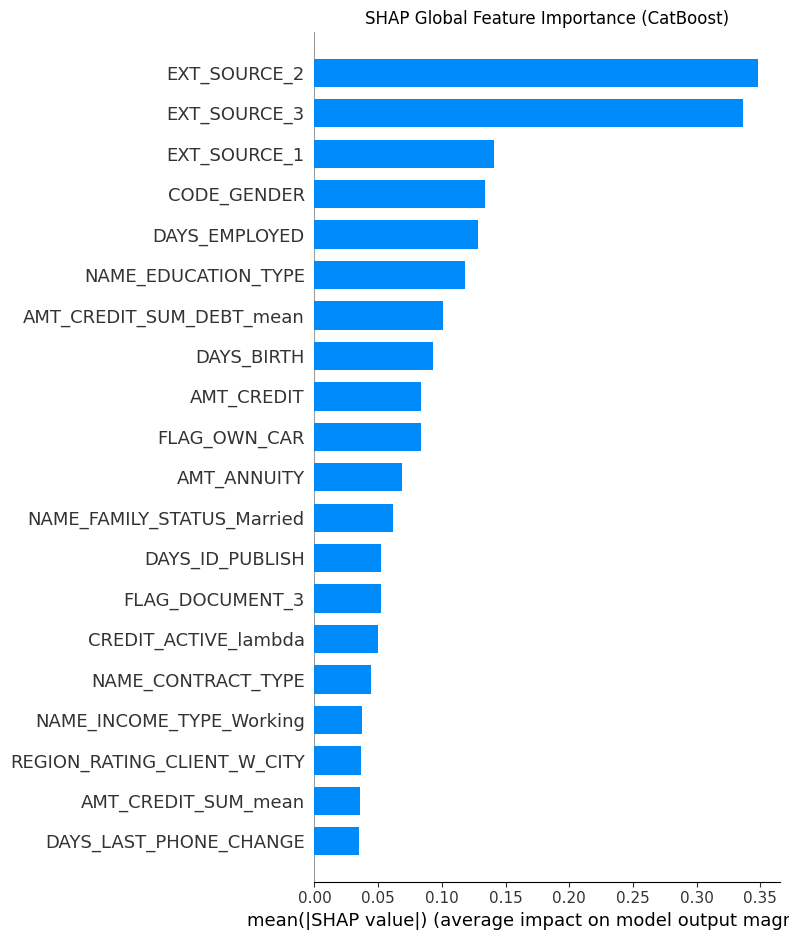


--- CatBoost Global Feature Impact & Distribution (Summary Plot - Beeswarm) ---


/tmp/ipykernel_1251/1785644735.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_cat, X_test, show=False)


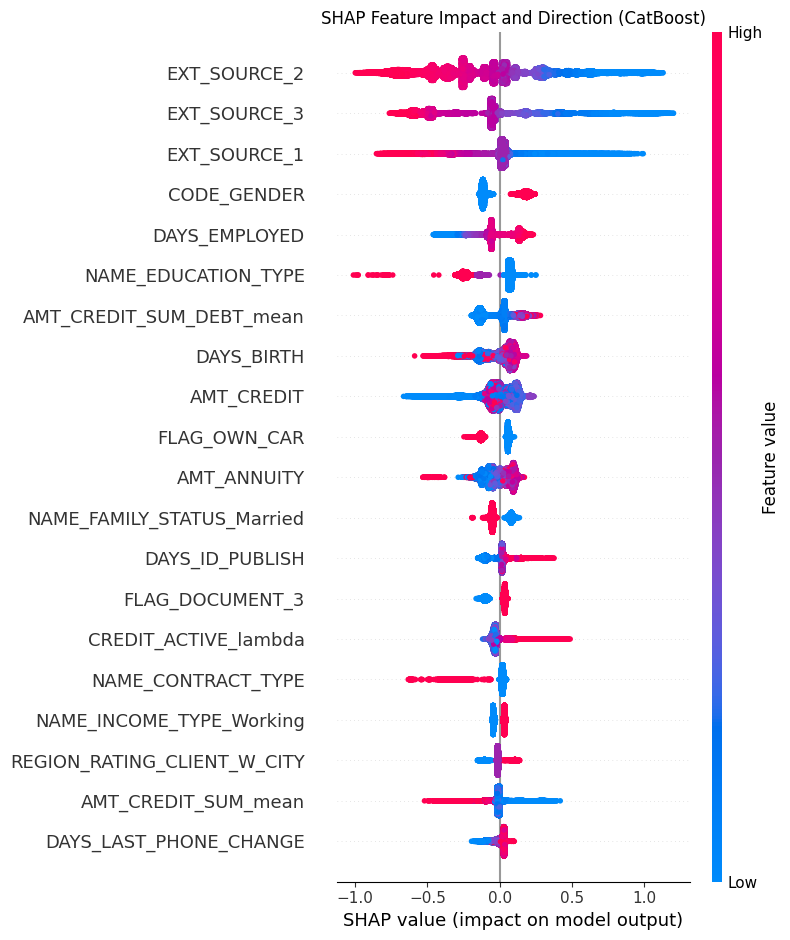


--- Local Explanation for CatBoost Applicant 0 (Force Plot) ---


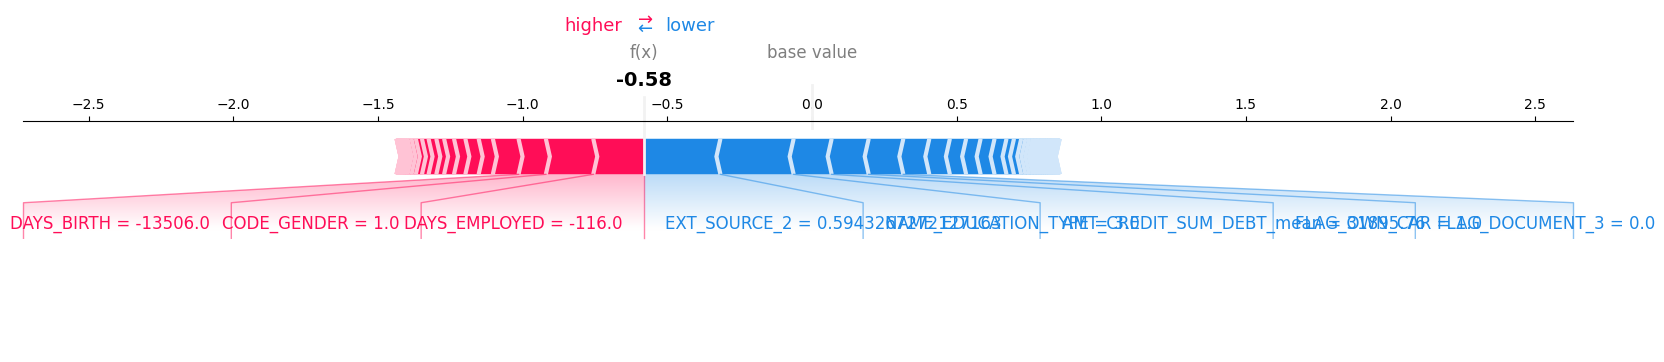


CatBoost Global baseline logit (average model output): 0.0011
CatBoost Global baseline probability (average model output): 0.5003

--- Top 10 CatBoost Features by Mean Absolute SHAP Value ---
EXT_SOURCE_2: 0.3480
EXT_SOURCE_3: 0.3362
EXT_SOURCE_1: 0.1410
CODE_GENDER: 0.1340
DAYS_EMPLOYED: 0.1280
NAME_EDUCATION_TYPE: 0.1183
AMT_CREDIT_SUM_DEBT_mean: 0.1008
DAYS_BIRTH: 0.0929
AMT_CREDIT: 0.0840
FLAG_OWN_CAR: 0.0835


In [175]:
# -----------------------------
# SHAP explainability: Global and Local for CatBoost
# -----------------------------
import shap
import matplotlib.pyplot as plt
import numpy as np

# Create TreeExplainer for the best CatBoost model
explainer_cat = shap.TreeExplainer(best_model_cat)

# Compute SHAP values for the test set
shap_values_cat = explainer_cat(X_test)

# --- Global feature importance (Bar Plot) ---
print("\n--- CatBoost Global Feature Importance (Summary Plot - Bar) ---")
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values_cat, X_test, plot_type="bar", show=False)
plt.title("SHAP Global Feature Importance (CatBoost)")
plt.tight_layout()
plt.show()

# --- Global distribution (Summary Plot - Beeswarm) ---
print("\n--- CatBoost Global Feature Impact & Distribution (Summary Plot - Beeswarm) ---")
plt.figure(figsize=(10,7))
shap.summary_plot(shap_values_cat, X_test, show=False)
plt.title("SHAP Feature Impact and Direction (CatBoost)")
plt.tight_layout()
plt.show()

# --- Local explanation for one applicant (Force Plot) ---
# Choose an index to inspect a specific applicant
applicant_idx = 0 # You can change this index to view other applicants

print(f"\n--- Local Explanation for CatBoost Applicant {applicant_idx} (Force Plot) ---")
# For force plot, we need the base_value and SHAP values for that specific instance
baseline_logit_cat = explainer_cat.expected_value

# If shap_values_cat is an Explanation object (preferred output from explainer(X)) or a list/array
if isinstance(shap_values_cat, shap.Explanation):
    local_shap_values_cat = shap_values_cat[applicant_idx]
else:
    # Fallback for older shap versions or if explainer.shap_values was used
    # For binary classification, often shap_values_cat[1] contains the positive class SHAP values
    local_shap_values_cat = shap_values_cat[1][applicant_idx] if isinstance(shap_values_cat, list) else shap_values_cat[applicant_idx]

shap.force_plot(
    base_value=baseline_logit_cat,        # Global baseline in log-odds
    shap_values=local_shap_values_cat.values, # SHAP contributions for this specific applicant
    features=X_test.iloc[applicant_idx],  # Actual feature values for this applicant
    matplotlib=True, # Use matplotlib for plotting in Colab
    show=True
)

# Also print global baseline probability for context
baseline_prob_cat = 1 / (1 + np.exp(-baseline_logit_cat))
print(f"\nCatBoost Global baseline logit (average model output): {baseline_logit_cat:.4f}")
print(f"CatBoost Global baseline probability (average model output): {baseline_prob_cat:.4f}")

# --- Ranking features by mean absolute SHAP value ---
shap_importance_cat_ranked = np.abs(shap_values_cat.values).mean(axis=0)
top_features_cat_ranked = sorted(
    zip(X_test.columns, shap_importance_cat_ranked),
    key=lambda x: -x[1]
)[:10]



print("\n--- Top 10 CatBoost Features by Mean Absolute SHAP Value ---")
for feature, importance in top_features_cat_ranked:
    print(f"{feature}: {importance:.4f}")

In [176]:
# -----------------------------
# SHAP breakdown for a single applicant (CatBoost)
# -----------------------------
import shap
import pandas as pd
import numpy as np

# Choose one applicant (row index from X_test)
applicant_index = 0 # change to whichever applicant you want

# Create TreeExplainer for your CatBoost model
explainer_cat_breakdown = shap.TreeExplainer(best_model_cat)

# Compute SHAP values
shap_values_cat_breakdown = explainer_cat_breakdown.shap_values(X_test)

# Global baseline (expected value of the model output, in log-odds)
baseline_logit_cat_breakdown = explainer_cat_breakdown.expected_value
baseline_prob_cat_breakdown = 1 / (1 + np.exp(-baseline_logit_cat_breakdown))

# Extract applicant's feature values
applicant_features_cat_breakdown = X_test.iloc[applicant_index]

# Extract applicant's SHAP values
# For binary classification, shap_values is a list of two arrays. We take the second for the positive class.
if isinstance(shap_values_cat_breakdown, list):
    applicant_shap_cat_breakdown = shap_values_cat_breakdown[1][applicant_index]
else:
    applicant_shap_cat_breakdown = shap_values_cat_breakdown[applicant_index]

# Put into a DataFrame for readability
applicant_df_cat_breakdown = pd.DataFrame({
    "Feature": X_test.columns,
    "Feature_Value": applicant_features_cat_breakdown.values,
    "SHAP_Value": applicant_shap_cat_breakdown
}).sort_values(by="SHAP_Value", key=np.abs, ascending=False)

# Calculate final logit = baseline + sum of SHAP values
final_logit_cat_breakdown = baseline_logit_cat_breakdown + applicant_shap_cat_breakdown.sum()

# Convert logit to probability (raw model probability)
pd_from_shap_cat_breakdown = 1 / (1 + np.exp(-final_logit_cat_breakdown))

# Raw model probability directly from booster
raw_pred_cat_breakdown = best_model_cat.predict_proba(X_test.iloc[applicant_index:applicant_index+1])[:, 1][0]

# Actual calibrated PD (from your pipeline)
actual_pd_cat_breakdown = y_proba_calibrated_cat[applicant_index]
predicted_class_cat_breakdown = best_model_cat.predict(X_test.iloc[applicant_index:applicant_index+1])[0]
actual_class_cat_breakdown = y_test.iloc[applicant_index]

print("Applicant index:", applicant_index)
print("Global baseline logit (same for all):", baseline_logit_cat_breakdown)
print("Global baseline probability:", baseline_prob_cat_breakdown)
print("Sum of SHAP values:", applicant_shap_cat_breakdown.sum())
print("Final logit (baseline + SHAP sum):", final_logit_cat_breakdown)
print("PD from SHAP decomposition (raw):", pd_from_shap_cat_breakdown)
print("Raw model PD (from booster):", raw_pred_cat_breakdown)
print("Predicted class:", predicted_class_cat_breakdown)
print("Actual class:", actual_class_cat_breakdown)
print("Calibrated PD (pipeline output):", actual_pd_cat_breakdown)
print("\nTop feature contributions:")
print(applicant_df_cat_breakdown.head(10))

Applicant index: 0
Global baseline logit (same for all): 0.0011473025290318101
Global baseline probability: 0.5002868256007955
Sum of SHAP values: -0.5817697472567448
Final logit (baseline + SHAP sum): -0.580622444727713
PD from SHAP decomposition (raw): 0.35878938172109565
Raw model PD (from booster): 0.35878938172109587
Predicted class: 0
Actual class: 0
Calibrated PD (pipeline output): 0.05406968628948694

Top feature contributions:
                      Feature  Feature_Value  SHAP_Value
31               EXT_SOURCE_2       0.594327   -0.264391
8         NAME_EDUCATION_TYPE       3.000000   -0.253075
11              DAYS_EMPLOYED    -116.000000    0.175138
1                 CODE_GENDER       1.000000    0.163847
65   AMT_CREDIT_SUM_DEBT_mean   31895.760000   -0.131411
2                FLAG_OWN_CAR       1.000000   -0.128025
38            FLAG_DOCUMENT_3       0.000000   -0.119693
10                 DAYS_BIRTH  -13506.000000    0.094409
61  AMT_REQ_CREDIT_BUREAU_QRT       1.000000   

In [177]:
#Proving social and legal trust
import pandas as pd
import numpy as np
import shap

# ┘ Feature name mapping
feature_names_map = {
    "EXT_SOURCE_3": "External credit score 3 ",
    "EXT_SOURCE_2": "External credit score 2",
    "EXT_SOURCE_1":"External credit score 1",
    "AMT_CREDIT_SUM_DEBT_mean": "Existing debt level",
    "DAYS_ID_PUBLISH": "Recent account activity",
    "DAYS_EMPLOYED": "Employment duration",
    "FLAG_OWN_CAR": "Car ownership status",
    "AMT_CREDIT": "Loan amount",
    "AMT_ANNUITY": "Loan installment amount",
    "NAME_EDUCATION_TYPE": "Education level",
    "CREDIT_ACTIVE_<lambda>": "Number of active loans",
    "AMT_REQ_CREDIT_BUREAU_QRT": "Credit inquiries in last quarter",
    "DAYS_CREDIT_mean": "Average age of credit accounts"
}

# ┘ Actionable recommendations (Social Trust )
action_map = {
    "External credit score 1": "Improve repayment history and avoid missed payments",
    "External credit score 3": "Improve repayment history and avoid missed payments",
    "External credit score 2": "Maintain consistent financial behavior across accounts",
    "Existing debt level": "Reduce outstanding debts before reapplying",
    "Recent account activity": "Ensure stable and consistent financial activity",
    "Employment duration": "Maintain stable employment for a longer period",
    "Car ownership status": "Ensure declared assets are accurate",
    "Loan amount": "Consider requesting a lower loan amount",
    "Loan installment amount": "Request a longer repayment period to reduce installments",
    "Education level": "Consider improving qualifications or demonstrating stable income",
    "Number of active loans": "Consider consolidating or closing inactive credit accounts",
    "Credit inquiries in last quarter": "Limit recent credit applications to avoid impacting score",
    "Average age of credit accounts": "Maintain existing credit accounts in good standing"
}

# ┘ Sensitive features to exclude
sensitive_features = ["CODE_GENDER"]

def adverse_action_notice_clean(prob, explanation):
    notice = f"""
Loan Application Decision: Rejected

Predicted Probability of Default: {prob:.2f}

Main Reasons:
"""
    for e in explanation:
        notice += f"\n- {e}"

    notice += """

Note: You may improve your application by addressing these factors.
"""
    return notice


# ---------------- MAIN LOGIC ---------------- #

y_pred_default_class = (y_proba_calibrated_cat >= best_threshold_cat).astype(int)
default_and_predicted_default_indices = y_test[(y_test == 1) & (y_pred_default_class == 1)].index

if not default_and_predicted_default_indices.empty:

    applicant_original_index = default_and_predicted_default_indices[0]
    applicant_positional_index = X_test.index.get_loc(applicant_original_index)

    explainer = shap.TreeExplainer(best_model_cat)
    shap_values = explainer.shap_values(X_test)

    if isinstance(shap_values, list):
        applicant_shap = shap_values[1][applicant_positional_index]
    else:
        applicant_shap = shap_values[applicant_positional_index]

    applicant_features = X_test.loc[applicant_original_index]

    # Create dataframe
    applicant_df = pd.DataFrame({
        "Feature": X_test.columns,
        "Value": applicant_features.values,
        "SHAP": applicant_shap
    })

    #  Remove sensitive features
    applicant_df = applicant_df[~applicant_df["Feature"].isin(sensitive_features)]

    # Sort by importance
    applicant_df["abs"] = np.abs(applicant_df["SHAP"])
    applicant_df = applicant_df.sort_values(by="abs", ascending=False)

    # Total contribution for percentage
    total_abs = applicant_df["abs"].sum()
    if total_abs == 0:
        total_abs = 1

    explanation_list = []

    print("\nTop clean explanations:")

    for _, row in applicant_df.head(10).iterrows():

        feature_raw = row["Feature"]
        shap_val = row["SHAP"]

        # Map to human-readable name
        feature_name = feature_names_map.get(feature_raw, feature_raw)

        direction = "increased" if shap_val > 0 else "decreased"
        percentage = (abs(shap_val) / total_abs) * 100

        #  Add actionable advice
        action = action_map.get(feature_name, "Review this factor")

        explanation = (
            f"{feature_name} {direction} the risk of default "
            f"({percentage:.1f}%). Suggested action: {action}"
        )

        explanation_list.append(explanation)
        print("- ", explanation)

    # Get correct probability
    prob = best_model_cat.predict_proba(X_test.loc[[applicant_original_index]])[:, 1][0]

    print("\n--- Adverse Action Notice ---")
    print(adverse_action_notice_clean(prob, explanation_list))

else:
    print("No suitable applicant found.")


Top clean explanations:
-  External credit score 2 increased the risk of default (32.0%). Suggested action: Maintain consistent financial behavior across accounts
-  External credit score 3  increased the risk of default (23.7%). Suggested action: Review this factor
-  Employment duration increased the risk of default (4.4%). Suggested action: Maintain stable employment for a longer period
-  Car ownership status decreased the risk of default (3.9%). Suggested action: Ensure declared assets are accurate
-  CREDIT_ACTIVE_lambda increased the risk of default (3.3%). Suggested action: Review this factor
-  DAYS_BIRTH increased the risk of default (3.0%). Suggested action: Review this factor
-  Loan amount increased the risk of default (2.6%). Suggested action: Consider requesting a lower loan amount
-  Education level increased the risk of default (2.2%). Suggested action: Consider improving qualifications or demonstrating stable income
-  Recent account activity decreased the risk of de

In [178]:
#Proving social and legal trust
import pandas as pd
import numpy as np
import shap

# ┘ Feature name mapping
feature_names_map = {
    "EXT_SOURCE_3": "External credit score 3 ",
    "EXT_SOURCE_2": "External credit score 2",
    "EXT_SOURCE_1":"External credit score 1",
    "AMT_CREDIT_SUM_DEBT_mean": "Existing debt level",
    "DAYS_ID_PUBLISH": "Recent account activity",
    "DAYS_EMPLOYED": "Employment duration",
    "FLAG_OWN_CAR": "Car ownership status",
    "AMT_CREDIT": "Loan amount",
    "AMT_ANNUITY": "Loan installment amount",
    "NAME_EDUCATION_TYPE": "Education level",
    "CREDIT_ACTIVE_<lambda>": "Number of active loans",
    "AMT_REQ_CREDIT_BUREAU_QRT": "Credit inquiries in last quarter",
    "DAYS_CREDIT_mean": "Average age of credit accounts"
}

# ┘ Actionable recommendations (Social Trust )
action_map = {
    "External credit score 1": "Improve repayment history and avoid missed payments",
    "External credit score 3": "Improve repayment history and avoid missed payments",
    "External credit score 2": "Maintain consistent financial behavior across accounts",
    "Existing debt level": "Reduce outstanding debts before reapplying",
    "Recent account activity": "Ensure stable and consistent financial activity",
    "Employment duration": "Maintain stable employment for a longer period",
    "Car ownership status": "Ensure declared assets are accurate",
    "Loan amount": "Consider requesting a lower loan amount",
    "Loan installment amount": "Request a longer repayment period to reduce installments",
    "Education level": "Consider improving qualifications or demonstrating stable income",
    "Number of active loans": "Consider consolidating or closing inactive credit accounts",
    "Credit inquiries in last quarter": "Limit recent credit applications to avoid impacting score",
    "Average age of credit accounts": "Maintain existing credit accounts in good standing"
}

# ┘ Sensitive features to exclude
sensitive_features = ["CODE_GENDER"]

def adverse_action_notice_clean(prob, explanation):
    notice = f"""
Loan Application Decision: Rejected

Predicted Probability of Default: {prob:.2f}

Main Reasons:
"""
    for e in explanation:
        notice += f"\n- {e}"

    notice += """

Note: You may improve your application by addressing these factors.
"""
    return notice


# ---------------- MAIN LOGIC ---------------- #

y_pred_default_class = (y_proba_calibrated_cat >= best_threshold_cat).astype(int)
default_and_predicted_default_indices = y_test[(y_test == 1) & (y_pred_default_class == 1)].index

if not default_and_predicted_default_indices.empty:

    applicant_original_index = default_and_predicted_default_indices[0]
    applicant_positional_index = X_test.index.get_loc(applicant_original_index)

    explainer = shap.TreeExplainer(best_model_cat)
    shap_values = explainer.shap_values(X_test)

    if isinstance(shap_values, list):
        applicant_shap = shap_values[1][applicant_positional_index]
    else:
        applicant_shap = shap_values[applicant_positional_index]

    applicant_features = X_test.loc[applicant_original_index]

    # Create dataframe
    applicant_df = pd.DataFrame({
        "Feature": X_test.columns,
        "Value": applicant_features.values,
        "SHAP": applicant_shap
    })

    #  Remove sensitive features
    applicant_df = applicant_df[~applicant_df["Feature"].isin(sensitive_features)]

    # Sort by importance
    applicant_df["abs"] = np.abs(applicant_df["SHAP"])
    applicant_df = applicant_df.sort_values(by="abs", ascending=False)

    # Total contribution for percentage
    total_abs = applicant_df["abs"].sum()
    if total_abs == 0:
        total_abs = 1

    explanation_list = []

    print("\nTop clean explanations:")

    for _, row in applicant_df.head(10).iterrows():

        feature_raw = row["Feature"]
        shap_val = row["SHAP"]

        # Map to human-readable name
        feature_name = feature_names_map.get(feature_raw, feature_raw)

        direction = "increased" if shap_val > 0 else "decreased"
        percentage = (abs(shap_val) / total_abs) * 100

        #  Add actionable advice
        action = action_map.get(feature_name, "Review this factor")

        explanation = (
            f"{feature_name} {direction} the risk of default "
            f"({percentage:.1f}%). Suggested action: {action}"
        )

        explanation_list.append(explanation)
        print("- ", explanation)

    # Get correct probability
    prob = best_model_cat.predict_proba(X_test.loc[[applicant_original_index]])[:, 1][0]

    print("\n---  Adverse Action Notice ---")
    print(adverse_action_notice_clean(prob, explanation_list))

else:
    print("No suitable applicant found.")


Top clean explanations:
-  External credit score 2 increased the risk of default (32.0%). Suggested action: Maintain consistent financial behavior across accounts
-  External credit score 3  increased the risk of default (23.7%). Suggested action: Review this factor
-  Employment duration increased the risk of default (4.4%). Suggested action: Maintain stable employment for a longer period
-  Car ownership status decreased the risk of default (3.9%). Suggested action: Ensure declared assets are accurate
-  CREDIT_ACTIVE_lambda increased the risk of default (3.3%). Suggested action: Review this factor
-  DAYS_BIRTH increased the risk of default (3.0%). Suggested action: Review this factor
-  Loan amount increased the risk of default (2.6%). Suggested action: Consider requesting a lower loan amount
-  Education level increased the risk of default (2.2%). Suggested action: Consider improving qualifications or demonstrating stable income
-  Recent account activity decreased the risk of de

In [179]:
import pandas as pd
import numpy as np
import shap

# ╙ Feature name mapping
feature_names_map = {
    "EXT_SOURCE_1": "Primary External Credit Score",
    "EXT_SOURCE_2": "External credit score 2",
    "EXT_SOURCE_3": "External credit score 3",
    "AMT_CREDIT_SUM_DEBT_mean": "Existing debt level",
    "DAYS_ID_PUBLISH": "Recent account activity",
    "DAYS_EMPLOYED": "Employment duration",
    "FLAG_OWN_CAR": "Car ownership status",
    "AMT_CREDIT": "Loan amount",
    "AMT_ANNUITY": "Loan installment amount",
    "NAME_EDUCATION_TYPE": "Education level",
    "CREDIT_ACTIVE_lambda": "Number of active loans",
    "AMT_REQ_CREDIT_BUREAU_QRT": "Credit inquiries in last quarter",
    "DAYS_CREDIT_mean": "Average age of credit accounts",
    "DAYS_REGISTRATION": "Registration date",
    "DAYS_LAST_PHONE_CHANGE": "Days since last phone change",
    "EXT_SOURCE_1_missing": "External Credit Score 1 Missing",
    "FLAG_DOCUMENT_3": "Document 3 Provided Status",
    "NAME_INCOME_TYPE_Working": "Income Type Working Status",
    "FLAG_PHONE": "Phone contact status",
    "AMT_CREDIT_SUM_mean": "Total credit amount",
    "OCCUPATION_TYPE": "Occupation Type"
}

# ╙ Actionable recommendations (Social Trust )
action_map = {
    "Primary External Credit Score": "Ensure timely payments, reduce outstanding balances, and avoid new credit inquiries.",
    "External credit score 2": "Maintain consistent repayment behavior across all accounts and avoid missed or late payments.",
    "External credit score 3": "Maintain on-time payments for at least 6 months and reduce credit utilization below 30%.",
    "Existing debt level": "Pay down high-interest loans first or consolidate debts to lower monthly obligations.",
    "Recent account activity": "Avoid frequent new credit applications and maintain consistent account balances.",
    "Employment duration": "Provide evidence of stable employment history or maintain continuous employment for a longer period.",
    "Car ownership status": "Ensure declared assets are accurate and properly documented.",
    "Loan amount": "Consider requesting a smaller loan amount or longer repayment term to reduce monthly obligations.",
    "Loan installment amount": "Request a longer repayment term or smaller loan amount to reduce monthly installments.",
    "Education level": "Provide documentation of stable income or professional certifications to strengthen repayment capacity.",
    "Number of active loans": "Limit the number of active credit accounts and close unused accounts to reduce risk.",
    "Credit inquiries in last quarter": "Limit recent credit applications to avoid impacting score",
    "Average age of credit accounts": "Maintain existing credit accounts in good standing",
    "Registration date": "Maintain longer account history with stable activity to demonstrate reliability.",
   "Days since last phone change": "Maintain stable contact information to demonstrate reliability.",
    "External Credit Score 1 Missing": "Ensure bureau data is complete and up-to-date to avoid missing records.",
    "Document 3 Provided Status": "Ensure required documentation is complete and accurate when applying.",
    "Income Type Working Status": "Provide proof of stable income (e.g., salary slips or bank statements) to strengthen application.",
    "Phone contact status": "Ensure your contact information is up-to-date and accessible.",
    "Total credit amount": "Consider consolidating or paying down existing credit to reduce overall debt.",
    "Occupation Type":"Submit proof of financial stability, such as steady income or collateral, to strengthen your application regardless of occupation."
}

# ╙ Sensitive features to exclude
sensitive_features = ["CODE_GENDER","DAYS_BIRTH","NAME_FAMILY_STATUS_Married"]

def adverse_action_notice_clean(prob, explanation):
    notice = f"""
Loan Application Decision: Rejected

Predicted Probability of Default: {prob:.2f}

Main Reasons:
"""
    for e in explanation:
        notice += f"\n\n- {e}"

    notice += """

Note: You may improve your application by addressing these factors.
"""
    return notice


# ---------------- MAIN LOGIC ---------------- #

y_pred_default_class = (y_proba_calibrated_cat >= best_threshold_cat).astype(int)
default_and_predicted_default_indices = y_test[(y_test == 1) & (y_pred_default_class == 1)].index

if not default_and_predicted_default_indices.empty:

    applicant_original_index = default_and_predicted_default_indices[0]
    applicant_positional_index = X_test.index.get_loc(applicant_original_index)

    explainer = shap.TreeExplainer(best_model_cat)
    shap_values = explainer.shap_values(X_test)

    if isinstance(shap_values, list):
        applicant_shap = shap_values[1][applicant_positional_index]
    else:
        applicant_shap = shap_values[applicant_positional_index]

    applicant_features = X_test.loc[applicant_original_index]

    # Create dataframe
    applicant_df = pd.DataFrame({
        "Feature": X_test.columns,
        "Value": applicant_features.values,
        "SHAP": applicant_shap
    })

    #  Remove sensitive features
    applicant_df = applicant_df[~applicant_df["Feature"].isin(sensitive_features)]

    # Sort by importance
    applicant_df["abs"] = np.abs(applicant_df["SHAP"])
    applicant_df = applicant_df.sort_values(by="abs", ascending=False)

    # Total contribution for percentage
    total_abs = applicant_df["abs"].sum()
    if total_abs == 0:
        total_abs = 1

    explanation_list = []

    for _, row in applicant_df.head(20).iterrows():

        feature_raw = row["Feature"]
        shap_val = row["SHAP"]

        # Map to human-readable name
        feature_name = feature_names_map.get(feature_raw, feature_raw)

        # Only provide actionable advice if the SHAP value increases the risk
        if shap_val > 0:
            direction = "increased"
            percentage = (abs(shap_val) / total_abs) * 100
            action = action_map.get(feature_name, "No specific action defined, but this factor increased risk.")
            explanation = (
                f"{feature_name} {direction} the risk of default "
                f"({percentage:.1f}%). Suggested action: {action}"
            )
        else:
            # For features that decrease risk, always state 'no more improvement needed'
            direction = "decreased"
            percentage = (abs(shap_val) / total_abs) * 100
            explanation = (
                f"{feature_name} {direction} the risk of default "
                f"({percentage:.1f}%). This factor needs no more improvement."
            )

        explanation_list.append(explanation)

    # Get correct probability
    prob = best_model_cat.predict_proba(X_test.loc[[applicant_original_index]])[:, 1][0]

    print("\n--- Adverse Action Notice ---")
    print(adverse_action_notice_clean(prob, explanation_list))

else:
    print("No suitable applicant found.")


--- Adverse Action Notice ---

Loan Application Decision: Rejected

Predicted Probability of Default: 0.90

Main Reasons:


- External credit score 2 increased the risk of default (33.5%). Suggested action: Maintain consistent repayment behavior across all accounts and avoid missed or late payments.

- External credit score 3 increased the risk of default (24.8%). Suggested action: Maintain on-time payments for at least 6 months and reduce credit utilization below 30%.

- Employment duration increased the risk of default (4.6%). Suggested action: Provide evidence of stable employment history or maintain continuous employment for a longer period.

- Car ownership status decreased the risk of default (4.0%). This factor needs no more improvement.

- Number of active loans increased the risk of default (3.5%). Suggested action: Limit the number of active credit accounts and close unused accounts to reduce risk.

- Loan amount increased the risk of default (2.7%). Suggested action: Consid

In [180]:
# # -----------------------------
# # ETHICAL TRUST: Proxy variable check
import pandas as pd
import numpy as np
import shap

# Compute correlation between sensitive attributes and other features
sensitive_features = ['CODE_GENDER', 'DAYS_BIRTH',]  # you can add 'REGION', 'EDUCATION', etc. if available
proxy_report = {}

for sens in sensitive_features:
    if sens in X_train.columns:
        correlations = X_train.corr()[sens].sort_values(key=lambda x: abs(x), ascending=False)
        proxy_report[sens] = correlations[1:6]  # top 5 correlated non-sensitive features

print("Proxy variable correlations:")
for sens, corr in proxy_report.items():
    print(f"\nSensitive attribute: {sens}")
    print(corr)

# Check SHAP importance of sensitive attributes
explainer = shap.TreeExplainer(best_model_cat)
shap_values = explainer.shap_values(X_test)
global_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=X_test.columns).sort_values(ascending=False)

print("\nTop SHAP features (with sensitive attributes flagged):")
for feat, val in global_importance.head(15).items():
    flag = " <-- sensitive/proxy" if feat in sensitive_features else ""
    print(f"{feat}: {val:.4f}{flag}")

Proxy variable correlations:

Sensitive attribute: CODE_GENDER
FLAG_OWN_CAR        0.346157
FLAG_DOCUMENT_8     0.249787
AMT_INCOME_TOTAL    0.200715
EXT_SOURCE_1       -0.199043
DAYS_BIRTH          0.148148
Name: CODE_GENDER, dtype: float64

Sensitive attribute: DAYS_BIRTH
FLAG_DOCUMENT_6     -0.405811
EXT_SOURCE_1        -0.359522
CNT_CHILDREN         0.336561
DAYS_REGISTRATION    0.331815
OCCUPATION_TYPE     -0.317702
Name: DAYS_BIRTH, dtype: float64

Top SHAP features (with sensitive attributes flagged):
EXT_SOURCE_2: 0.3480
EXT_SOURCE_3: 0.3362
EXT_SOURCE_1: 0.1410
CODE_GENDER: 0.1340 <-- sensitive/proxy
DAYS_EMPLOYED: 0.1280
NAME_EDUCATION_TYPE: 0.1183
AMT_CREDIT_SUM_DEBT_mean: 0.1008
DAYS_BIRTH: 0.0929 <-- sensitive/proxy
AMT_CREDIT: 0.0840
FLAG_OWN_CAR: 0.0835
AMT_ANNUITY: 0.0689
NAME_FAMILY_STATUS_Married: 0.0616
DAYS_ID_PUBLISH: 0.0526
FLAG_DOCUMENT_3: 0.0523
CREDIT_ACTIVE_lambda: 0.0499


In [181]:
from fairlearn.metrics import MetricFrame, selection_rate

mf = MetricFrame(
    metrics=selection_rate,
    y_true=y_test,
    y_pred=y_pred_default_class, # This variable is already using y_proba_calibrated_cat and best_threshold_cat from a previous cell
    sensitive_features=X_test["CODE_GENDER"]
)

print(mf.by_group)

CODE_GENDER
0    0.002539
1    0.005062
Name: selection_rate, dtype: float64


In [182]:
mf.difference()

np.float64(0.0025228222227732062)

## Model Comparison and Recommendation for Credit Scoring

We have evaluated three gradient boosting models: XGBoost, LightGBM, and CatBoost, across several critical metrics for credit scoring applications: discrimination (ROC-AUC), probability accuracy (Brier Score), calibration reliability (Expected Calibration Error - ECE), and SHAP explanation stability (Kendall Tau correlation).

Here's a summary of their performance after tuning and calibration:

| Metric                         | XGBoost | LightGBM | CatBoost |
|:-------------------------------|:--------|:---------|:---------|
| ROC-AUC                        | 0.757   | 0.757   | **0.7603** |
| Brier Score                    | **0.0679**| **0.0679**   | 0.0682   |
| ECE                            | **0.0042**  | 0.0044   | 0.0103   |
| SHAP Stability (Kendall Tau)   | 0.8034   | 0.8528   | **0.8783** |

### Analysis and Recommendation:

1.  **Discrimination (ROC-AUC)**: CatBoost shows a slight edge in ROC-AUC , indicating a marginally better ability to distinguish between defaulting and non-defaulting applicants.
2.  **Probability Accuracy (Brier Score) & Calibration (ECE)**: LightGBM and XGBoost demonstrate slightly superior performance in terms of Brier Score and ECE.
3.  **Explainability (SHAP Stability)**: CatBoost stands out significantly with the highest SHAP stability score. This is a crucial factor in credit scoring, as it implies that the model's feature importance rankings are highly consistent and trustworthy. This directly enhances the interpretability and reliability of adverse action notices and fairness evaluations.

### Conclusion:

While all three models perform well, especially after calibration, the choice depends on the specific priorities. For a credit scoring application, not only prediction accuracy but also the reliability of probability estimates and, crucially, **model explainability and trust** are paramount.

Given CatBoost's slightly better discriminative power and its notably higher SHAP explanation stability, it emerges as a strong candidate. The consistency in feature importance rankings provided by CatBoost would be invaluable for generating transparent and defensible explanations for loan decisions, which is a key requirement for ethical and regulatory compliance in credit scoring.

Therefore, **CatBoost** is recommended as the better model for this credit scoring task due to its balance of good predictive performance, decent calibration, and superior explainability.

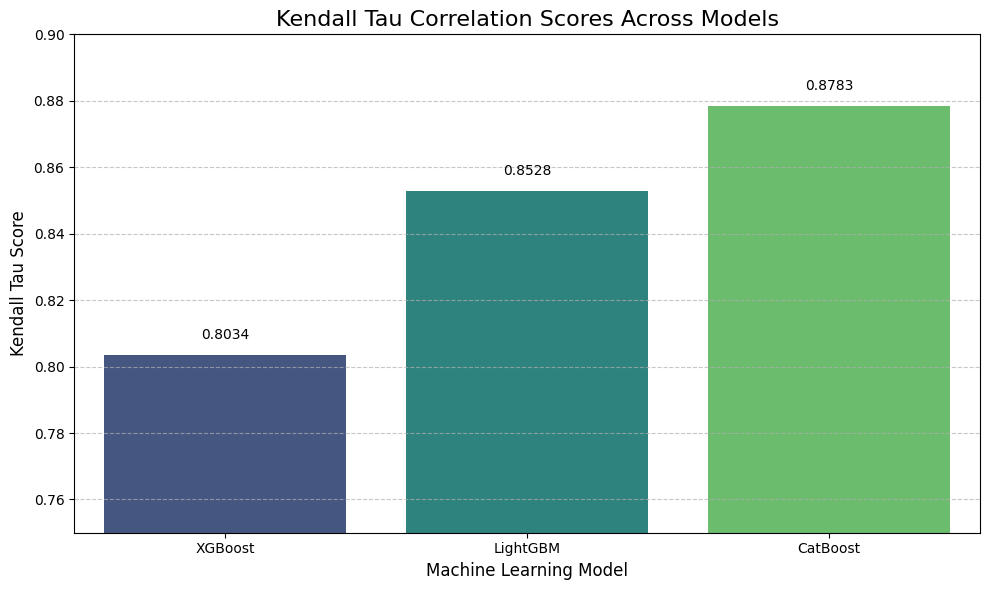

In [183]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data for Kendall Tau scores
model_names = ['XGBoost', 'LightGBM', 'CatBoost']
kendall_tau_scores = [tau, tau_lgbm, tau_cat] # Using the calculated tau values

# Create a DataFrame
kendall_tau_df = pd.DataFrame({
    'Model': model_names,
    'Kendall_Tau_Score': kendall_tau_scores
})

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Kendall_Tau_Score', hue='Model', data=kendall_tau_df, palette='viridis', legend=False)

# Add title and labels
plt.title('Kendall Tau Correlation Scores Across Models', fontsize=16)
plt.xlabel('Machine Learning Model', fontsize=12)
plt.ylabel('Kendall Tau Score', fontsize=12)
plt.ylim(0.75, 0.90) # Adjust y-axis limits for better visualization of differences
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add score values on top of bars
for index, row in kendall_tau_df.iterrows():
    plt.text(index, row.Kendall_Tau_Score + 0.005, round(row.Kendall_Tau_Score, 4), color='black', ha="center")

plt.tight_layout()
plt.show()

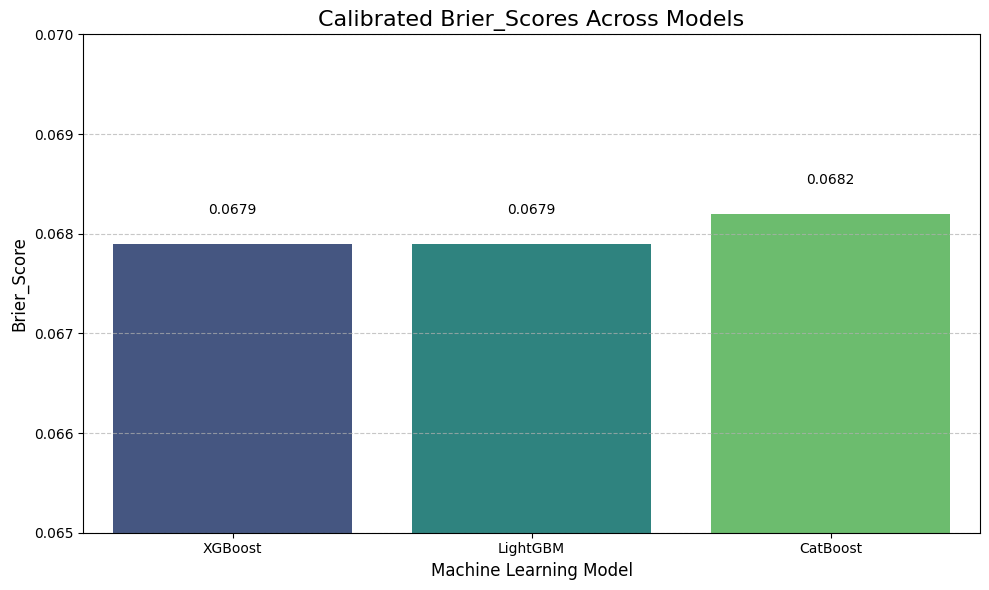

In [184]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data for calibrated ROC-AUC scores
model_names = ['XGBoost', 'LightGBM', 'CatBoost']
Brier_scores = [0.0679, 0.0679, 0.0682]

# Create a DataFrame
roc_auc_df = pd.DataFrame({
    'Model': model_names,
    'Brier_Score':Brier_scores
})

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Brier_Score', hue='Model', data=roc_auc_df, palette='viridis', legend=False)

# Add title and labels
plt.title('Calibrated Brier_Scores Across Models', fontsize=16)
plt.xlabel('Machine Learning Model', fontsize=12)
plt.ylabel('Brier_Score', fontsize=12)
plt.ylim(0.065, 0.070) # Set y-axis limits for better visualization of differences
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add score values on top of bars
for index, row in roc_auc_df.iterrows():
    plt.text(index, row.Brier_Score + 0.0003, round(row.Brier_Score, 4), color='black', ha="center")

plt.tight_layout()
plt.show()

/tmp/ipykernel_1251/132525860.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='ROC_AUC_Score', data=roc_auc_df, palette='viridis')


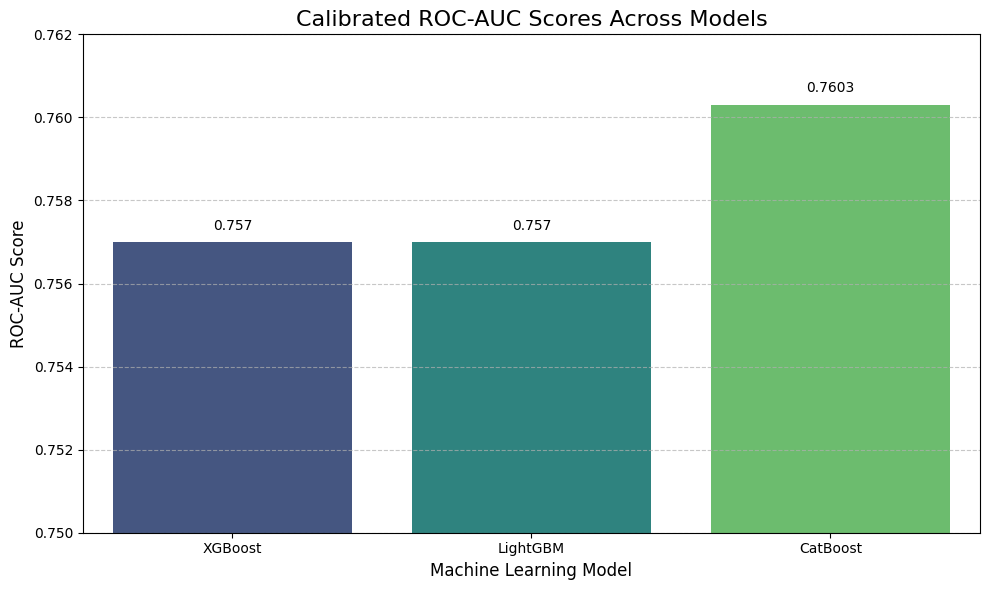

In [188]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data for calibrated ROC-AUC scores
model_names = ['XGBoost', 'LightGBM', 'CatBoost']
roc_auc_scores = [0.757, 0.757, 0.7603]

# Create a DataFrame
roc_auc_df = pd.DataFrame({
    'Model': model_names,
    'ROC_AUC_Score': roc_auc_scores
})

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='ROC_AUC_Score', data=roc_auc_df, palette='viridis')

# Add title and labels
plt.title('Calibrated ROC-AUC Scores Across Models', fontsize=16)
plt.xlabel('Machine Learning Model', fontsize=12)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.ylim(0.75, 0.762) # Set y-axis limits for better visualization of differences
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add score values on top of bars
for index, row in roc_auc_df.iterrows():
    plt.text(index, row.ROC_AUC_Score + 0.0003, round(row.ROC_AUC_Score, 4), color='black', ha="center")

plt.tight_layout()
plt.show()

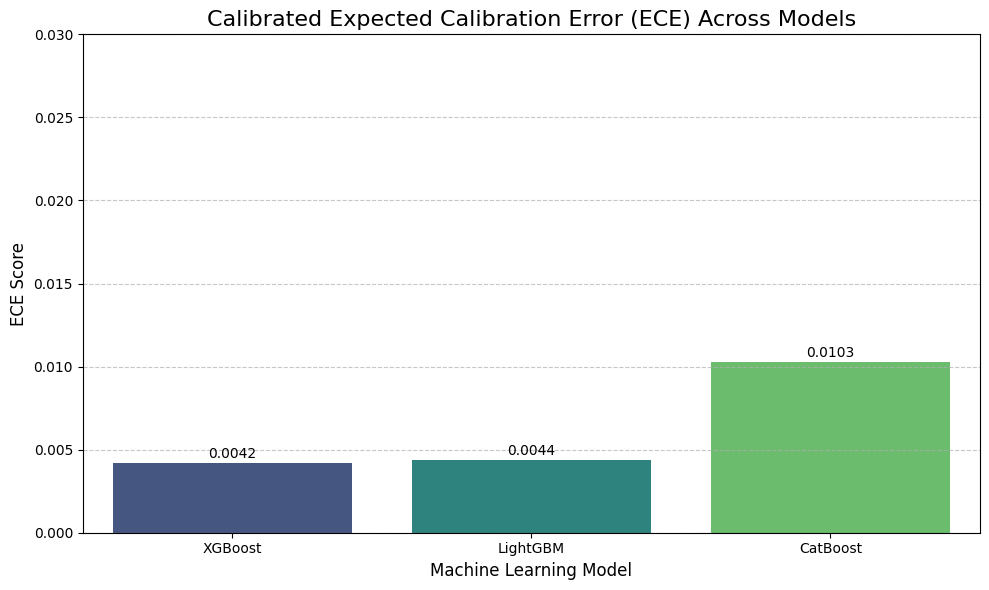

In [186]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data for calibrated ECE scores
model_names = ['XGBoost', 'LightGBM', 'CatBoost']
ece_scores = [0.0042, 0.0044, 0.0103]

# Create a DataFrame
ece_df = pd.DataFrame({
    'Model': model_names,
    'ECE_Score': ece_scores
})

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='ECE_Score', hue='Model', data=ece_df, palette='viridis', legend=False)

# Add title and labels
plt.title('Calibrated Expected Calibration Error (ECE) Across Models', fontsize=16)
plt.xlabel('Machine Learning Model', fontsize=12)
plt.ylabel('ECE Score', fontsize=12)
plt.ylim(0.00, 0.03) # Set y-axis limits for better visualization of differences
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add score values on top of bars
for index, row in ece_df.iterrows():
    plt.text(index, row.ECE_Score + 0.0003, round(row.ECE_Score, 4), color='black', ha="center")

plt.tight_layout()
plt.show()

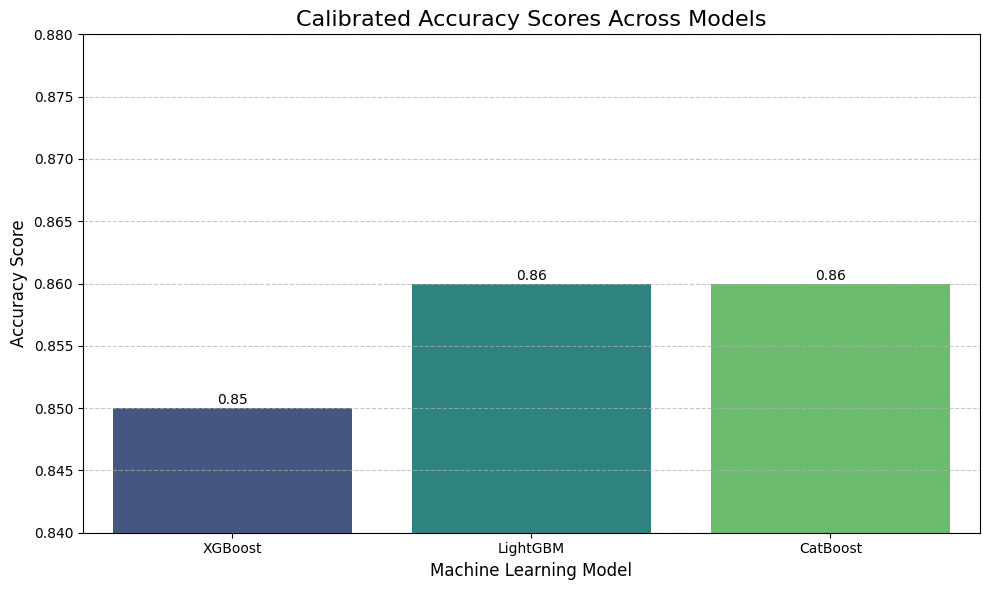

In [187]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data for calibrated accuracy scores
model_names = ['XGBoost', 'LightGBM', 'CatBoost']
accuracy_scores = [0.85, 0.86, 0.86]

# Create a DataFrame
accuracy_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy_Score': accuracy_scores
})

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy_Score', hue='Model', data=accuracy_df, palette='viridis', legend=False)

# Add title and labels
plt.title('Calibrated Accuracy Scores Across Models', fontsize=16)
plt.xlabel('Machine Learning Model', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0.84, 0.88) # Set y-axis limits for better visualization of differences
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add score values on top of bars
for index, row in accuracy_df.iterrows():
    plt.text(index, row.Accuracy_Score + 0.0003, round(row.Accuracy_Score, 3), color='black', ha="center")

plt.tight_layout()
plt.show()